Både træning og testdata er blevet gennemtjekket manuelt, for at se om splciingprogrammet noglegange kommer til at ramme ved siden af. Men i tidernes morgen blev unknown splicing til træningssættet implementeret ved at man randomly tog nogle tilfældige ord og stilhedsstøj, hvortil at hvis man prøver at kører unknown splicing, så vil det ikke virke. Vi bruger dermed vores unknown splicing, som brugt til det endelige arbejde. Altså vores unknown data er stort set det samme, men "unknown_balanced" bliver ændret fra gang til gang, fordi vi ikke har seed(42) eller lign. --> VI BRUGER UNKNOWN BALANCED FRA DET ENDELIGE ARBEJDE.

In [15]:
#!/usr/bin/env python3

from pathlib import Path
import re
import random
import shutil
import numpy as np
import soundfile as sf
from scipy.io import wavfile
import os
import stat
import time

# =========================================================
# SETTINGS
# =========================================================
ROOT = Path(".").resolve()

KEYWORDS_DIR = ROOT / "keywords"
UNKNOWN_DIR = ROOT / "unknown"

KEYWORDS_SPLICED_DIR = KEYWORDS_DIR / "spliced"
RANDOM_DIR = UNKNOWN_DIR / "random_bachelorLokale"
RANDOM_SPLICED_DIR = RANDOM_DIR / "spliced"
PREPARED_WORDS_DIR = ROOT / "prepared_words"

TARGET_LABELS = ["får", "ged", "hest", "laks", "ulv"]
UNKNOWN_LABELS = ["random", "stilhed"]

SAMPLE_RATE = 16000
SAMPLE_TIME = 1.0
BIT_DEPTH = "PCM_16"

# ---------- splicing params for keywords ----------
WINDOW_S = 1.00
PRE_S = 0.20
MIN_GAP_S = 0.45
FRAME_MS = 20
HOP_MS = 10
THRESH_MULT = 6.0
MAX_SLICES_PER_FILE = 10

# Special tuning for difficult files
SPECIAL_FILE_PARAMS = {
    "laks_C_0.75m_stille.001.wav": {
        "window_s": 1.0,
        "pre_s": 0.22,
        "min_gap_s": 0.55,
        "frame_ms": 20,
        "hop_ms": 10,
        "thresh_mult": 4.5,
        "max_slices": 10,
    },
    "laks_C_1.5m_stille.001.wav": {
        "window_s": 1.0,
        "pre_s": 0.25,
        "min_gap_s": 0.60,
        "frame_ms": 20,
        "hop_ms": 10,
        "thresh_mult": 4.0,
        "max_slices": 10,
    },
}

FNAME_RE = re.compile(
    r"^(?P<label>[^_]+)_(?P<speaker>[A-Za-z])_(?P<dist>[0-9.]+m)_(?P<env>[^.]+)\.(?P<take>\d+)\.wav$",
    re.IGNORECASE
)

SPLICED_FNAME_RE = re.compile(
    r"^(?P<label>.+?)_(?P<speaker>[A-Za-z])_(?P<dist>[0-9.]+m)_(?P<env>[^_]+)_(?P<take>\d+)_s(?P<slice>\d+)\.wav$",
    re.IGNORECASE
)



# =========================================================
# HELPERS
# =========================================================

def _handle_remove_readonly(func, path, exc):
    """
    Bruges af shutil.rmtree hvis Windows nægter adgang pga. read-only/lås.
    """
    try:
        os.chmod(path, stat.S_IWRITE)
        func(path)
    except Exception as e:
        print(f"[reset] Could not delete {path}: {e}")

def safe_rmtree(path: Path, retries: int = 5, delay: float = 0.5):
    """
    Forsøger at slette en mappe flere gange. Hjælper mod midlertidige fil-låse.
    """
    if not path.exists():
        return

    for attempt in range(1, retries + 1):
        try:
            shutil.rmtree(path, onerror=_handle_remove_readonly)
            return
        except PermissionError as e:
            print(f"[reset] PermissionError deleting {path} (attempt {attempt}/{retries}): {e}")
            time.sleep(delay)

    raise PermissionError(f"Could not delete folder after {retries} attempts: {path}")

def reset_output_dirs():
    paths_to_reset = [
        KEYWORDS_SPLICED_DIR,
        RANDOM_SPLICED_DIR,
        PREPARED_WORDS_DIR,
    ]

    for unknown_label in UNKNOWN_LABELS:
        if unknown_label != "random":
            paths_to_reset.append(UNKNOWN_DIR / unknown_label / "spliced")

    for path in paths_to_reset:
        if path.exists():
            print(f"[reset] Deleting: {path}")
            safe_rmtree(path)

def sanitize(s: str) -> str:
    s = s.strip()
    return re.sub(r'[\\/:*?"<>|]+', "_", s)

def to_mono(x: np.ndarray) -> np.ndarray:
    if x.ndim == 1:
        return x
    return x.mean(axis=1)

def moving_rms(x: np.ndarray, frame: int, hop: int) -> np.ndarray:
    if len(x) < frame:
        return np.array([], dtype=np.float32)
    n = 1 + (len(x) - frame) // hop
    rms = np.empty(n, dtype=np.float32)
    for i in range(n):
        seg = x[i * hop : i * hop + frame]
        rms[i] = np.sqrt(np.mean(seg * seg) + 1e-12)
    return rms

def detect_event_starts(rms: np.ndarray, thr: float, hop: int) -> np.ndarray:
    if rms.size == 0:
        return np.array([], dtype=np.int64)
    above = rms > thr
    starts = np.where(np.logical_and(above, np.concatenate([[False], ~above[:-1]])))[0]
    return (starts * hop).astype(np.int64)

def parse_base_name(wav_path: Path) -> str:
    m = FNAME_RE.match(wav_path.name)
    if m:
        label = sanitize(m.group("label"))
        speaker = sanitize(m.group("speaker"))
        dist = sanitize(m.group("dist"))
        env = sanitize(m.group("env"))
        take = int(m.group("take"))
        return f"{label}_{speaker}_{dist}_{env}_{take:03d}"
    return sanitize(wav_path.stem)

def ensure_clean_dir(path: Path):
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

def load_audio_fixed(path: Path, sample_rate: int, sample_time: float):
    x, fs = sf.read(str(path), always_2d=False)
    x = np.asarray(x, dtype=np.float32)
    x = to_mono(x)

    if fs != sample_rate:
        old_idx = np.linspace(0, len(x) - 1, num=len(x), dtype=np.float32)
        new_len = int(round(len(x) * sample_rate / fs))
        new_idx = np.linspace(0, len(x) - 1, num=new_len, dtype=np.float32)
        x = np.interp(new_idx, old_idx, x).astype(np.float32)

    target_len = int(sample_rate * sample_time)
    if len(x) < target_len:
        x = np.pad(x, (0, target_len - len(x)))
    else:
        x = x[:target_len]

    return x

def get_random_bg_snippet(bg_path: Path, sample_rate: int, sample_time: float):
    bg, fs = sf.read(str(bg_path), always_2d=False)
    bg = np.asarray(bg, dtype=np.float32)
    bg = to_mono(bg)

    if fs != sample_rate:
        old_idx = np.linspace(0, len(bg) - 1, num=len(bg), dtype=np.float32)
        new_len = int(round(len(bg) * sample_rate / fs))
        new_idx = np.linspace(0, len(bg) - 1, num=new_len, dtype=np.float32)
        bg = np.interp(new_idx, old_idx, bg).astype(np.float32)

    target_len = int(sample_rate * sample_time)
    if len(bg) < target_len:
        raise ValueError(f"Background file too short: {bg_path}")

    max_start = len(bg) - target_len
    start = random.randint(0, max_start)
    return bg[start:start + target_len]

def normalize_peak(x: np.ndarray, eps: float = 1e-9):
    peak = np.max(np.abs(x))
    if peak < eps:
        return x
    return x / peak

#def mix_audio(word_waveform, bg_waveform, word_vol=1.0, bg_vol=0.35):
#    word_waveform = normalize_peak(word_waveform)
#    bg_waveform = normalize_peak(bg_waveform)
#    mixed = word_vol * word_waveform + bg_vol * bg_waveform
#    mixed = np.clip(mixed, -1.0, 1.0)
#    return mixed.astype(np.float32)

def mix_audio(word_waveform, bg_waveform, word_vol=1.0, bg_vol=0.35):
    mixed = word_vol * word_waveform + bg_vol * bg_waveform

    peak = np.max(np.abs(mixed))
    if peak > 1.0:
        mixed = mixed / peak

    return mixed.astype(np.float32)

def replace_noise_label(filename: str, new_noise_label: str):
    if "_stille_" in filename:
        return filename.replace("_stille_", f"_{new_noise_label}_", 1)
    stem = Path(filename).stem
    suffix = Path(filename).suffix
    return f"{stem}_{new_noise_label}{suffix}"

# =========================================================
# STEP 1: SPLICE KEYWORDS
# =========================================================
def slice_keyword_file(wav_path: Path, out_dir: Path, cfg: dict) -> int:
    fs, data = wavfile.read(wav_path)
    x = to_mono(data).astype(np.float32)

    frame = int(fs * (cfg["frame_ms"] / 1000.0))
    hop = int(fs * (cfg["hop_ms"] / 1000.0))

    rms = moving_rms(x, frame, hop)
    if rms.size == 0:
        return 0

    med = float(np.median(rms))
    thr = max(med * cfg["thresh_mult"], 1e-6)

    starts = detect_event_starts(rms, thr, hop)

    min_gap = int(fs * cfg["min_gap_s"])
    filtered = []
    last = -10**18
    for s in starts:
        if s - last >= min_gap:
            filtered.append(s)
            last = s
        if len(filtered) >= cfg["max_slices"]:
            break

    if not filtered:
        return 0

    base = parse_base_name(wav_path)
    out_dir.mkdir(parents=True, exist_ok=True)

    win = int(fs * cfg["window_s"])
    pre = int(fs * cfg["pre_s"])

    written = 0
    for i, s in enumerate(filtered, start=1):
        start = max(int(s - pre), 0)
        end = start + win
        if end > len(x):
            continue

        clip = x[start:end]
        clip = np.clip(clip, -32768, 32767).astype(np.int16)
        out_path = out_dir / f"{base}_s{i:02d}.wav"
        wavfile.write(out_path, fs, clip)
        written += 1

    return written

def splice_keywords():
    ensure_clean_dir(KEYWORDS_SPLICED_DIR)

    wavs = sorted([p for p in KEYWORDS_DIR.glob("*.wav") if p.is_file()])
    print(f"[keywords] Found {len(wavs)} raw files")

    total = 0
    default_cfg = {
        "window_s": WINDOW_S,
        "pre_s": PRE_S,
        "min_gap_s": MIN_GAP_S,
        "frame_ms": FRAME_MS,
        "hop_ms": HOP_MS,
        "thresh_mult": THRESH_MULT,
        "max_slices": MAX_SLICES_PER_FILE,
    }

    for wav in wavs:
        cfg = SPECIAL_FILE_PARAMS.get(wav.name, default_cfg)
        n = slice_keyword_file(wav, KEYWORDS_SPLICED_DIR, cfg)
        print(f"[keywords] {wav.name}: {n} slices")
        total += n

    print(f"[keywords] Total slices: {total}")

# =========================================================
# STEP 2: SPLICE RANDOM WORDS
# =========================================================
def splice_random_words():
    ensure_clean_dir(RANDOM_SPLICED_DIR)

    wavs = sorted([p for p in RANDOM_DIR.glob("*.wav") if p.is_file()])
    print(f"[random] Found {len(wavs)} raw files")

    total = 0
    cfg = {
        "window_s": WINDOW_S,
        "pre_s": PRE_S,
        "min_gap_s": MIN_GAP_S,
        "frame_ms": FRAME_MS,
        "hop_ms": HOP_MS,
        "thresh_mult": THRESH_MULT,
        "max_slices": MAX_SLICES_PER_FILE,
    }

    for wav in wavs:
        n = slice_keyword_file(wav, RANDOM_SPLICED_DIR, cfg)
        print(f"[random] {wav.name}: {n} slices")
        total += n

    print(f"[random] Total slices: {total}")

# =========================================================
# STEP 3: SPLIT BACKGROUND NOISE TO 1-SECOND FILES
# =========================================================
def split_noise_folder(noise_label: str):
    src_dir = UNKNOWN_DIR / noise_label
    out_dir = src_dir / "spliced"
    ensure_clean_dir(out_dir)

    wavs = sorted([p for p in src_dir.glob("*.wav") if p.is_file()])
    print(f"[{noise_label}] Found {len(wavs)} raw noise files")

    total = 0
    for wav_path in wavs:
        fs, data = wavfile.read(wav_path)
        data = to_mono(data).astype(np.int16)

        samples_per_chunk = int(fs * SAMPLE_TIME)
        n_chunks = len(data) // samples_per_chunk

        for i in range(n_chunks):
            start = i * samples_per_chunk
            end = start + samples_per_chunk
            chunk = data[start:end]

            out_name = f"{wav_path.stem}_u{i+1:02d}.wav"
            wavfile.write(out_dir / out_name, fs, chunk)
            total += 1

        print(f"[{noise_label}] {wav_path.name}: {n_chunks} chunks")

    print(f"[{noise_label}] Total chunks: {total}")

# =========================================================
# STEP 4: BUILD prepared_words
# =========================================================
def build_prepared_words():
    ensure_clean_dir(PREPARED_WORDS_DIR)

    for label in TARGET_LABELS:
        (PREPARED_WORDS_DIR / label).mkdir(parents=True, exist_ok=True)

    wavs = sorted([p for p in KEYWORDS_SPLICED_DIR.glob("*.wav") if p.is_file()])
    moved = 0

    for wav in wavs:
        m = SPLICED_FNAME_RE.match(wav.name)
        if not m:
            print(f"[prepared_words] Could not parse filename: {wav.name}")
            continue

        label = m.group("label")
        if label in TARGET_LABELS:
            shutil.copy2(wav, PREPARED_WORDS_DIR / label / wav.name)
            moved += 1
        else:
            print(f"[prepared_words] Ignored non-target label: {wav.name}")

    print(f"[prepared_words] Copied {moved} files")

    for label in TARGET_LABELS:
        count = len(list((PREPARED_WORDS_DIR / label).glob("*.wav")))
        print(f"[prepared_words] {label}: {count} files")

UNKNOWN_BALANCED_DIR = ROOT / "unknown_balanced_randomly"

def build_unknown_balanced(total_unknown_samples=300, random_ratio=0.8):
    ensure_clean_dir(UNKNOWN_BALANCED_DIR)

    n_random = int(total_unknown_samples * random_ratio)
    n_stilhed = total_unknown_samples - n_random

    random_files = sorted(RANDOM_SPLICED_DIR.glob("*.wav"))
    stilhed_dir = UNKNOWN_DIR / "stilhed" / "spliced"
    stilhed_files = sorted(stilhed_dir.glob("*.wav"))

    if len(random_files) < n_random:
        raise ValueError(f"Not enough random samples: need {n_random}, found {len(random_files)}")
    if len(stilhed_files) < n_stilhed:
        raise ValueError(f"Not enough stilhed samples: need {n_stilhed}, found {len(stilhed_files)}")

    selected_random = random.sample(random_files, n_random)
    selected_stilhed = random.sample(stilhed_files, n_stilhed)

    for wav in selected_random + selected_stilhed:
        shutil.copy2(wav, UNKNOWN_BALANCED_DIR / wav.name)

    print(f"[unknown_balanced] random:  {len(selected_random)}")
    print(f"[unknown_balanced] stilhed: {len(selected_stilhed)}")
    print(f"[unknown_balanced] total:   {len(selected_random) + len(selected_stilhed)}")
    
# =========================================================
# MAIN
# =========================================================
def main():
    reset_output_dirs()
    splice_keywords()
    splice_random_words()

    for unknown_label in UNKNOWN_LABELS:
        if unknown_label != "random":
            split_noise_folder(unknown_label)

    build_prepared_words()
    build_unknown_balanced()
    print("\nPipeline complete.")

if __name__ == "__main__":
    main()

[reset] Deleting: C:\dev\TML---Word-Recognition-Device\ML model\TinyMLPipeline\keywords\spliced
[reset] Deleting: C:\dev\TML---Word-Recognition-Device\ML model\TinyMLPipeline\unknown\random_bachelorLokale\spliced
[reset] Deleting: C:\dev\TML---Word-Recognition-Device\ML model\TinyMLPipeline\prepared_words
[reset] Deleting: C:\dev\TML---Word-Recognition-Device\ML model\TinyMLPipeline\unknown\stilhed\spliced
[keywords] Found 30 raw files
[keywords] får_A_0.75m_stille.001.wav: 10 slices
[keywords] får_A_1.5m_stille.001.wav: 10 slices
[keywords] får_C_0.75m_stille.001.wav: 10 slices
[keywords] får_C_1.5m_stille.001.wav: 10 slices
[keywords] får_J_0.75m_stille.001.wav: 10 slices
[keywords] får_J_1.5m_stille.001.wav: 10 slices
[keywords] ged_A_0.75m_stille.001.wav: 10 slices
[keywords] ged_A_1.5m_stille.001.wav: 10 slices
[keywords] ged_C_0.75m_stille.001.wav: 10 slices
[keywords] ged_C_1.5m_stille.001.wav: 10 slices
[keywords] ged_J_0.75m_stille.001.wav: 10 slices
[keywords] ged_J_1.5m_stil

In [ ]:
#!/usr/bin/env python3

from pathlib import Path
import re
import shutil
import numpy as np
from scipy.io import wavfile
import os
import stat
import time

# =========================================================
# SETTINGS
# =========================================================
ROOT = Path(".").resolve()

TEST_DIR = ROOT / "Test_Chjem1"
TEST_SPLICED_DIR = TEST_DIR / "spliced"
TEST_READY_DIR = ROOT / "test_ready_chjem1"

TARGET_LABELS = ["får", "ged", "hest", "laks", "ulv"]
OPTIONAL_UNKNOWN_LABELS = ["stilhed", "unknown"]

WINDOW_S = 1.00
PRE_S = 0.20
MIN_GAP_S = 0.45
FRAME_MS = 20
HOP_MS = 10
THRESH_MULT = 6.0
MAX_SLICES_PER_FILE = 10

# Hvis enkelte testfiler skal tunes særskilt, kan de sættes her
SPECIAL_FILE_PARAMS = {
    # "test_får_C_ukendt_tmlKlasse.001.wav": {
    #     "window_s": 1.0,
    #     "pre_s": 0.22,
    #     "min_gap_s": 0.55,
    #     "frame_ms": 20,
    #     "hop_ms": 10,
    #     "thresh_mult": 4.5,
    #     "max_slices": 2,
    # },
}

# Matcher fx:
# test_får_C_ukendt_tmlKlasse.001.wav
# test_stilhed_ukendt_tmlKlasse.001.wav  (uden speaker)
TEST_FNAME_RE = re.compile(
    r"^test_(?P<label>[^_]+)"
    r"(?:_(?P<speaker>[A-Za-z]))?"
    r"_(?P<dist>[^_]+)"
    r"_(?P<env>[^.]+)"
    r"\.(?P<take>\d+)\.wav$",
    re.IGNORECASE
)

# Matcher splicede testfiler:
# test_får_C_ukendt_tmlKlasse_001_s01.wav
TEST_SPLICED_RE = re.compile(
    r"^test_(?P<label>[^_]+)"
    r"(?:_(?P<speaker>[A-Za-z]))?"
    r"_(?P<dist>[^_]+)"
    r"_(?P<env>[^_]+)"
    r"_(?P<take>\d+)_s(?P<slice>\d+)\.wav$",
    re.IGNORECASE
)

# =========================================================
# HELPERS
# =========================================================
def sanitize(s: str) -> str:
    s = s.strip()
    return re.sub(r'[\\/:*?"<>|]+', "_", s)

def to_mono(x: np.ndarray) -> np.ndarray:
    if x.ndim == 1:
        return x
    return x.mean(axis=1)

def _handle_remove_readonly(func, path, exc):
    try:
        os.chmod(path, stat.S_IWRITE)
        func(path)
    except Exception as e:
        print(f"[cleanup] Could not delete {path}: {e}")

def safe_rmtree(path: Path, retries: int = 5, delay: float = 0.5):
    if not path.exists():
        return

    for attempt in range(1, retries + 1):
        try:
            shutil.rmtree(path, onerror=_handle_remove_readonly)
            return
        except PermissionError as e:
            print(f"[cleanup] PermissionError deleting {path} (attempt {attempt}/{retries}): {e}")
            time.sleep(delay)

    raise PermissionError(f"Could not delete folder after {retries} attempts: {path}")

def ensure_clean_dir(path: Path):
    if path.exists():
        safe_rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

def moving_rms(x: np.ndarray, frame: int, hop: int) -> np.ndarray:
    if len(x) < frame:
        return np.array([], dtype=np.float32)
    n = 1 + (len(x) - frame) // hop
    rms = np.empty(n, dtype=np.float32)
    for i in range(n):
        seg = x[i * hop : i * hop + frame]
        rms[i] = np.sqrt(np.mean(seg * seg) + 1e-12)
    return rms

def detect_event_starts(rms: np.ndarray, thr: float, hop: int) -> np.ndarray:
    if rms.size == 0:
        return np.array([], dtype=np.int64)
    above = rms > thr
    starts = np.where(np.logical_and(above, np.concatenate([[False], ~above[:-1]])))[0]
    return (starts * hop).astype(np.int64)

def parse_test_base_name(wav_path: Path) -> str:
    m = TEST_FNAME_RE.match(wav_path.name)
    if m:
        label = sanitize(m.group("label"))
        speaker = m.group("speaker")
        dist = sanitize(m.group("dist"))
        env = sanitize(m.group("env"))
        take = int(m.group("take"))

        if speaker:
            speaker = sanitize(speaker)
            return f"test_{label}_{speaker}_{dist}_{env}_{take:03d}"
        else:
            return f"test_{label}_{dist}_{env}_{take:03d}"

    return sanitize(wav_path.stem)

# =========================================================
# STEP 1: SPLICE TEST FILES
# =========================================================
def slice_test_file(wav_path: Path, out_dir: Path, cfg: dict) -> int:

    # 1. Load WAV
    fs, data = wavfile.read(wav_path)

    # 2. Mono
    x = to_mono(data).astype(np.float32)

    # 3. Moving RMS
    frame = int(fs * (cfg["frame_ms"] / 1000.0))
    hop = int(fs * (cfg["hop_ms"] / 1000.0))

    rms = moving_rms(x, frame, hop)
    if rms.size == 0:
        return 0

    # 4. Detect event starts with adaptive thresholds
    med = float(np.median(rms))
    thr = max(med * cfg["thresh_mult"], 1e-6)

    starts = detect_event_starts(rms, thr, hop)

    # 5. Enforce minimum gap between detections
    min_gap = int(fs * cfg["min_gap_s"])
    filtered = []
    last = -10**18
    for s in starts:
        if s - last >= min_gap:
            filtered.append(s)
            last = s
        if len(filtered) >= cfg["max_slices"]:
            break

    if not filtered:
        return 0

    base = parse_test_base_name(wav_path)
    out_dir.mkdir(parents=True, exist_ok=True)

    # 6. Extract 1 s window with 200 ms pre-roll
    win = int(fs * cfg["window_s"])
    pre = int(fs * cfg["pre_s"])

    written = 0
    for i, s in enumerate(filtered, start=1):
        start = max(int(s - pre), 0)
        end = start + win
        if end > len(x):
            continue

        clip = x[start:end]

        # 7. Save as int16 WAV
        clip = np.clip(clip, -32768, 32767).astype(np.int16)

        out_path = out_dir / f"{base}_s{i:02d}.wav"
        wavfile.write(out_path, fs, clip)
        written += 1

    return written

def slice_test_file_no_threshold(wav_path: Path, out_dir: Path) -> int:
    fs, data = wavfile.read(wav_path)
    x = to_mono(data).astype(np.int16)

    samples_per_chunk = int(fs * WINDOW_S)
    n_chunks = len(x) // samples_per_chunk

    base = parse_test_base_name(wav_path)
    out_dir.mkdir(parents=True, exist_ok=True)

    written = 0
    for i in range(n_chunks):
        start = i * samples_per_chunk
        end = start + samples_per_chunk
        clip = x[start:end]

        out_path = out_dir / f"{base}_s{i+1:02d}.wav"
        wavfile.write(out_path, fs, clip)
        written += 1

    return written

def splice_test():
    ensure_clean_dir(TEST_SPLICED_DIR)

    wavs = sorted([p for p in TEST_DIR.glob("*.wav") if p.is_file()])
    print(f"[test] Found {len(wavs)} raw test files")

    total = 0
    default_cfg = {
        "window_s": WINDOW_S,
        "pre_s": PRE_S,
        "min_gap_s": MIN_GAP_S,
        "frame_ms": FRAME_MS,
        "hop_ms": HOP_MS,
        "thresh_mult": THRESH_MULT,
        "max_slices": MAX_SLICES_PER_FILE,
    }

    for wav in wavs:
        cfg = SPECIAL_FILE_PARAMS.get(wav.name, default_cfg)

        # Hvis filen er stilhed, så slice uden threshold
        if wav.name.lower().startswith("test_stilhed_"):
            n = slice_test_file_no_threshold(wav, TEST_SPLICED_DIR)
            print(f"[test][no-threshold] {wav.name}: {n} slices")
        else:
            n = slice_test_file(wav, TEST_SPLICED_DIR, cfg)
            print(f"[test] {wav.name}: {n} slices")

        total += n

    print(f"[test] Total slices: {total}")

# =========================================================
# STEP 2: ORGANIZE TEST SLICES BY LABEL
# =========================================================
def get_label_from_spliced_test_name(filename: str) -> str | None:
    """
    Extract label from sliced test filename.

    Handles both:
    - test_får_C_0.75m_Chjem_001_s01.wav
    - test_random_Chjem.001_s01.wav
    - test_stilhed_Chjem.001_s01.wav
    """

    m = re.match(r"^test_(?P<label>[^_]+)_", filename, re.IGNORECASE)

    if not m:
        return None

    return m.group("label")


def build_test_ready():
    ensure_clean_dir(TEST_READY_DIR)

    labels_to_make = TARGET_LABELS + ["unknown"]

    for label in labels_to_make:
        (TEST_READY_DIR / label).mkdir(parents=True, exist_ok=True)

    wavs = sorted([p for p in TEST_SPLICED_DIR.glob("*.wav") if p.is_file()])
    moved = 0

    for wav in wavs:
        label = get_label_from_spliced_test_name(wav.name)

        if label is None:
            print(f"[test_ready] Could not parse filename: {wav.name}")
            continue

        # fold random/stilhed/anything non-target into unknown
        if label not in TARGET_LABELS:
            label = "unknown"

        shutil.copy2(wav, TEST_READY_DIR / label / wav.name)
        moved += 1

    print(f"[test_ready] Copied {moved} files")

    for label in labels_to_make:
        count = len(list((TEST_READY_DIR / label).glob("*.wav")))
        print(f"[test_ready] {label}: {count} files")

# =========================================================
# MAIN
# =========================================================
def main():
    splice_test()
    build_test_ready()
    print("\nTest pipeline complete.")

if __name__ == "__main__":
    main()

[test] Found 12 raw test files
[test] test_får_C_0.75m_Chjem.001.wav: 10 slices
[test] test_får_C_1.5m_Chjem.001.wav: 10 slices
[test] test_ged_C_0.75m_Chjem.001.wav: 10 slices
[test] test_ged_C_1.5m_Chjem.001.wav: 10 slices
[test] test_hest_C_0.75m_Chjem.001.wav: 10 slices
[test] test_hest_C_1.5m_Chjem.001.wav: 10 slices
[test] test_laks_C_0.75m_Chjem.001.wav: 10 slices
[test] test_laks_C_1.5m_Chjem.001.wav: 10 slices
[test] test_random_C_ukendt_Chjem.001.wav: 10 slices
[test][no-threshold] test_stilhed_C_ukendt_Chjem.001.wav: 30 slices
[test] test_ulv_C_0.75m_Chjem.001.wav: 10 slices
[test] test_ulv_C_1.5m_Chjem.001.wav: 10 slices
[test] Total slices: 140
[test_ready] Copied 140 files
[test_ready] får: 20 files
[test_ready] ged: 20 files
[test_ready] hest: 20 files
[test_ready] laks: 20 files
[test_ready] ulv: 20 files
[test_ready] unknown: 40 files

Test pipeline complete.


In [17]:
#!/usr/bin/env python3

from pathlib import Path
import re
import shutil
import numpy as np
from scipy.io import wavfile
import os
import stat
import time

# =========================================================
# SETTINGS
# =========================================================
ROOT = Path(".").resolve()

TEST_DIR = ROOT / "test_Chjem2"
TEST_SPLICED_DIR = TEST_DIR / "spliced"
TEST_READY_DIR = ROOT / "test_ready_chjem2"

TARGET_LABELS = ["får", "ged", "hest", "laks", "ulv"]
OPTIONAL_UNKNOWN_LABELS = ["stilhed", "unknown"]

WINDOW_S = 1.00
PRE_S = 0.20
MIN_GAP_S = 0.45
FRAME_MS = 20
HOP_MS = 10
THRESH_MULT = 6.0
MAX_SLICES_PER_FILE = 10

# Hvis enkelte testfiler skal tunes særskilt, kan de sættes her
SPECIAL_FILE_PARAMS = {
    # "test_får_C_ukendt_tmlKlasse.001.wav": {
    #     "window_s": 1.0,
    #     "pre_s": 0.22,
    #     "min_gap_s": 0.55,
    #     "frame_ms": 20,
    #     "hop_ms": 10,
    #     "thresh_mult": 4.5,
    #     "max_slices": 2,
    # },
}

# Matcher fx:
# test_får_C_ukendt_tmlKlasse.001.wav
# test_stilhed_ukendt_tmlKlasse.001.wav  (uden speaker)
TEST_FNAME_RE = re.compile(
    r"^test_(?P<label>[^_]+)"
    r"(?:_(?P<speaker>[A-Za-z]))?"
    r"_(?P<dist>[^_]+)"
    r"_(?P<env>[^.]+)"
    r"\.(?P<take>\d+)\.wav$",
    re.IGNORECASE
)

# Matcher splicede testfiler:
# test_får_C_ukendt_tmlKlasse_001_s01.wav
TEST_SPLICED_RE = re.compile(
    r"^test_(?P<label>[^_]+)"
    r"(?:_(?P<speaker>[A-Za-z]))?"
    r"_(?P<dist>[^_]+)"
    r"_(?P<env>[^_]+)"
    r"_(?P<take>\d+)_s(?P<slice>\d+)\.wav$",
    re.IGNORECASE
)

# =========================================================
# HELPERS
# =========================================================
def sanitize(s: str) -> str:
    s = s.strip()
    return re.sub(r'[\\/:*?"<>|]+', "_", s)

def to_mono(x: np.ndarray) -> np.ndarray:
    if x.ndim == 1:
        return x
    return x.mean(axis=1)

def _handle_remove_readonly(func, path, exc):
    try:
        os.chmod(path, stat.S_IWRITE)
        func(path)
    except Exception as e:
        print(f"[cleanup] Could not delete {path}: {e}")

def safe_rmtree(path: Path, retries: int = 5, delay: float = 0.5):
    if not path.exists():
        return

    for attempt in range(1, retries + 1):
        try:
            shutil.rmtree(path, onerror=_handle_remove_readonly)
            return
        except PermissionError as e:
            print(f"[cleanup] PermissionError deleting {path} (attempt {attempt}/{retries}): {e}")
            time.sleep(delay)

    raise PermissionError(f"Could not delete folder after {retries} attempts: {path}")

def ensure_clean_dir(path: Path):
    if path.exists():
        safe_rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

def moving_rms(x: np.ndarray, frame: int, hop: int) -> np.ndarray:
    if len(x) < frame:
        return np.array([], dtype=np.float32)
    n = 1 + (len(x) - frame) // hop
    rms = np.empty(n, dtype=np.float32)
    for i in range(n):
        seg = x[i * hop : i * hop + frame]
        rms[i] = np.sqrt(np.mean(seg * seg) + 1e-12)
    return rms

def detect_event_starts(rms: np.ndarray, thr: float, hop: int) -> np.ndarray:
    if rms.size == 0:
        return np.array([], dtype=np.int64)
    above = rms > thr
    starts = np.where(np.logical_and(above, np.concatenate([[False], ~above[:-1]])))[0]
    return (starts * hop).astype(np.int64)

def parse_test_base_name(wav_path: Path) -> str:
    m = TEST_FNAME_RE.match(wav_path.name)
    if m:
        label = sanitize(m.group("label"))
        speaker = m.group("speaker")
        dist = sanitize(m.group("dist"))
        env = sanitize(m.group("env"))
        take = int(m.group("take"))

        if speaker:
            speaker = sanitize(speaker)
            return f"test_{label}_{speaker}_{dist}_{env}_{take:03d}"
        else:
            return f"test_{label}_{dist}_{env}_{take:03d}"

    return sanitize(wav_path.stem)

# =========================================================
# STEP 1: SPLICE TEST FILES
# =========================================================
def slice_test_file(wav_path: Path, out_dir: Path, cfg: dict) -> int:
    fs, data = wavfile.read(wav_path)
    x = to_mono(data).astype(np.float32)

    frame = int(fs * (cfg["frame_ms"] / 1000.0))
    hop = int(fs * (cfg["hop_ms"] / 1000.0))

    rms = moving_rms(x, frame, hop)
    if rms.size == 0:
        return 0

    med = float(np.median(rms))
    thr = max(med * cfg["thresh_mult"], 1e-6)

    starts = detect_event_starts(rms, thr, hop)

    min_gap = int(fs * cfg["min_gap_s"])
    filtered = []
    last = -10**18
    for s in starts:
        if s - last >= min_gap:
            filtered.append(s)
            last = s
        if len(filtered) >= cfg["max_slices"]:
            break

    if not filtered:
        return 0

    base = parse_test_base_name(wav_path)
    out_dir.mkdir(parents=True, exist_ok=True)

    win = int(fs * cfg["window_s"])
    pre = int(fs * cfg["pre_s"])

    written = 0
    for i, s in enumerate(filtered, start=1):
        start = max(int(s - pre), 0)
        end = start + win
        if end > len(x):
            continue

        clip = x[start:end]
        clip = np.clip(clip, -32768, 32767).astype(np.int16)

        out_path = out_dir / f"{base}_s{i:02d}.wav"
        wavfile.write(out_path, fs, clip)
        written += 1

    return written

def slice_test_file_no_threshold(wav_path: Path, out_dir: Path) -> int:
    fs, data = wavfile.read(wav_path)
    x = to_mono(data).astype(np.int16)

    samples_per_chunk = int(fs * WINDOW_S)
    n_chunks = len(x) // samples_per_chunk

    base = parse_test_base_name(wav_path)
    out_dir.mkdir(parents=True, exist_ok=True)

    written = 0
    for i in range(n_chunks):
        start = i * samples_per_chunk
        end = start + samples_per_chunk
        clip = x[start:end]

        out_path = out_dir / f"{base}_s{i+1:02d}.wav"
        wavfile.write(out_path, fs, clip)
        written += 1

    return written

def splice_test():
    ensure_clean_dir(TEST_SPLICED_DIR)

    wavs = sorted([p for p in TEST_DIR.glob("*.wav") if p.is_file()])
    print(f"[test] Found {len(wavs)} raw test files")

    total = 0
    default_cfg = {
        "window_s": WINDOW_S,
        "pre_s": PRE_S,
        "min_gap_s": MIN_GAP_S,
        "frame_ms": FRAME_MS,
        "hop_ms": HOP_MS,
        "thresh_mult": THRESH_MULT,
        "max_slices": MAX_SLICES_PER_FILE,
    }

    for wav in wavs:
        cfg = SPECIAL_FILE_PARAMS.get(wav.name, default_cfg)

        # Hvis filen er stilhed, så slice uden threshold
        if wav.name.lower().startswith("test_stilhed_"):
            n = slice_test_file_no_threshold(wav, TEST_SPLICED_DIR)
            print(f"[test][no-threshold] {wav.name}: {n} slices")
        else:
            n = slice_test_file(wav, TEST_SPLICED_DIR, cfg)
            print(f"[test] {wav.name}: {n} slices")

        total += n

    print(f"[test] Total slices: {total}")

# =========================================================
# STEP 2: ORGANIZE TEST SLICES BY LABEL
# =========================================================
def get_label_from_spliced_test_name(filename: str) -> str | None:
    """
    Extract label from sliced test filename.

    Handles both:
    - test_får_C_0.75m_Chjem_001_s01.wav
    - test_random_Chjem.001_s01.wav
    - test_stilhed_Chjem.001_s01.wav
    """

    m = re.match(r"^test_(?P<label>[^_]+)_", filename, re.IGNORECASE)

    if not m:
        return None

    return m.group("label")


def build_test_ready():
    ensure_clean_dir(TEST_READY_DIR)

    labels_to_make = TARGET_LABELS + ["unknown"]

    for label in labels_to_make:
        (TEST_READY_DIR / label).mkdir(parents=True, exist_ok=True)

    wavs = sorted([p for p in TEST_SPLICED_DIR.glob("*.wav") if p.is_file()])
    moved = 0

    for wav in wavs:
        label = get_label_from_spliced_test_name(wav.name)

        if label is None:
            print(f"[test_ready] Could not parse filename: {wav.name}")
            continue

        # fold random/stilhed/anything non-target into unknown
        if label not in TARGET_LABELS:
            label = "unknown"

        shutil.copy2(wav, TEST_READY_DIR / label / wav.name)
        moved += 1

    print(f"[test_ready] Copied {moved} files")

    for label in labels_to_make:
        count = len(list((TEST_READY_DIR / label).glob("*.wav")))
        print(f"[test_ready] {label}: {count} files")

# =========================================================
# MAIN
# =========================================================
def main():
    splice_test()
    build_test_ready()
    print("\nTest pipeline complete.")

if __name__ == "__main__":
    main()

[test] Found 12 raw test files
[test] test_får_C_0.75m_Chjem.002.wav: 10 slices
[test] test_får_C_1.5m_Chjem.002.wav: 10 slices
[test] test_ged_C_0.75m_Chjem.002.wav: 10 slices
[test] test_ged_C_1.5m_Chjem.002.wav: 10 slices
[test] test_hest_C_0.75m_Chjem.002.wav: 10 slices
[test] test_hest_C_1.5m_Chjem.002.wav: 10 slices
[test] test_laks_C_0.75m_Chjem.002.wav: 10 slices
[test] test_laks_C_1.5m_Chjem.002.wav: 10 slices
[test] test_random_C_ukendt_Chjem.002.wav: 10 slices
[test][no-threshold] test_stilhed_C_ukendt_Chjem.002.wav: 30 slices
[test] test_ulv_C_0.75m_Chjem.002.wav: 10 slices
[test] test_ulv_C_1.5m_Chjem.002.wav: 10 slices
[test] Total slices: 140
[test_ready] Copied 140 files
[test_ready] får: 20 files
[test_ready] ged: 20 files
[test_ready] hest: 20 files
[test_ready] laks: 20 files
[test_ready] ulv: 20 files
[test_ready] unknown: 40 files

Test pipeline complete.


Train samples: 600
Test samples: 140

Model: LinearSVC
Feature set: simple
Family: linear
EMLearn compatible: False
Number of features: 9
Accuracy: 0.7286
Macro F1: 0.6870
Weighted F1: 0.6946
              precision    recall  f1-score   support

         får       0.80      1.00      0.89        20
         ged       1.00      0.20      0.33        20
        hest       0.86      0.60      0.71        20
        laks       0.71      1.00      0.83        20
         ulv       1.00      0.45      0.62        20
     unknown       0.62      0.93      0.74        40

    accuracy                           0.73       140
   macro avg       0.83      0.70      0.69       140
weighted avg       0.80      0.73      0.69       140



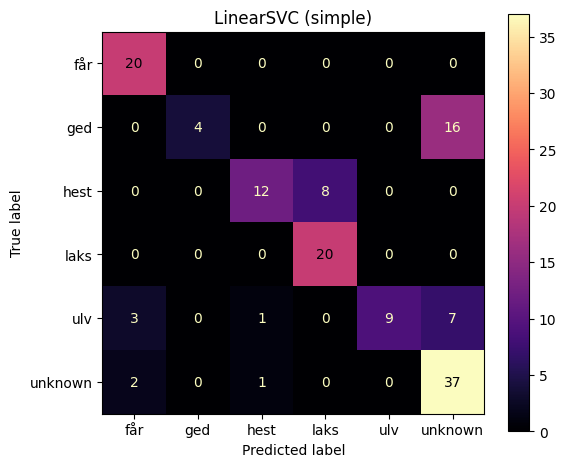


Model: SVC
Feature set: simple
Family: kernel
EMLearn compatible: False
Number of features: 9
Accuracy: 0.7786
Macro F1: 0.7720
Weighted F1: 0.7707
              precision    recall  f1-score   support

         får       0.89      0.85      0.87        20
         ged       0.78      0.70      0.74        20
        hest       0.86      0.90      0.88        20
        laks       0.88      0.75      0.81        20
         ulv       1.00      0.40      0.57        20
     unknown       0.65      0.93      0.76        40

    accuracy                           0.78       140
   macro avg       0.84      0.75      0.77       140
weighted avg       0.82      0.78      0.77       140



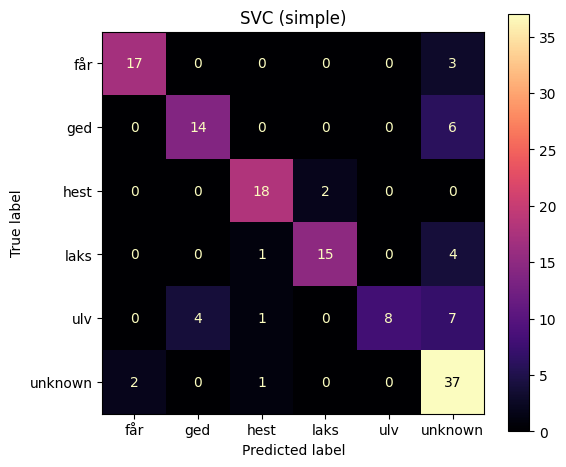


Model: KNeighbors
Feature set: simple
Family: neighbors
EMLearn compatible: True
Number of features: 9
Accuracy: 0.8071
Macro F1: 0.7906
Weighted F1: 0.7947
              precision    recall  f1-score   support

         får       0.76      0.95      0.84        20
         ged       0.83      0.75      0.79        20
        hest       0.85      0.85      0.85        20
        laks       0.80      1.00      0.89        20
         ulv       0.89      0.40      0.55        20
     unknown       0.79      0.85      0.82        40

    accuracy                           0.81       140
   macro avg       0.82      0.80      0.79       140
weighted avg       0.82      0.81      0.79       140



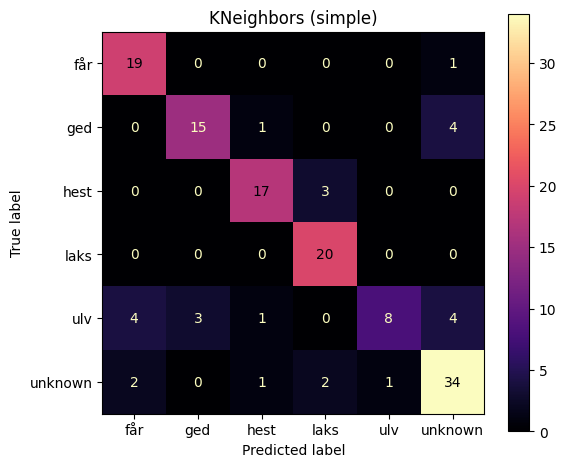


Model: DecisionTree
Feature set: simple
Family: tree
EMLearn compatible: True
Number of features: 9
Accuracy: 0.5500
Macro F1: 0.5848
Weighted F1: 0.5482
              precision    recall  f1-score   support

         får       1.00      0.55      0.71        20
         ged       0.73      0.55      0.63        20
        hest       0.41      1.00      0.58        20
        laks       0.80      0.80      0.80        20
         ulv       1.00      0.30      0.46        20
     unknown       0.33      0.33      0.33        40

    accuracy                           0.55       140
   macro avg       0.71      0.59      0.58       140
weighted avg       0.66      0.55      0.55       140



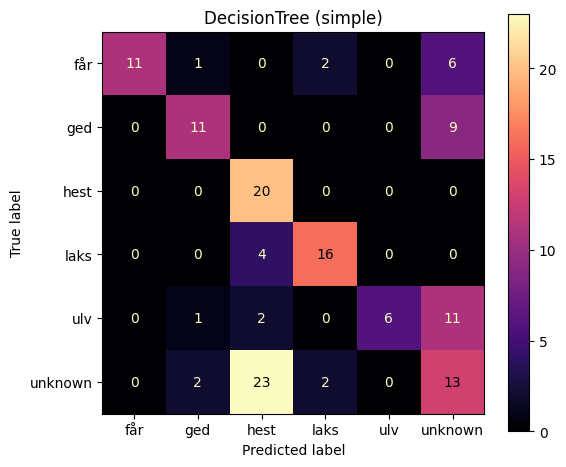


Model: RandomForest
Feature set: simple
Family: ensemble
EMLearn compatible: True
Number of features: 9
Accuracy: 0.5429
Macro F1: 0.5475
Weighted F1: 0.5276
              precision    recall  f1-score   support

         får       1.00      0.55      0.71        20
         ged       1.00      0.10      0.18        20
        hest       0.45      1.00      0.62        20
        laks       0.89      0.80      0.84        20
         ulv       1.00      0.35      0.52        20
     unknown       0.34      0.50      0.41        40

    accuracy                           0.54       140
   macro avg       0.78      0.55      0.55       140
weighted avg       0.72      0.54      0.53       140



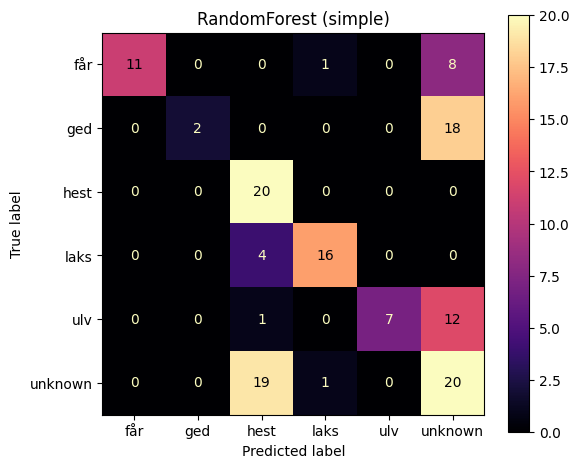


Model: ExtraTrees
Feature set: simple
Family: ensemble
EMLearn compatible: True
Number of features: 9
Accuracy: 0.6786
Macro F1: 0.6255
Weighted F1: 0.6297
              precision    recall  f1-score   support

         får       1.00      0.60      0.75        20
         ged       1.00      0.20      0.33        20
        hest       0.83      1.00      0.91        20
        laks       0.95      0.90      0.92        20
         ulv       1.00      0.10      0.18        20
     unknown       0.49      0.97      0.66        40

    accuracy                           0.68       140
   macro avg       0.88      0.63      0.63       140
weighted avg       0.82      0.68      0.63       140



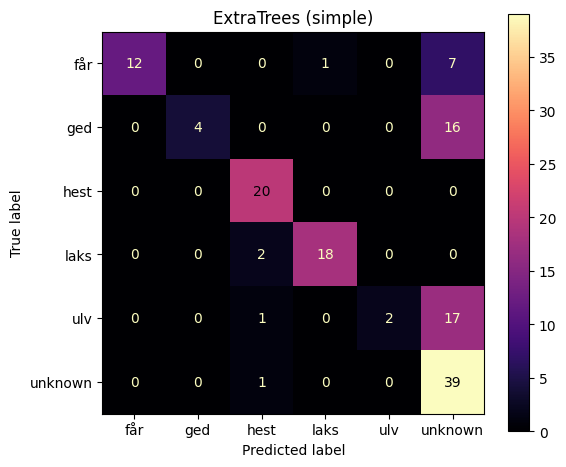


Model: MLPClassifier
Feature set: simple
Family: neural_network
EMLearn compatible: True
Number of features: 9
Accuracy: 0.6929
Macro F1: 0.6631
Weighted F1: 0.6755
              precision    recall  f1-score   support

         får       0.81      0.85      0.83        20
         ged       0.78      0.35      0.48        20
        hest       0.62      0.65      0.63        20
        laks       0.64      0.80      0.71        20
         ulv       1.00      0.40      0.57        20
     unknown       0.64      0.90      0.75        40

    accuracy                           0.69       140
   macro avg       0.75      0.66      0.66       140
weighted avg       0.73      0.69      0.68       140



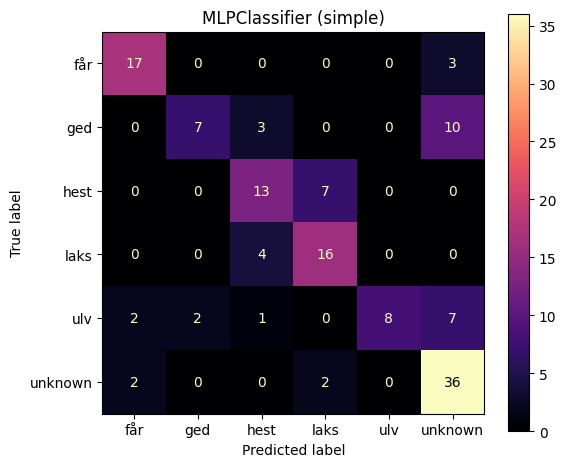


Model: LinearSVC
Feature set: mel10
Family: linear
EMLearn compatible: False
Number of features: 10
Accuracy: 0.5786
Macro F1: 0.6547
Weighted F1: 0.6020
              precision    recall  f1-score   support

         får       0.92      0.55      0.69        20
         ged       1.00      0.60      0.75        20
        hest       0.35      0.85      0.49        20
        laks       1.00      0.80      0.89        20
         ulv       1.00      0.70      0.82        20
     unknown       0.30      0.28      0.29        40

    accuracy                           0.58       140
   macro avg       0.76      0.63      0.65       140
weighted avg       0.69      0.58      0.60       140



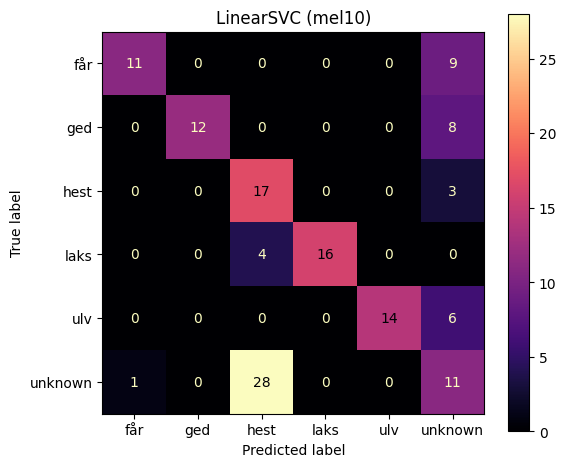


Model: SVC
Feature set: mel10
Family: kernel
EMLearn compatible: False
Number of features: 10
Accuracy: 0.6786
Macro F1: 0.6686
Weighted F1: 0.6675
              precision    recall  f1-score   support

         får       1.00      0.45      0.62        20
         ged       0.93      0.65      0.76        20
        hest       0.78      0.90      0.84        20
        laks       1.00      0.50      0.67        20
         ulv       1.00      0.30      0.46        20
     unknown       0.50      0.97      0.66        40

    accuracy                           0.68       140
   macro avg       0.87      0.63      0.67       140
weighted avg       0.82      0.68      0.67       140



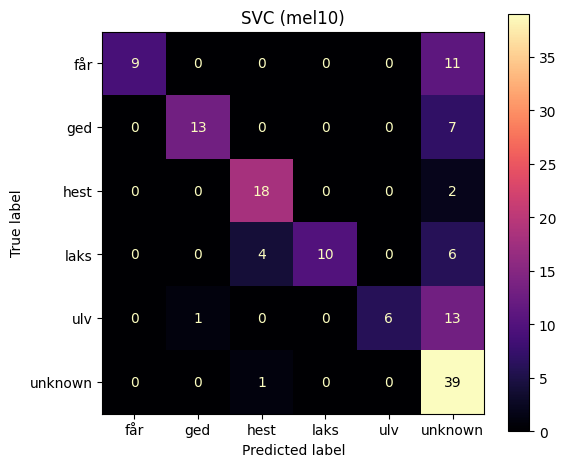


Model: KNeighbors
Feature set: mel10
Family: neighbors
EMLearn compatible: True
Number of features: 10
Accuracy: 0.7214
Macro F1: 0.7071
Weighted F1: 0.7093
              precision    recall  f1-score   support

         får       0.82      0.45      0.58        20
         ged       0.94      0.75      0.83        20
        hest       0.72      0.90      0.80        20
        laks       1.00      0.65      0.79        20
         ulv       1.00      0.35      0.52        20
     unknown       0.57      0.97      0.72        40

    accuracy                           0.72       140
   macro avg       0.84      0.68      0.71       140
weighted avg       0.80      0.72      0.71       140



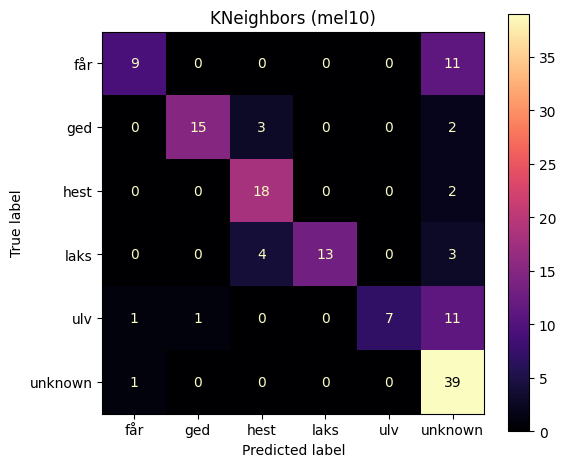


Model: DecisionTree
Feature set: mel10
Family: tree
EMLearn compatible: True
Number of features: 10
Accuracy: 0.7357
Macro F1: 0.7480
Weighted F1: 0.7373
              precision    recall  f1-score   support

         får       1.00      0.75      0.86        20
         ged       1.00      0.50      0.67        20
        hest       0.69      0.90      0.78        20
        laks       0.84      0.80      0.82        20
         ulv       0.92      0.55      0.69        20
     unknown       0.57      0.82      0.67        40

    accuracy                           0.74       140
   macro avg       0.84      0.72      0.75       140
weighted avg       0.80      0.74      0.74       140



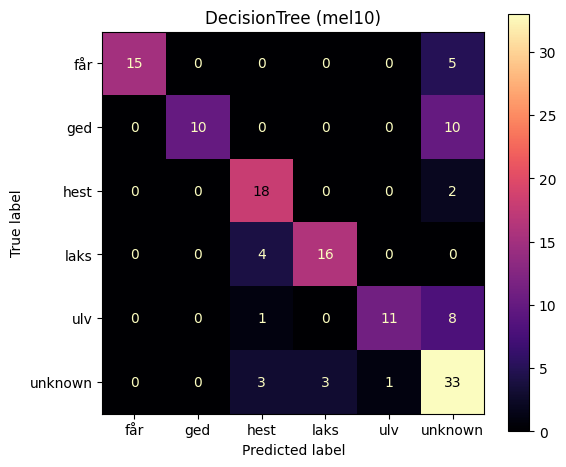


Model: RandomForest
Feature set: mel10
Family: ensemble
EMLearn compatible: True
Number of features: 10
Accuracy: 0.7429
Macro F1: 0.7270
Weighted F1: 0.7216
              precision    recall  f1-score   support

         får       1.00      0.80      0.89        20
         ged       1.00      0.30      0.46        20
        hest       1.00      0.90      0.95        20
        laks       1.00      0.95      0.97        20
         ulv       1.00      0.25      0.40        20
     unknown       0.53      1.00      0.69        40

    accuracy                           0.74       140
   macro avg       0.92      0.70      0.73       140
weighted avg       0.86      0.74      0.72       140



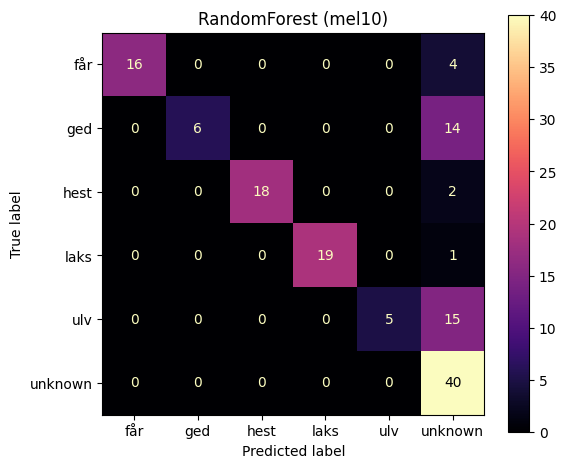


Model: ExtraTrees
Feature set: mel10
Family: ensemble
EMLearn compatible: True
Number of features: 10
Accuracy: 0.5429
Macro F1: 0.4775
Weighted F1: 0.4900
              precision    recall  f1-score   support

         får       1.00      0.45      0.62        20
         ged       0.00      0.00      0.00        20
        hest       0.64      0.45      0.53        20
        laks       1.00      0.80      0.89        20
         ulv       1.00      0.15      0.26        20
     unknown       0.40      0.97      0.57        40

    accuracy                           0.54       140
   macro avg       0.67      0.47      0.48       140
weighted avg       0.63      0.54      0.49       140



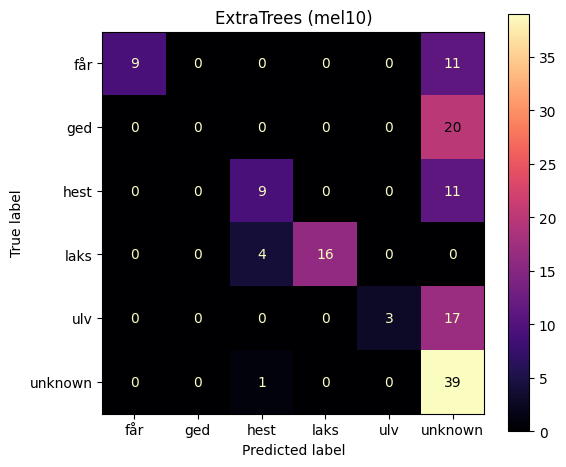


Model: MLPClassifier
Feature set: mel10
Family: neural_network
EMLearn compatible: True
Number of features: 10
Accuracy: 0.7214
Macro F1: 0.7368
Weighted F1: 0.7285
              precision    recall  f1-score   support

         får       1.00      0.65      0.79        20
         ged       1.00      0.60      0.75        20
        hest       0.70      0.80      0.74        20
        laks       1.00      0.60      0.75        20
         ulv       1.00      0.55      0.71        20
     unknown       0.54      0.93      0.68        40

    accuracy                           0.72       140
   macro avg       0.87      0.69      0.74       140
weighted avg       0.82      0.72      0.73       140



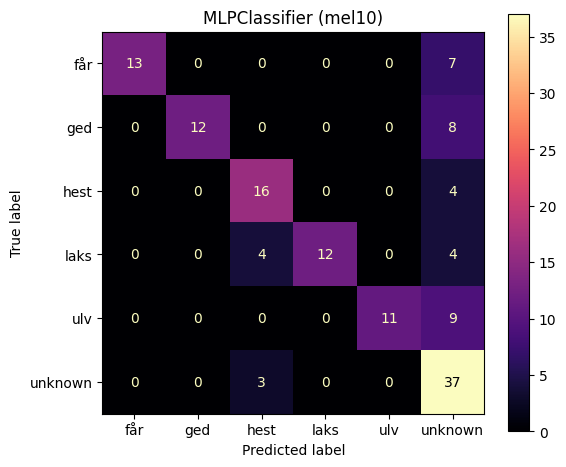


Model: LinearSVC
Feature set: simple_mel10
Family: linear
EMLearn compatible: False
Number of features: 19
Accuracy: 0.9500
Macro F1: 0.9538
Weighted F1: 0.9499
              precision    recall  f1-score   support

         får       0.95      1.00      0.98        20
         ged       1.00      0.90      0.95        20
        hest       0.95      1.00      0.98        20
        laks       0.95      0.95      0.95        20
         ulv       1.00      0.90      0.95        20
     unknown       0.90      0.95      0.93        40

    accuracy                           0.95       140
   macro avg       0.96      0.95      0.95       140
weighted avg       0.95      0.95      0.95       140



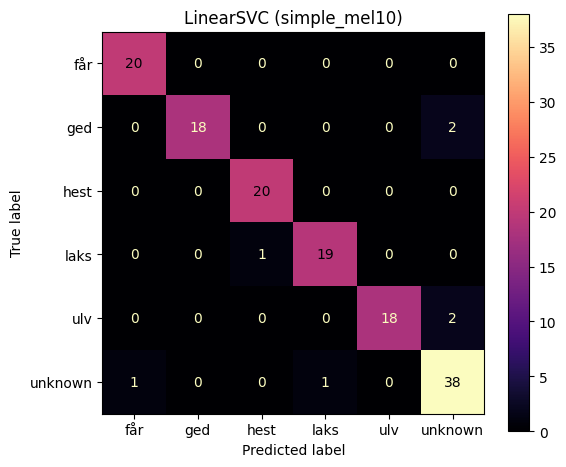


Model: SVC
Feature set: simple_mel10
Family: kernel
EMLearn compatible: False
Number of features: 19
Accuracy: 0.7429
Macro F1: 0.7387
Weighted F1: 0.7336
              precision    recall  f1-score   support

         får       1.00      0.40      0.57        20
         ged       0.88      0.75      0.81        20
        hest       0.91      1.00      0.95        20
        laks       1.00      0.70      0.82        20
         ulv       1.00      0.40      0.57        20
     unknown       0.55      0.97      0.70        40

    accuracy                           0.74       140
   macro avg       0.89      0.70      0.74       140
weighted avg       0.84      0.74      0.73       140



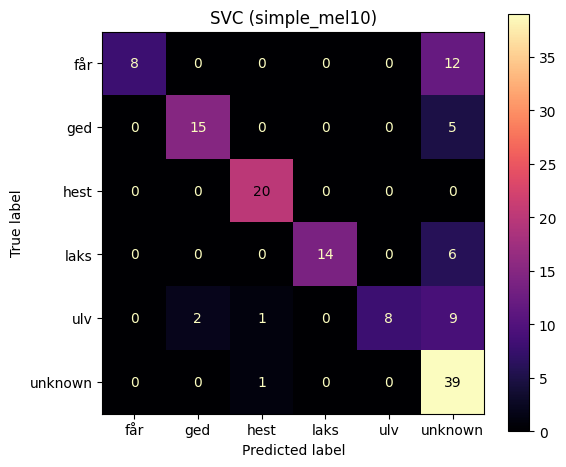


Model: KNeighbors
Feature set: simple_mel10
Family: neighbors
EMLearn compatible: True
Number of features: 19
Accuracy: 0.8286
Macro F1: 0.8217
Weighted F1: 0.8239
              precision    recall  f1-score   support

         får       0.67      0.60      0.63        20
         ged       0.94      0.85      0.89        20
        hest       0.79      0.95      0.86        20
        laks       0.95      1.00      0.98        20
         ulv       0.92      0.60      0.73        20
     unknown       0.78      0.90      0.84        40

    accuracy                           0.83       140
   macro avg       0.84      0.82      0.82       140
weighted avg       0.83      0.83      0.82       140



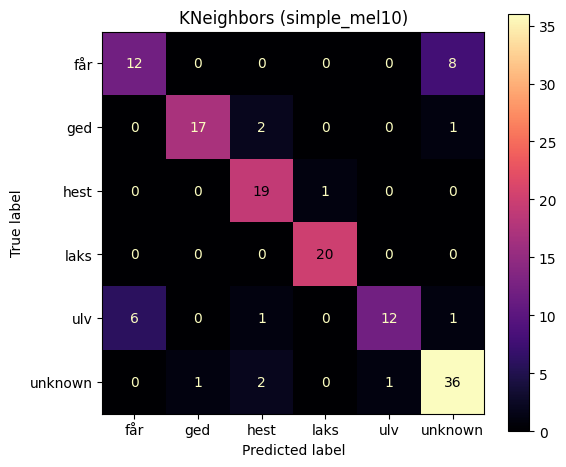


Model: DecisionTree
Feature set: simple_mel10
Family: tree
EMLearn compatible: True
Number of features: 19
Accuracy: 0.5714
Macro F1: 0.5936
Weighted F1: 0.5628
              precision    recall  f1-score   support

         får       1.00      0.55      0.71        20
         ged       0.75      0.75      0.75        20
        hest       0.38      1.00      0.55        20
        laks       0.89      0.80      0.84        20
         ulv       1.00      0.20      0.33        20
     unknown       0.41      0.35      0.38        40

    accuracy                           0.57       140
   macro avg       0.74      0.61      0.59       140
weighted avg       0.69      0.57      0.56       140



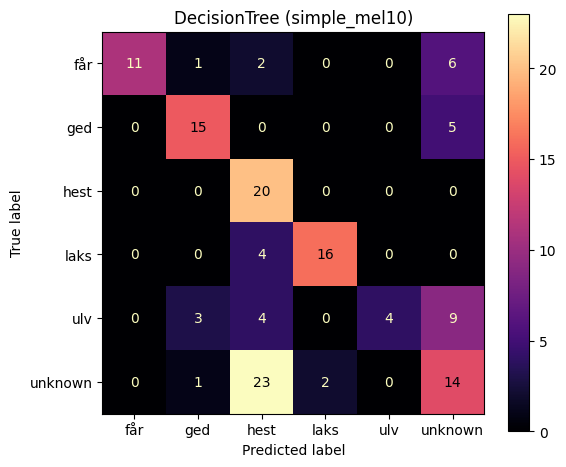


Model: RandomForest
Feature set: simple_mel10
Family: ensemble
EMLearn compatible: True
Number of features: 19
Accuracy: 0.7000
Macro F1: 0.7146
Weighted F1: 0.6986
              precision    recall  f1-score   support

         får       1.00      0.75      0.86        20
         ged       1.00      0.65      0.79        20
        hest       0.56      1.00      0.71        20
        laks       0.94      0.80      0.86        20
         ulv       1.00      0.30      0.46        20
     unknown       0.53      0.70      0.60        40

    accuracy                           0.70       140
   macro avg       0.84      0.70      0.71       140
weighted avg       0.79      0.70      0.70       140



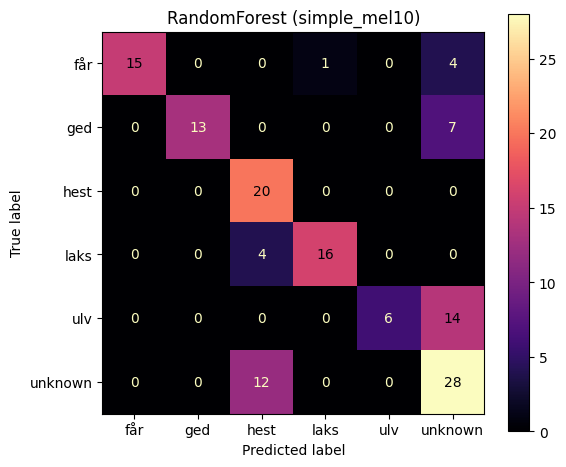


Model: ExtraTrees
Feature set: simple_mel10
Family: ensemble
EMLearn compatible: True
Number of features: 19
Accuracy: 0.7000
Macro F1: 0.6330
Weighted F1: 0.6386
              precision    recall  f1-score   support

         får       1.00      0.70      0.82        20
         ged       0.00      0.00      0.00        20
        hest       0.95      0.95      0.95        20
        laks       0.91      1.00      0.95        20
         ulv       1.00      0.25      0.40        20
     unknown       0.51      1.00      0.67        40

    accuracy                           0.70       140
   macro avg       0.73      0.65      0.63       140
weighted avg       0.70      0.70      0.64       140



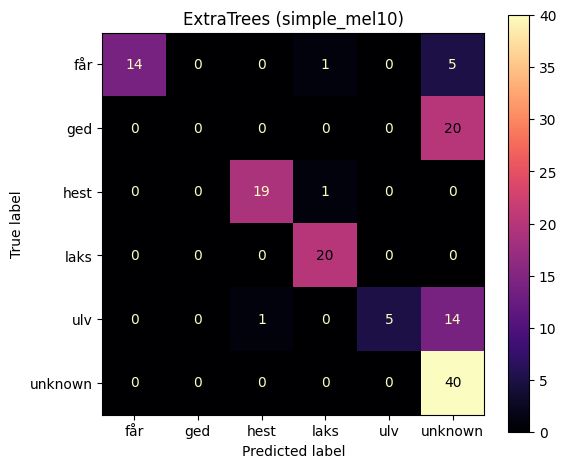


Model: MLPClassifier
Feature set: simple_mel10
Family: neural_network
EMLearn compatible: True
Number of features: 19
Accuracy: 0.5929
Macro F1: 0.6510
Weighted F1: 0.6031
              precision    recall  f1-score   support

         får       1.00      0.50      0.67        20
         ged       1.00      0.45      0.62        20
        hest       0.38      1.00      0.56        20
        laks       1.00      0.90      0.95        20
         ulv       0.93      0.70      0.80        20
     unknown       0.33      0.30      0.32        40

    accuracy                           0.59       140
   macro avg       0.78      0.64      0.65       140
weighted avg       0.71      0.59      0.60       140



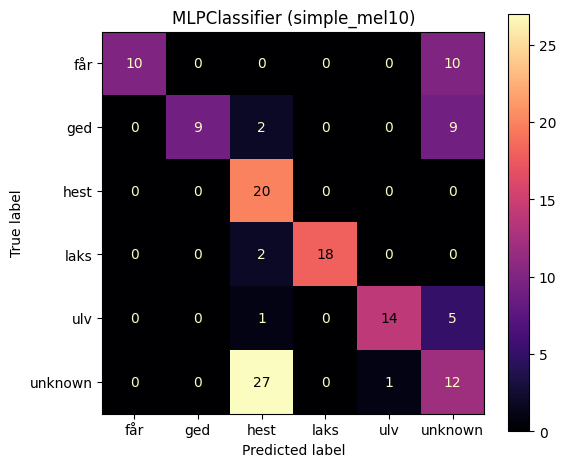


Summary sorted by accuracy:
            model          family      features  n_features  accuracy  \
14      LinearSVC          linear  simple_mel10          19  0.950000   
16     KNeighbors       neighbors  simple_mel10          19  0.828571   
2      KNeighbors       neighbors        simple           9  0.807143   
1             SVC          kernel        simple           9  0.778571   
11   RandomForest        ensemble         mel10          10  0.742857   
15            SVC          kernel  simple_mel10          19  0.742857   
10   DecisionTree            tree         mel10          10  0.735714   
0       LinearSVC          linear        simple           9  0.728571   
13  MLPClassifier  neural_network         mel10          10  0.721429   
9      KNeighbors       neighbors         mel10          10  0.721429   
18   RandomForest        ensemble  simple_mel10          19  0.700000   
19     ExtraTrees        ensemble  simple_mel10          19  0.700000   
6   MLPClassifier  neu

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import soundfile as sf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    accuracy_score,
    classification_report,
    f1_score,
)

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier


# =========================
# SETTINGS
# =========================
TRAIN_KEYWORDS_DIR = Path("prepared_words")
TRAIN_UNKNOWN_DIR = Path("unknown_balanced")
TEST_DIR = Path("test_ready_chjem1")   # change to "test_ready" if needed

KEYWORD_LABELS = ["får", "ged", "hest", "laks", "ulv"]
ALL_LABELS = KEYWORD_LABELS + ["unknown"]

SAMPLE_RATE = 16000

FFT_N = 4096
FFT_HOP = FFT_N // 2
N_MELS = 10
EPS = 1e-12

SAVE_RESULTS_CSV = True
RESULTS_CSV = Path("model_feature_results_multiwindow_mel10.csv")


# =========================
# AUDIO HELPERS
# =========================
def load_wav(path: Path) -> np.ndarray:
    x, fs = sf.read(str(path), always_2d=False)
    x = np.asarray(x, dtype=np.float32)

    if x.ndim > 1:
        x = x.mean(axis=1)

    if fs != SAMPLE_RATE:
        raise ValueError(f"Unexpected sample rate in {path}: {fs}")

    peak = np.max(np.abs(x)) + 1e-9
    x = x / peak

    return x


def rms_energy(x: np.ndarray) -> float:
    return float(np.sqrt(np.mean(x ** 2) + 1e-12))


def zero_crossing_rate(x: np.ndarray) -> float:
    return float(np.mean(np.signbit(x[1:]) != np.signbit(x[:-1])))


# =========================
# EMLearn-like Mel helpers
# =========================
def hz_to_mel(hz: float) -> float:
    return 2595.0 * np.log10(1.0 + hz / 700.0)


def mel_to_hz(mels: float) -> float:
    return 700.0 * (10.0 ** (mels / 2595.0) - 1.0)


def eml_audio_mel_center(n: int, n_mels: int, fmin: float, fmax: float) -> float:
    melmin = hz_to_mel(fmin)
    melmax = hz_to_mel(fmax)
    melstep = (melmax - melmin) / (n_mels + 1)
    mel = melmin + n * melstep
    return mel_to_hz(mel)


def eml_audio_mel_bin(hz: float, n_fft: int, samplerate: float) -> int:
    return int(np.floor((n_fft + 1) * hz / samplerate))


def eml_fft_freq(k: int, n_fft: int, samplerate: float) -> float:
    end = samplerate / 2.0
    steps = (1 + n_fft // 2) - 1
    return (k * end) / steps


# =========================
# MULTI-WINDOW FFT
# =========================
def iter_fft_frames(x: np.ndarray, fft_n: int = FFT_N, hop: int = FFT_HOP):
    """
    Generate multiple Hann-windowed FFT frames over the full clip.
    The final window is forced to include the end of the signal.
    """

    if len(x) <= fft_n:
        starts = [0]
    else:
        starts = list(range(0, len(x) - fft_n + 1, hop))
        last_start = len(x) - fft_n

        if starts[-1] != last_start:
            starts.append(last_start)

    window = np.hanning(fft_n).astype(np.float32)

    for start in starts:
        frame = np.zeros(fft_n, dtype=np.float32)

        end = min(start + fft_n, len(x))
        frame[:end - start] = x[start:end]

        frame *= window

        yield frame


def magnitude_spectrum_frame(frame: np.ndarray, fs: float):
    spec = np.fft.rfft(frame)
    mag = np.abs(spec).astype(np.float32)

    freqs = np.fft.rfftfreq(
        FFT_N,
        d=1 / fs
    ).astype(np.float32)

    return freqs, mag


# =========================
# SIMPLE MULTI-WINDOW FEATURES
# =========================
def spectral_features_one_frame(frame: np.ndarray, fs: float) -> np.ndarray:
    freqs, mag = magnitude_spectrum_frame(frame, fs)
    power = mag ** 2

    centroid = float(
        np.sum(freqs * mag) /
        (np.sum(mag) + EPS)
    )

    cumsum = np.cumsum(mag)
    threshold = 0.85 * cumsum[-1]
    idx = np.searchsorted(cumsum, threshold)

    rolloff = float(freqs[min(idx, len(freqs) - 1)])

    dominant = float(
        freqs[np.argmax(mag[1:]) + 1]
    ) if len(mag) > 1 else 0.0

    band0_500 = float(np.sum(power[(freqs >= 0) & (freqs < 500)]))
    band500_1500 = float(np.sum(power[(freqs >= 500) & (freqs < 1500)]))
    band1500_3000 = float(np.sum(power[(freqs >= 1500) & (freqs < 3000)]))
    band3000_6000 = float(np.sum(power[(freqs >= 3000) & (freqs < 6000)]))

    return np.array([
        centroid,
        rolloff,
        dominant,
        band0_500,
        band500_1500,
        band1500_3000,
        band3000_6000,
    ], dtype=np.float32)


def spectral_features_multiwindow(x: np.ndarray, fs: float) -> np.ndarray:
    vals = []

    for frame in iter_fft_frames(x, fft_n=FFT_N, hop=FFT_HOP):
        vals.append(spectral_features_one_frame(frame, fs))

    vals = np.asarray(vals, dtype=np.float32)

    return np.mean(vals, axis=0)


# =========================
# MEL10 MULTI-WINDOW FEATURES
# =========================
def mel_spectrum_one_frame_emlearn_style(
    frame: np.ndarray,
    fs: float,
    n_mels: int = N_MELS,
) -> np.ndarray:
    """
    Mel calculation written to be close to emlearn C/C++:
    FFT -> real-part power -> triangular Mel filters.
    """

    spec = np.fft.rfft(frame)
    real_part = np.real(spec).astype(np.float32)
    power = (np.abs(real_part) ** 2) / float(FFT_N)

    fmin = 0.0
    fmax = fs / 2.0
    max_bin = 1 + FFT_N // 2

    mels = np.zeros(n_mels, dtype=np.float32)

    for m in range(1, n_mels + 1):
        left_hz = eml_audio_mel_center(m - 1, n_mels, fmin, fmax)
        center_hz = eml_audio_mel_center(m, n_mels, fmin, fmax)
        right_hz = eml_audio_mel_center(m + 1, n_mels, fmin, fmax)

        left = eml_audio_mel_bin(left_hz, FFT_N, fs)
        center = eml_audio_mel_bin(center_hz, FFT_N, fs)
        right = eml_audio_mel_bin(right_hz, FFT_N, fs)

        left = max(0, min(left, max_bin - 1))
        center = max(0, min(center, max_bin - 1))
        right = max(0, min(right, max_bin - 1))

        fdifflow = center_hz - left_hz
        fdiffupper = right_hz - center_hz

        val = 0.0

        for k in range(left, center + 1):
            r = left_hz - eml_fft_freq(k, FFT_N, fs)
            weight = max(
                min(-r / fdifflow if fdifflow != 0 else 0.0, 1.0),
                0.0
            )
            val += power[k] * weight

        for k in range(center, right):
            if k + 1 >= len(power):
                break

            r = right_hz - eml_fft_freq(k + 1, FFT_N, fs)
            weight = max(
                min(r / fdiffupper if fdiffupper != 0 else 0.0, 1.0),
                0.0
            )
            val += power[k + 1] * weight

        mels[m - 1] = val

    return mels


def mel_spectrum_multiwindow(x: np.ndarray, fs: float) -> np.ndarray:
    vals = []

    for frame in iter_fft_frames(x, fft_n=FFT_N, hop=FFT_HOP):
        vals.append(
            mel_spectrum_one_frame_emlearn_style(
                frame,
                fs,
                n_mels=N_MELS
            )
        )

    vals = np.asarray(vals, dtype=np.float32)

    return np.mean(vals, axis=0)


# =========================
# FEATURE EXTRACTION
# =========================
def extract_features(x: np.ndarray, fs: float) -> dict:
    spectral = spectral_features_multiwindow(x, fs)
    mel_vals = mel_spectrum_multiwindow(x, fs)

    record = {
        "rms": rms_energy(x),
        "zcr": zero_crossing_rate(x),
        "centroid": float(spectral[0]),
        "rolloff": float(spectral[1]),
        "dominant_freq": float(spectral[2]),
        "band_0_500": float(spectral[3]),
        "band_500_1500": float(spectral[4]),
        "band_1500_3000": float(spectral[5]),
        "band_3000_6000": float(spectral[6]),
    }

    for i, val in enumerate(mel_vals, start=1):
        record[f"mel_{i}"] = float(val)

    return record


# =========================
# BUILD DATAFRAMES
# =========================
def build_dataframe():
    train_records = []

    for label in KEYWORD_LABELS:
        for wav_path in sorted((TRAIN_KEYWORDS_DIR / label).glob("*.wav")):
            x = load_wav(wav_path)
            record = extract_features(x, SAMPLE_RATE)
            record["activity"] = label
            record["filename"] = wav_path.name
            train_records.append(record)

    for wav_path in sorted(TRAIN_UNKNOWN_DIR.glob("*.wav")):
        x = load_wav(wav_path)
        record = extract_features(x, SAMPLE_RATE)
        record["activity"] = "unknown"
        record["filename"] = wav_path.name
        train_records.append(record)

    test_records = []

    for label in ALL_LABELS:
        for wav_path in sorted((TEST_DIR / label).glob("*.wav")):
            x = load_wav(wav_path)
            record = extract_features(x, SAMPLE_RATE)
            record["activity"] = label
            record["filename"] = wav_path.name
            test_records.append(record)

    return pd.DataFrame(train_records), pd.DataFrame(test_records)


# =========================
# FEATURE SETS
# =========================
simple_features = [
    "rms",
    "zcr",
    "centroid",
    "rolloff",
    "dominant_freq",
    "band_0_500",
    "band_500_1500",
    "band_1500_3000",
    "band_3000_6000",
]

mel_feature_cols = [
    f"mel_{i}" for i in range(1, N_MELS + 1)
]

feature_sets = {
    "simple": simple_features,
    "mel10": mel_feature_cols,
    "simple_mel10": simple_features + mel_feature_cols,
}


# =========================
# MODEL CANDIDATES
# =========================
models = {
    "LinearSVC": {
        "model": make_pipeline(
            StandardScaler(),
            LinearSVC(max_iter=10000)
        ),
        "emlearn_compatible": False,
        "family": "linear",
    },

    "SVC": {
        "model": make_pipeline(
            StandardScaler(),
            SVC(kernel="rbf", C=1.0, gamma="scale")
        ),
        "emlearn_compatible": False,
        "family": "kernel",
    },

    "KNeighbors": {
        "model": make_pipeline(
            StandardScaler(),
            KNeighborsClassifier(n_neighbors=5)
        ),
        "emlearn_compatible": True,
        "family": "neighbors",
    },

    "DecisionTree": {
        "model": DecisionTreeClassifier(
            max_depth=8,
            min_samples_leaf=5,
            random_state=42
        ),
        "emlearn_compatible": True,
        "family": "tree",
    },

    "RandomForest": {
        "model": RandomForestClassifier(
            n_estimators=20,
            max_depth=6,
            min_samples_leaf=5,
            random_state=42
        ),
        "emlearn_compatible": True,
        "family": "ensemble",
    },

    "ExtraTrees": {
        "model": ExtraTreesClassifier(
            n_estimators=20,
            max_depth=6,
            min_samples_leaf=5,
            random_state=42
        ),
        "emlearn_compatible": True,
        "family": "ensemble",
    },

    "MLPClassifier": {
        "model": make_pipeline(
            StandardScaler(),
            MLPClassifier(
                hidden_layer_sizes=(16,),
                activation="relu",
                max_iter=2000,
                random_state=42
            )
        ),
        "emlearn_compatible": True,
        "family": "neural_network",
    },
}


# =========================
# TRAIN / EVALUATE
# =========================
def train_and_evaluate(train_df: pd.DataFrame, test_df: pd.DataFrame):
    results = []

    for feat_name, feat_cols in feature_sets.items():
        X_train = train_df[feat_cols]
        y_train = train_df["activity"]

        X_test = test_df[feat_cols]
        y_test = test_df["activity"]

        for model_name, info in models.items():
            model = info["model"]

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            acc = accuracy_score(y_test, y_pred)
            macro_f1 = f1_score(
                y_test,
                y_pred,
                labels=ALL_LABELS,
                average="macro",
                zero_division=0
            )
            weighted_f1 = f1_score(
                y_test,
                y_pred,
                labels=ALL_LABELS,
                average="weighted",
                zero_division=0
            )

            results.append({
                "model": model_name,
                "family": info["family"],
                "features": feat_name,
                "n_features": len(feat_cols),
                "accuracy": acc,
                "macro_f1": macro_f1,
                "weighted_f1": weighted_f1,
                "emlearn_compatible": info["emlearn_compatible"],
            })

            print("\n" + "=" * 60)
            print(f"Model: {model_name}")
            print(f"Feature set: {feat_name}")
            print(f"Family: {info['family']}")
            print(f"EMLearn compatible: {info['emlearn_compatible']}")
            print(f"Number of features: {len(feat_cols)}")
            print(f"Accuracy: {acc:.4f}")
            print(f"Macro F1: {macro_f1:.4f}")
            print(f"Weighted F1: {weighted_f1:.4f}")
            print(classification_report(
                y_test,
                y_pred,
                labels=ALL_LABELS,
                zero_division=0
            ))

            # Plot every confusion matrix, like your previous script
            cm = confusion_matrix(y_test, y_pred, labels=ALL_LABELS)

            disp = ConfusionMatrixDisplay(
                confusion_matrix=cm,
                display_labels=ALL_LABELS
            )

            fig, ax = plt.subplots(figsize=(6, 5))
            disp.plot(ax=ax, cmap="magma", values_format="d")
            plt.title(f"{model_name} ({feat_name})")
            plt.tight_layout()
            plt.show()

    results_df = pd.DataFrame(results)

    print("\nSummary sorted by accuracy:")
    print(results_df.sort_values("accuracy", ascending=False))

    print("\nSummary sorted by macro F1:")
    print(results_df.sort_values("macro_f1", ascending=False))

    print("\nBest EMLearn-compatible models:")
    print(
        results_df[results_df["emlearn_compatible"] == True]
        .sort_values("macro_f1", ascending=False)
    )

    return results_df


# =========================
# MAIN
# =========================
def main():
    train_df, test_df = build_dataframe()

    print("Train samples:", len(train_df))
    print("Test samples:", len(test_df))

    results_df = train_and_evaluate(train_df, test_df)

    if SAVE_RESULTS_CSV:
        results_df.to_csv(RESULTS_CSV, index=False)
        print(f"\nSaved results to: {RESULTS_CSV}")


if __name__ == "__main__":
    main()

Train samples: 600
Test samples: 140

Model: LinearSVC
Feature set: simple
Family: linear
EMLearn compatible: False
Number of features: 9
Accuracy: 0.4929
Macro F1: 0.3583
Weighted F1: 0.3833
              precision    recall  f1-score   support

         får       0.00      0.00      0.00        20
         ged       0.00      0.00      0.00        20
        hest       1.00      0.50      0.67        20
        laks       0.95      0.95      0.95        20
         ulv       0.00      0.00      0.00        20
     unknown       0.36      1.00      0.53        40

    accuracy                           0.49       140
   macro avg       0.39      0.41      0.36       140
weighted avg       0.38      0.49      0.38       140



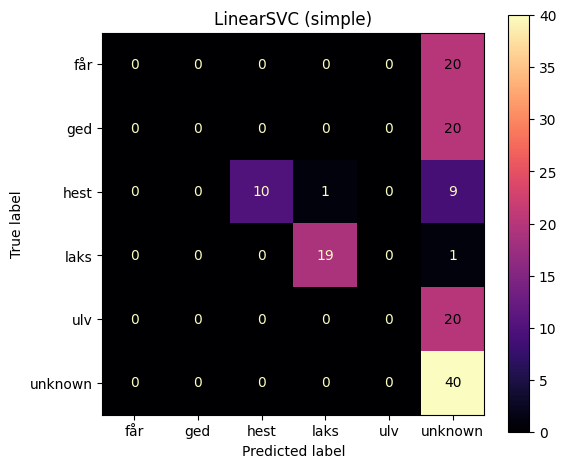


Model: SVC
Feature set: simple
Family: kernel
EMLearn compatible: False
Number of features: 9
Accuracy: 0.6071
Macro F1: 0.5178
Weighted F1: 0.5276
              precision    recall  f1-score   support

         får       0.00      0.00      0.00        20
         ged       0.00      0.00      0.00        20
        hest       1.00      0.95      0.97        20
        laks       1.00      0.95      0.97        20
         ulv       1.00      0.40      0.57        20
     unknown       0.42      0.97      0.59        40

    accuracy                           0.61       140
   macro avg       0.57      0.55      0.52       140
weighted avg       0.55      0.61      0.53       140



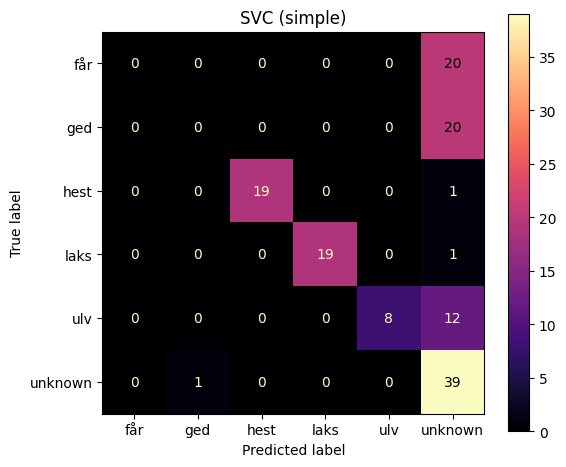


Model: KNeighbors
Feature set: simple
Family: neighbors
EMLearn compatible: True
Number of features: 9
Accuracy: 0.6071
Macro F1: 0.5477
Weighted F1: 0.5530
              precision    recall  f1-score   support

         får       1.00      0.10      0.18        20
         ged       0.83      0.25      0.38        20
        hest       0.90      0.90      0.90        20
        laks       1.00      0.95      0.97        20
         ulv       1.00      0.15      0.26        20
     unknown       0.42      0.95      0.58        40

    accuracy                           0.61       140
   macro avg       0.86      0.55      0.55       140
weighted avg       0.80      0.61      0.55       140



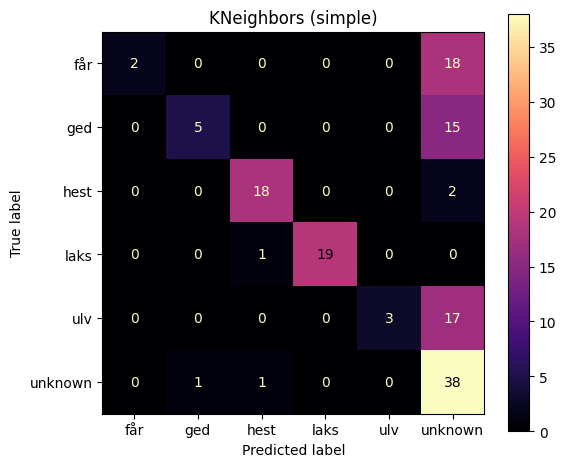


Model: DecisionTree
Feature set: simple
Family: tree
EMLearn compatible: True
Number of features: 9
Accuracy: 0.5071
Macro F1: 0.4328
Weighted F1: 0.4545
              precision    recall  f1-score   support

         får       1.00      0.80      0.89        20
         ged       0.00      0.00      0.00        20
        hest       0.67      0.30      0.41        20
        laks       1.00      0.55      0.71        20
         ulv       0.00      0.00      0.00        20
     unknown       0.42      0.95      0.58        40

    accuracy                           0.51       140
   macro avg       0.51      0.43      0.43       140
weighted avg       0.50      0.51      0.45       140



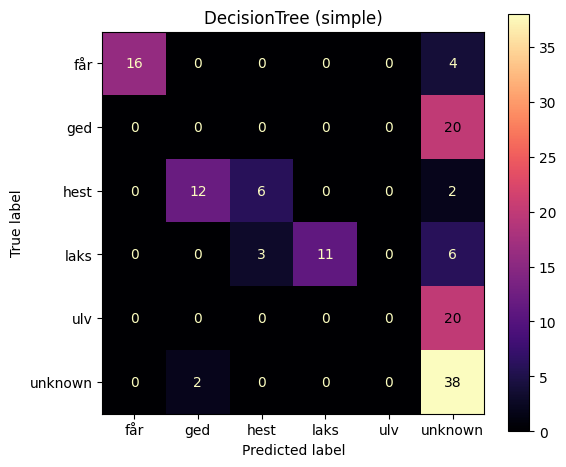


Model: RandomForest
Feature set: simple
Family: ensemble
EMLearn compatible: True
Number of features: 9
Accuracy: 0.5214
Macro F1: 0.4627
Weighted F1: 0.4749
              precision    recall  f1-score   support

         får       1.00      0.35      0.52        20
         ged       0.00      0.00      0.00        20
        hest       0.75      0.15      0.25        20
        laks       1.00      0.60      0.75        20
         ulv       1.00      0.55      0.71        20
     unknown       0.38      1.00      0.55        40

    accuracy                           0.52       140
   macro avg       0.69      0.44      0.46       140
weighted avg       0.64      0.52      0.47       140



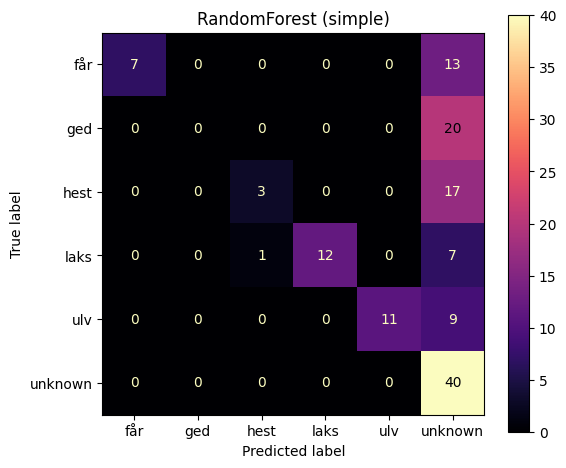


Model: ExtraTrees
Feature set: simple
Family: ensemble
EMLearn compatible: True
Number of features: 9
Accuracy: 0.5571
Macro F1: 0.4146
Weighted F1: 0.4356
              precision    recall  f1-score   support

         får       0.00      0.00      0.00        20
         ged       0.00      0.00      0.00        20
        hest       0.91      1.00      0.95        20
        laks       1.00      0.95      0.97        20
         ulv       0.00      0.00      0.00        20
     unknown       0.39      0.97      0.56        40

    accuracy                           0.56       140
   macro avg       0.38      0.49      0.41       140
weighted avg       0.39      0.56      0.44       140



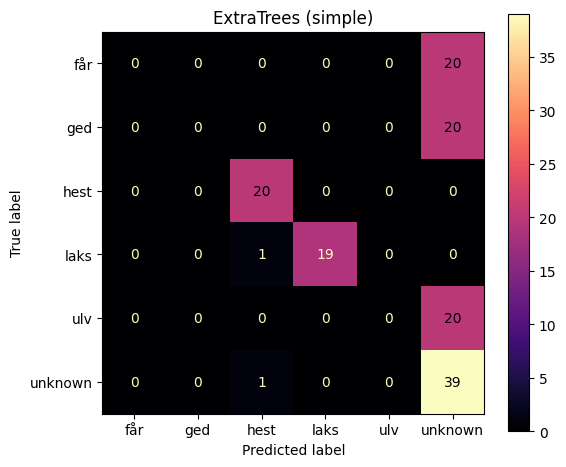


Model: MLPClassifier
Feature set: simple
Family: neural_network
EMLearn compatible: True
Number of features: 9
Accuracy: 0.4357
Macro F1: 0.3126
Weighted F1: 0.3398
              precision    recall  f1-score   support

         får       1.00      0.10      0.18        20
         ged       0.00      0.00      0.00        20
        hest       1.00      0.20      0.33        20
        laks       1.00      0.75      0.86        20
         ulv       0.00      0.00      0.00        20
     unknown       0.34      1.00      0.50        40

    accuracy                           0.44       140
   macro avg       0.56      0.34      0.31       140
weighted avg       0.52      0.44      0.34       140



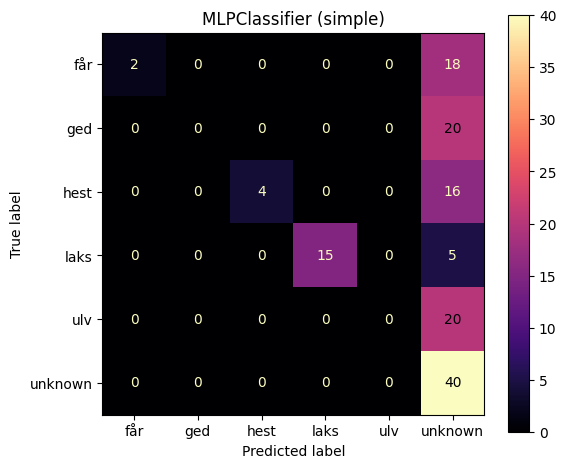


Model: LinearSVC
Feature set: mel10
Family: linear
EMLearn compatible: False
Number of features: 10
Accuracy: 0.8714
Macro F1: 0.8754
Weighted F1: 0.8658
              precision    recall  f1-score   support

         får       1.00      1.00      1.00        20
         ged       1.00      0.80      0.89        20
        hest       0.82      0.45      0.58        20
        laks       1.00      0.95      0.97        20
         ulv       1.00      1.00      1.00        20
     unknown       0.70      0.95      0.81        40

    accuracy                           0.87       140
   macro avg       0.92      0.86      0.88       140
weighted avg       0.89      0.87      0.87       140



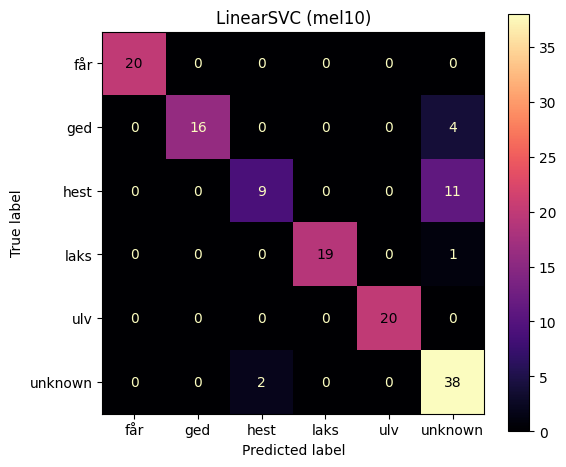


Model: SVC
Feature set: mel10
Family: kernel
EMLearn compatible: False
Number of features: 10
Accuracy: 0.8143
Macro F1: 0.7996
Weighted F1: 0.7942
              precision    recall  f1-score   support

         får       1.00      0.90      0.95        20
         ged       1.00      0.20      0.33        20
        hest       0.94      0.75      0.83        20
        laks       1.00      0.90      0.95        20
         ulv       1.00      0.95      0.97        20
     unknown       0.62      1.00      0.76        40

    accuracy                           0.81       140
   macro avg       0.93      0.78      0.80       140
weighted avg       0.88      0.81      0.79       140



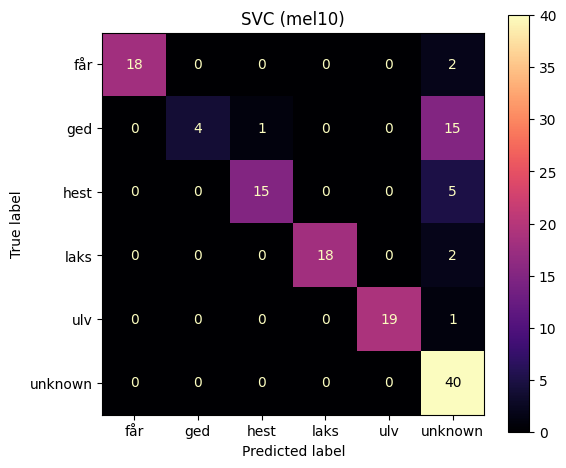


Model: KNeighbors
Feature set: mel10
Family: neighbors
EMLearn compatible: True
Number of features: 10
Accuracy: 0.8000
Macro F1: 0.7871
Weighted F1: 0.7848
              precision    recall  f1-score   support

         får       1.00      0.90      0.95        20
         ged       0.62      0.25      0.36        20
        hest       0.75      0.75      0.75        20
        laks       0.95      0.95      0.95        20
         ulv       1.00      0.90      0.95        20
     unknown       0.66      0.93      0.77        40

    accuracy                           0.80       140
   macro avg       0.83      0.78      0.79       140
weighted avg       0.81      0.80      0.78       140



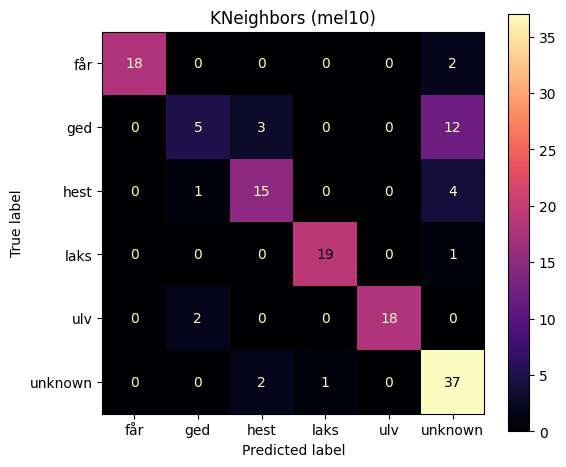


Model: DecisionTree
Feature set: mel10
Family: tree
EMLearn compatible: True
Number of features: 10
Accuracy: 0.6357
Macro F1: 0.6947
Weighted F1: 0.6296
              precision    recall  f1-score   support

         får       1.00      0.50      0.67        20
         ged       0.82      0.70      0.76        20
        hest       1.00      1.00      1.00        20
        laks       0.40      0.95      0.56        20
         ulv       1.00      0.90      0.95        20
     unknown       0.30      0.20      0.24        40

    accuracy                           0.64       140
   macro avg       0.75      0.71      0.69       140
weighted avg       0.69      0.64      0.63       140



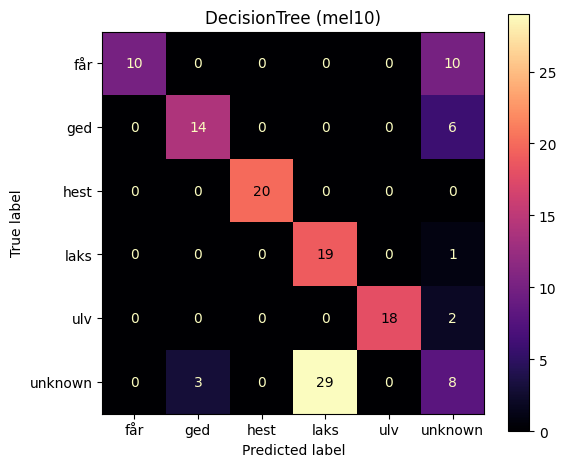


Model: RandomForest
Feature set: mel10
Family: ensemble
EMLearn compatible: True
Number of features: 10
Accuracy: 0.8000
Macro F1: 0.7934
Weighted F1: 0.7858
              precision    recall  f1-score   support

         får       1.00      0.65      0.79        20
         ged       1.00      0.25      0.40        20
        hest       1.00      0.95      0.97        20
        laks       1.00      1.00      1.00        20
         ulv       1.00      0.75      0.86        20
     unknown       0.59      1.00      0.74        40

    accuracy                           0.80       140
   macro avg       0.93      0.77      0.79       140
weighted avg       0.88      0.80      0.79       140



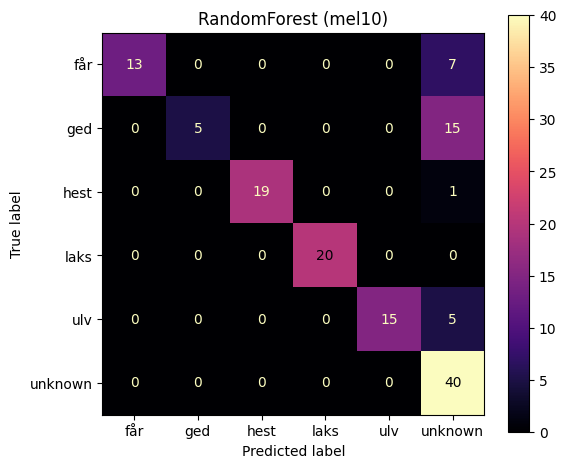


Model: ExtraTrees
Feature set: mel10
Family: ensemble
EMLearn compatible: True
Number of features: 10
Accuracy: 0.5714
Macro F1: 0.4939
Weighted F1: 0.5050
              precision    recall  f1-score   support

         får       1.00      0.70      0.82        20
         ged       0.00      0.00      0.00        20
        hest       1.00      0.20      0.33        20
        laks       1.00      0.95      0.97        20
         ulv       1.00      0.15      0.26        20
     unknown       0.40      1.00      0.57        40

    accuracy                           0.57       140
   macro avg       0.73      0.50      0.49       140
weighted avg       0.69      0.57      0.50       140



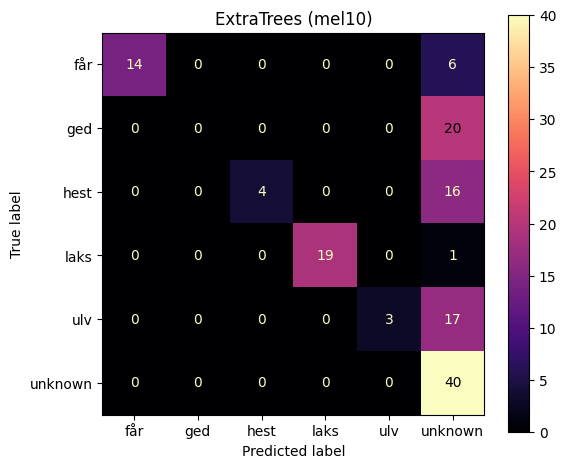


Model: MLPClassifier
Feature set: mel10
Family: neural_network
EMLearn compatible: True
Number of features: 10
Accuracy: 0.7857
Macro F1: 0.7817
Weighted F1: 0.7742
              precision    recall  f1-score   support

         får       1.00      0.85      0.92        20
         ged       1.00      0.50      0.67        20
        hest       0.75      0.30      0.43        20
        laks       1.00      0.90      0.95        20
         ulv       1.00      1.00      1.00        20
     unknown       0.58      0.97      0.73        40

    accuracy                           0.79       140
   macro avg       0.89      0.75      0.78       140
weighted avg       0.84      0.79      0.77       140



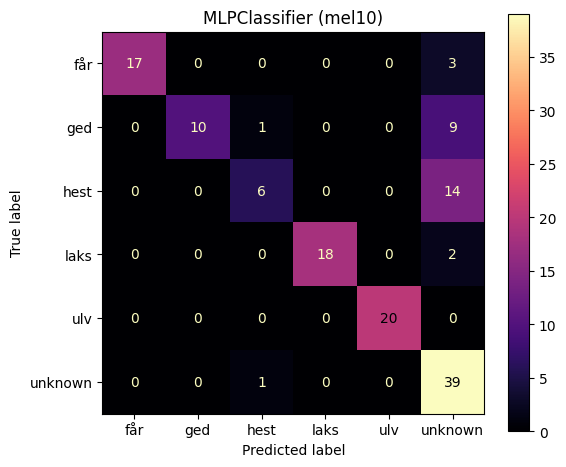


Model: LinearSVC
Feature set: simple_mel10
Family: linear
EMLearn compatible: False
Number of features: 19
Accuracy: 0.6571
Macro F1: 0.5942
Weighted F1: 0.5978
              precision    recall  f1-score   support

         får       0.00      0.00      0.00        20
         ged       1.00      0.65      0.79        20
        hest       0.95      0.90      0.92        20
        laks       1.00      0.95      0.97        20
         ulv       1.00      0.15      0.26        20
     unknown       0.45      0.97      0.62        40

    accuracy                           0.66       140
   macro avg       0.73      0.60      0.59       140
weighted avg       0.69      0.66      0.60       140



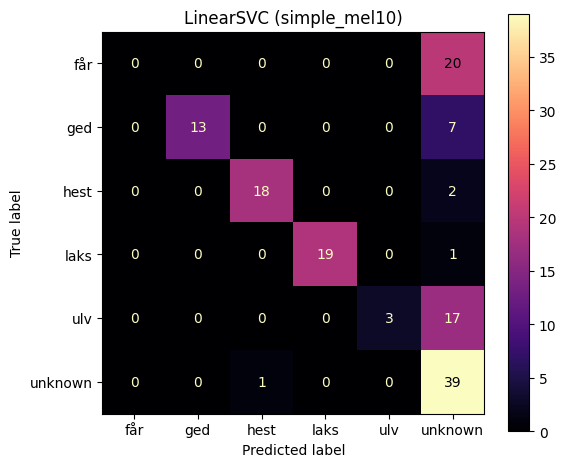


Model: SVC
Feature set: simple_mel10
Family: kernel
EMLearn compatible: False
Number of features: 19
Accuracy: 0.7500
Macro F1: 0.7325
Weighted F1: 0.7265
              precision    recall  f1-score   support

         får       1.00      0.30      0.46        20
         ged       1.00      0.25      0.40        20
        hest       0.95      0.95      0.95        20
        laks       1.00      0.95      0.97        20
         ulv       1.00      0.85      0.92        20
     unknown       0.53      0.97      0.69        40

    accuracy                           0.75       140
   macro avg       0.91      0.71      0.73       140
weighted avg       0.86      0.75      0.73       140



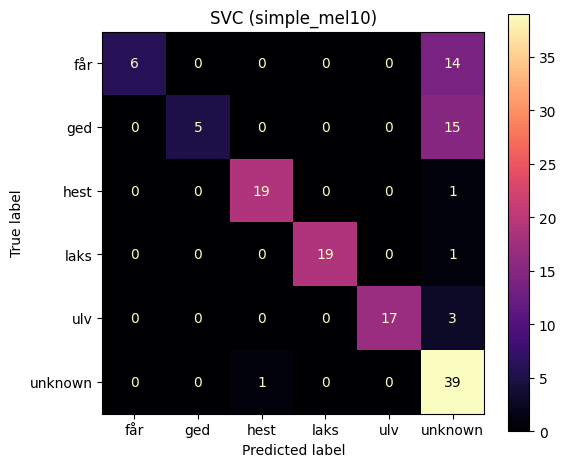


Model: KNeighbors
Feature set: simple_mel10
Family: neighbors
EMLearn compatible: True
Number of features: 19
Accuracy: 0.8357
Macro F1: 0.8381
Weighted F1: 0.8315
              precision    recall  f1-score   support

         får       1.00      0.50      0.67        20
         ged       0.84      0.80      0.82        20
        hest       0.95      1.00      0.98        20
        laks       1.00      0.95      0.97        20
         ulv       0.93      0.70      0.80        20
     unknown       0.68      0.95      0.79        40

    accuracy                           0.84       140
   macro avg       0.90      0.82      0.84       140
weighted avg       0.87      0.84      0.83       140



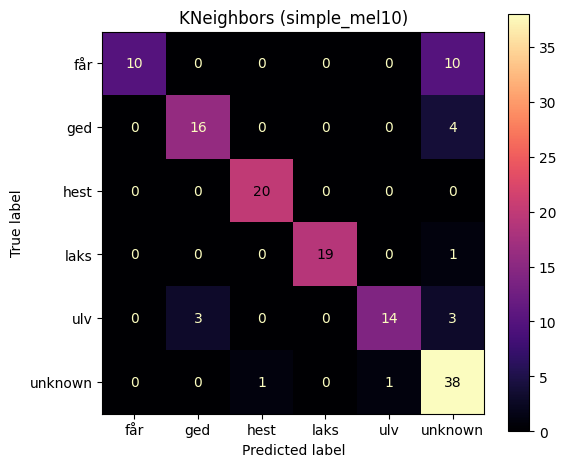


Model: DecisionTree
Feature set: simple_mel10
Family: tree
EMLearn compatible: True
Number of features: 19
Accuracy: 0.5143
Macro F1: 0.4291
Weighted F1: 0.4455
              precision    recall  f1-score   support

         får       1.00      0.80      0.89        20
         ged       0.00      0.00      0.00        20
        hest       0.75      0.15      0.25        20
        laks       1.00      0.55      0.71        20
         ulv       1.00      0.10      0.18        20
     unknown       0.37      1.00      0.54        40

    accuracy                           0.51       140
   macro avg       0.69      0.43      0.43       140
weighted avg       0.64      0.51      0.45       140



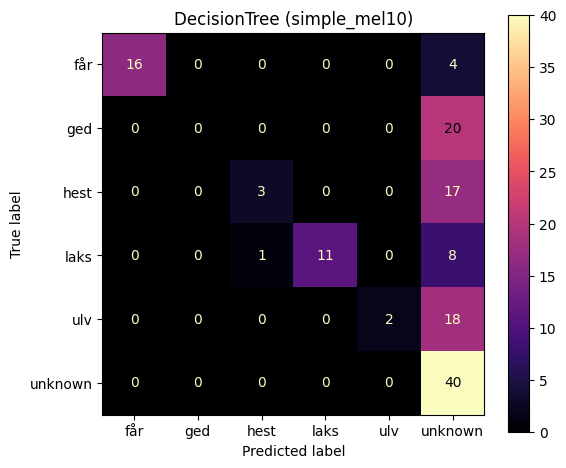


Model: RandomForest
Feature set: simple_mel10
Family: ensemble
EMLearn compatible: True
Number of features: 19
Accuracy: 0.7000
Macro F1: 0.7050
Weighted F1: 0.6979
              precision    recall  f1-score   support

         får       1.00      0.55      0.71        20
         ged       1.00      0.60      0.75        20
        hest       1.00      0.25      0.40        20
        laks       1.00      0.75      0.86        20
         ulv       1.00      0.75      0.86        20
     unknown       0.49      1.00      0.66        40

    accuracy                           0.70       140
   macro avg       0.91      0.65      0.70       140
weighted avg       0.85      0.70      0.70       140



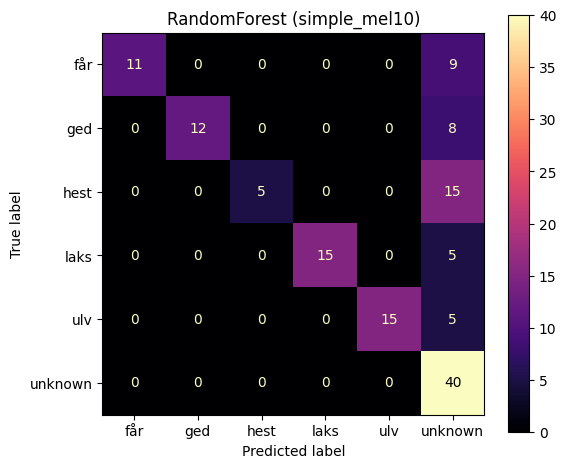


Model: ExtraTrees
Feature set: simple_mel10
Family: ensemble
EMLearn compatible: True
Number of features: 19
Accuracy: 0.5429
Macro F1: 0.4296
Weighted F1: 0.4476
              precision    recall  f1-score   support

         får       1.00      0.05      0.10        20
         ged       0.00      0.00      0.00        20
        hest       1.00      0.75      0.86        20
        laks       1.00      0.95      0.97        20
         ulv       1.00      0.05      0.10        20
     unknown       0.38      1.00      0.56        40

    accuracy                           0.54       140
   macro avg       0.73      0.47      0.43       140
weighted avg       0.68      0.54      0.45       140



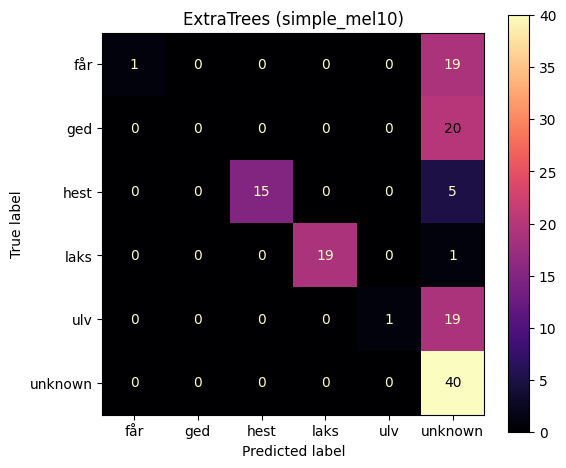


Model: MLPClassifier
Feature set: simple_mel10
Family: neural_network
EMLearn compatible: True
Number of features: 19
Accuracy: 0.7143
Macro F1: 0.6437
Weighted F1: 0.6462
              precision    recall  f1-score   support

         får       1.00      0.10      0.18        20
         ged       1.00      0.05      0.10        20
        hest       0.95      0.95      0.95        20
        laks       1.00      0.95      0.97        20
         ulv       1.00      1.00      1.00        20
     unknown       0.50      0.97      0.66        40

    accuracy                           0.71       140
   macro avg       0.91      0.67      0.64       140
weighted avg       0.85      0.71      0.65       140



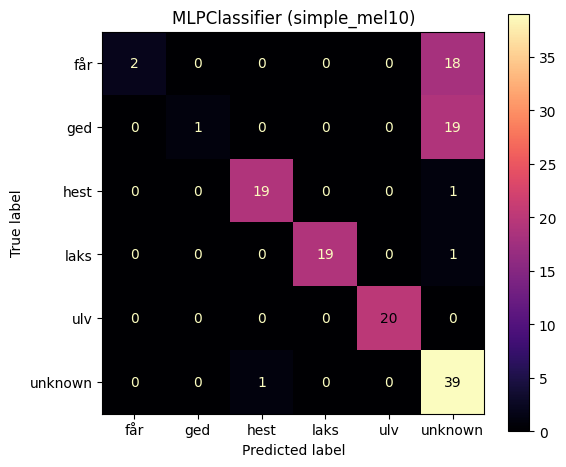


Summary sorted by accuracy:
            model          family      features  n_features  accuracy  \
7       LinearSVC          linear         mel10          10  0.871429   
16     KNeighbors       neighbors  simple_mel10          19  0.835714   
8             SVC          kernel         mel10          10  0.814286   
11   RandomForest        ensemble         mel10          10  0.800000   
9      KNeighbors       neighbors         mel10          10  0.800000   
13  MLPClassifier  neural_network         mel10          10  0.785714   
15            SVC          kernel  simple_mel10          19  0.750000   
20  MLPClassifier  neural_network  simple_mel10          19  0.714286   
18   RandomForest        ensemble  simple_mel10          19  0.700000   
14      LinearSVC          linear  simple_mel10          19  0.657143   
10   DecisionTree            tree         mel10          10  0.635714   
1             SVC          kernel        simple           9  0.607143   
2      KNeighbors     

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import soundfile as sf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    accuracy_score,
    classification_report,
    f1_score,
)

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier


# =========================
# SETTINGS
# =========================
TRAIN_KEYWORDS_DIR = Path("prepared_words")
TRAIN_UNKNOWN_DIR = Path("unknown_balanced")
TEST_DIR = Path("test_ready_chjem2")   # change to "test_ready" if needed

KEYWORD_LABELS = ["får", "ged", "hest", "laks", "ulv"]
ALL_LABELS = KEYWORD_LABELS + ["unknown"]

SAMPLE_RATE = 16000

FFT_N = 4096
FFT_HOP = FFT_N // 2
N_MELS = 10
EPS = 1e-12

SAVE_RESULTS_CSV = True
RESULTS_CSV = Path("model_feature_results_multiwindow_mel10.csv")


# =========================
# AUDIO HELPERS
# =========================
def load_wav(path: Path) -> np.ndarray:
    x, fs = sf.read(str(path), always_2d=False)
    x = np.asarray(x, dtype=np.float32)

    if x.ndim > 1:
        x = x.mean(axis=1)

    if fs != SAMPLE_RATE:
        raise ValueError(f"Unexpected sample rate in {path}: {fs}")

    peak = np.max(np.abs(x)) + 1e-9
    x = x / peak

    return x


def rms_energy(x: np.ndarray) -> float:
    return float(np.sqrt(np.mean(x ** 2) + 1e-12))


def zero_crossing_rate(x: np.ndarray) -> float:
    return float(np.mean(np.signbit(x[1:]) != np.signbit(x[:-1])))


# =========================
# EMLearn-like Mel helpers
# =========================
def hz_to_mel(hz: float) -> float:
    return 2595.0 * np.log10(1.0 + hz / 700.0)


def mel_to_hz(mels: float) -> float:
    return 700.0 * (10.0 ** (mels / 2595.0) - 1.0)


def eml_audio_mel_center(n: int, n_mels: int, fmin: float, fmax: float) -> float:
    melmin = hz_to_mel(fmin)
    melmax = hz_to_mel(fmax)
    melstep = (melmax - melmin) / (n_mels + 1)
    mel = melmin + n * melstep
    return mel_to_hz(mel)


def eml_audio_mel_bin(hz: float, n_fft: int, samplerate: float) -> int:
    return int(np.floor((n_fft + 1) * hz / samplerate))


def eml_fft_freq(k: int, n_fft: int, samplerate: float) -> float:
    end = samplerate / 2.0
    steps = (1 + n_fft // 2) - 1
    return (k * end) / steps


# =========================
# MULTI-WINDOW FFT
# =========================
def iter_fft_frames(x: np.ndarray, fft_n: int = FFT_N, hop: int = FFT_HOP):
    """
    Generate multiple Hann-windowed FFT frames over the full clip.
    The final window is forced to include the end of the signal.
    """

    if len(x) <= fft_n:
        starts = [0]
    else:
        starts = list(range(0, len(x) - fft_n + 1, hop))
        last_start = len(x) - fft_n

        if starts[-1] != last_start:
            starts.append(last_start)

    window = np.hanning(fft_n).astype(np.float32)

    for start in starts:
        frame = np.zeros(fft_n, dtype=np.float32)

        end = min(start + fft_n, len(x))
        frame[:end - start] = x[start:end]

        frame *= window

        yield frame


def magnitude_spectrum_frame(frame: np.ndarray, fs: float):
    spec = np.fft.rfft(frame)
    mag = np.abs(spec).astype(np.float32)

    freqs = np.fft.rfftfreq(
        FFT_N,
        d=1 / fs
    ).astype(np.float32)

    return freqs, mag


# =========================
# SIMPLE MULTI-WINDOW FEATURES
# =========================
def spectral_features_one_frame(frame: np.ndarray, fs: float) -> np.ndarray:
    freqs, mag = magnitude_spectrum_frame(frame, fs)
    power = mag ** 2

    centroid = float(
        np.sum(freqs * mag) /
        (np.sum(mag) + EPS)
    )

    cumsum = np.cumsum(mag)
    threshold = 0.85 * cumsum[-1]
    idx = np.searchsorted(cumsum, threshold)

    rolloff = float(freqs[min(idx, len(freqs) - 1)])

    dominant = float(
        freqs[np.argmax(mag[1:]) + 1]
    ) if len(mag) > 1 else 0.0

    band0_500 = float(np.sum(power[(freqs >= 0) & (freqs < 500)]))
    band500_1500 = float(np.sum(power[(freqs >= 500) & (freqs < 1500)]))
    band1500_3000 = float(np.sum(power[(freqs >= 1500) & (freqs < 3000)]))
    band3000_6000 = float(np.sum(power[(freqs >= 3000) & (freqs < 6000)]))

    return np.array([
        centroid,
        rolloff,
        dominant,
        band0_500,
        band500_1500,
        band1500_3000,
        band3000_6000,
    ], dtype=np.float32)


def spectral_features_multiwindow(x: np.ndarray, fs: float) -> np.ndarray:
    vals = []

    for frame in iter_fft_frames(x, fft_n=FFT_N, hop=FFT_HOP):
        vals.append(spectral_features_one_frame(frame, fs))

    vals = np.asarray(vals, dtype=np.float32)

    return np.mean(vals, axis=0)


# =========================
# MEL10 MULTI-WINDOW FEATURES
# =========================
def mel_spectrum_one_frame_emlearn_style(
    frame: np.ndarray,
    fs: float,
    n_mels: int = N_MELS,
) -> np.ndarray:
    """
    Mel calculation written to be close to emlearn C/C++:
    FFT -> real-part power -> triangular Mel filters.
    """

    spec = np.fft.rfft(frame)
    real_part = np.real(spec).astype(np.float32)
    power = (np.abs(real_part) ** 2) / float(FFT_N)

    fmin = 0.0
    fmax = fs / 2.0
    max_bin = 1 + FFT_N // 2

    mels = np.zeros(n_mels, dtype=np.float32)

    for m in range(1, n_mels + 1):
        left_hz = eml_audio_mel_center(m - 1, n_mels, fmin, fmax)
        center_hz = eml_audio_mel_center(m, n_mels, fmin, fmax)
        right_hz = eml_audio_mel_center(m + 1, n_mels, fmin, fmax)

        left = eml_audio_mel_bin(left_hz, FFT_N, fs)
        center = eml_audio_mel_bin(center_hz, FFT_N, fs)
        right = eml_audio_mel_bin(right_hz, FFT_N, fs)

        left = max(0, min(left, max_bin - 1))
        center = max(0, min(center, max_bin - 1))
        right = max(0, min(right, max_bin - 1))

        fdifflow = center_hz - left_hz
        fdiffupper = right_hz - center_hz

        val = 0.0

        for k in range(left, center + 1):
            r = left_hz - eml_fft_freq(k, FFT_N, fs)
            weight = max(
                min(-r / fdifflow if fdifflow != 0 else 0.0, 1.0),
                0.0
            )
            val += power[k] * weight

        for k in range(center, right):
            if k + 1 >= len(power):
                break

            r = right_hz - eml_fft_freq(k + 1, FFT_N, fs)
            weight = max(
                min(r / fdiffupper if fdiffupper != 0 else 0.0, 1.0),
                0.0
            )
            val += power[k + 1] * weight

        mels[m - 1] = val

    return mels


def mel_spectrum_multiwindow(x: np.ndarray, fs: float) -> np.ndarray:
    vals = []

    for frame in iter_fft_frames(x, fft_n=FFT_N, hop=FFT_HOP):
        vals.append(
            mel_spectrum_one_frame_emlearn_style(
                frame,
                fs,
                n_mels=N_MELS
            )
        )

    vals = np.asarray(vals, dtype=np.float32)

    return np.mean(vals, axis=0)


# =========================
# FEATURE EXTRACTION
# =========================
def extract_features(x: np.ndarray, fs: float) -> dict:
    spectral = spectral_features_multiwindow(x, fs)
    mel_vals = mel_spectrum_multiwindow(x, fs)

    record = {
        "rms": rms_energy(x),
        "zcr": zero_crossing_rate(x),
        "centroid": float(spectral[0]),
        "rolloff": float(spectral[1]),
        "dominant_freq": float(spectral[2]),
        "band_0_500": float(spectral[3]),
        "band_500_1500": float(spectral[4]),
        "band_1500_3000": float(spectral[5]),
        "band_3000_6000": float(spectral[6]),
    }

    for i, val in enumerate(mel_vals, start=1):
        record[f"mel_{i}"] = float(val)

    return record


# =========================
# BUILD DATAFRAMES
# =========================
def build_dataframe():
    train_records = []

    for label in KEYWORD_LABELS:
        for wav_path in sorted((TRAIN_KEYWORDS_DIR / label).glob("*.wav")):
            x = load_wav(wav_path)
            record = extract_features(x, SAMPLE_RATE)
            record["activity"] = label
            record["filename"] = wav_path.name
            train_records.append(record)

    for wav_path in sorted(TRAIN_UNKNOWN_DIR.glob("*.wav")):
        x = load_wav(wav_path)
        record = extract_features(x, SAMPLE_RATE)
        record["activity"] = "unknown"
        record["filename"] = wav_path.name
        train_records.append(record)

    test_records = []

    for label in ALL_LABELS:
        for wav_path in sorted((TEST_DIR / label).glob("*.wav")):
            x = load_wav(wav_path)
            record = extract_features(x, SAMPLE_RATE)
            record["activity"] = label
            record["filename"] = wav_path.name
            test_records.append(record)

    return pd.DataFrame(train_records), pd.DataFrame(test_records)


# =========================
# FEATURE SETS
# =========================
simple_features = [
    "rms",
    "zcr",
    "centroid",
    "rolloff",
    "dominant_freq",
    "band_0_500",
    "band_500_1500",
    "band_1500_3000",
    "band_3000_6000",
]

mel_feature_cols = [
    f"mel_{i}" for i in range(1, N_MELS + 1)
]

feature_sets = {
    "simple": simple_features,
    "mel10": mel_feature_cols,
    "simple_mel10": simple_features + mel_feature_cols,
}


# =========================
# MODEL CANDIDATES
# =========================
models = {
    "LinearSVC": {
        "model": make_pipeline(
            StandardScaler(),
            LinearSVC(max_iter=10000)
        ),
        "emlearn_compatible": False,
        "family": "linear",
    },

    "SVC": {
        "model": make_pipeline(
            StandardScaler(),
            SVC(kernel="rbf", C=1.0, gamma="scale")
        ),
        "emlearn_compatible": False,
        "family": "kernel",
    },

    "KNeighbors": {
        "model": make_pipeline(
            StandardScaler(),
            KNeighborsClassifier(n_neighbors=5)
        ),
        "emlearn_compatible": True,
        "family": "neighbors",
    },

    "DecisionTree": {
        "model": DecisionTreeClassifier(
            max_depth=8,
            min_samples_leaf=5,
            random_state=42
        ),
        "emlearn_compatible": True,
        "family": "tree",
    },

    "RandomForest": {
        "model": RandomForestClassifier(
            n_estimators=20,
            max_depth=6,
            min_samples_leaf=5,
            random_state=42
        ),
        "emlearn_compatible": True,
        "family": "ensemble",
    },

    "ExtraTrees": {
        "model": ExtraTreesClassifier(
            n_estimators=20,
            max_depth=6,
            min_samples_leaf=5,
            random_state=42
        ),
        "emlearn_compatible": True,
        "family": "ensemble",
    },

    "MLPClassifier": {
        "model": make_pipeline(
            StandardScaler(),
            MLPClassifier(
                hidden_layer_sizes=(16,),
                activation="relu",
                max_iter=2000,
                random_state=42
            )
        ),
        "emlearn_compatible": True,
        "family": "neural_network",
    },
}


# =========================
# TRAIN / EVALUATE
# =========================
def train_and_evaluate(train_df: pd.DataFrame, test_df: pd.DataFrame):
    results = []

    for feat_name, feat_cols in feature_sets.items():
        X_train = train_df[feat_cols]
        y_train = train_df["activity"]

        X_test = test_df[feat_cols]
        y_test = test_df["activity"]

        for model_name, info in models.items():
            model = info["model"]

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            acc = accuracy_score(y_test, y_pred)
            macro_f1 = f1_score(
                y_test,
                y_pred,
                labels=ALL_LABELS,
                average="macro",
                zero_division=0
            )
            weighted_f1 = f1_score(
                y_test,
                y_pred,
                labels=ALL_LABELS,
                average="weighted",
                zero_division=0
            )

            results.append({
                "model": model_name,
                "family": info["family"],
                "features": feat_name,
                "n_features": len(feat_cols),
                "accuracy": acc,
                "macro_f1": macro_f1,
                "weighted_f1": weighted_f1,
                "emlearn_compatible": info["emlearn_compatible"],
            })

            print("\n" + "=" * 60)
            print(f"Model: {model_name}")
            print(f"Feature set: {feat_name}")
            print(f"Family: {info['family']}")
            print(f"EMLearn compatible: {info['emlearn_compatible']}")
            print(f"Number of features: {len(feat_cols)}")
            print(f"Accuracy: {acc:.4f}")
            print(f"Macro F1: {macro_f1:.4f}")
            print(f"Weighted F1: {weighted_f1:.4f}")
            print(classification_report(
                y_test,
                y_pred,
                labels=ALL_LABELS,
                zero_division=0
            ))

            # Plot every confusion matrix, like your previous script
            cm = confusion_matrix(y_test, y_pred, labels=ALL_LABELS)

            disp = ConfusionMatrixDisplay(
                confusion_matrix=cm,
                display_labels=ALL_LABELS
            )

            fig, ax = plt.subplots(figsize=(6, 5))
            disp.plot(ax=ax, cmap="magma", values_format="d")
            plt.title(f"{model_name} ({feat_name})")
            plt.tight_layout()
            plt.show()

    results_df = pd.DataFrame(results)

    print("\nSummary sorted by accuracy:")
    print(results_df.sort_values("accuracy", ascending=False))

    print("\nSummary sorted by macro F1:")
    print(results_df.sort_values("macro_f1", ascending=False))

    print("\nBest EMLearn-compatible models:")
    print(
        results_df[results_df["emlearn_compatible"] == True]
        .sort_values("macro_f1", ascending=False)
    )

    return results_df


# =========================
# MAIN
# =========================
def main():
    train_df, test_df = build_dataframe()

    print("Train samples:", len(train_df))
    print("Test samples:", len(test_df))

    results_df = train_and_evaluate(train_df, test_df)

    if SAVE_RESULTS_CSV:
        results_df.to_csv(RESULTS_CSV, index=False)
        print(f"\nSaved results to: {RESULTS_CSV}")


if __name__ == "__main__":
    main()

Bagefter skal vi lave feature comparison. Vi laver nedenstående for at få en audiosample ud, for at se om vores features i Python og C++ matcher:

og nedenstående er python

In [20]:
from pathlib import Path
import json
import numpy as np
import soundfile as sf

# =========================
# SETTINGS
# =========================
INPUT_WAV = Path("test_ready_chjem2/får/test_får_C_0.75m_Chjem_002_s01.wav")

OUT_DIR = Path("feature_comparison_FFT4096_MultiWindow_Mel10")
OUT_HEADER = OUT_DIR / "audio_sample.h"
OUT_JSON = OUT_DIR / "audio_sample_ref.json"

SAMPLE_RATE = 16000
FFT_N = 4096
FFT_HOP = FFT_N // 2
N_MELS = 10

SELECTED_FEATURES = "mel"
ARRAY_NAME = "audio_sample"
EPS = 1e-12

# =========================
# AUDIO
# =========================
def load_wav(path: Path):
    x, fs = sf.read(str(path), always_2d=False)
    x = np.asarray(x, dtype=np.float32)

    if x.ndim > 1:
        x = x.mean(axis=1)

    if fs != SAMPLE_RATE:
        raise ValueError(f"Unexpected sample rate in {path}: {fs}")

    peak = np.max(np.abs(x)) + 1e-9
    return x / peak

# =========================
# WINDOWING
# =========================
def iter_fft_frames(x, fft_n=FFT_N, hop=FFT_HOP):
    if len(x) <= fft_n:
        starts = [0]
    else:
        starts = list(range(0, len(x) - fft_n + 1, hop))

        last_start = len(x) - fft_n
        if starts[-1] != last_start:
            starts.append(last_start)

    window = np.hanning(fft_n).astype(np.float32)

    for start in starts:
        frame = np.zeros(fft_n, dtype=np.float32)
        end = min(start + fft_n, len(x))
        frame[:end - start] = x[start:end]
        frame *= window
        yield frame

# =========================
# SIMPLE FEATURES
# =========================
def rms_energy(x):
    return float(np.sqrt(np.mean(x ** 2) + EPS))

def zero_crossing_rate(x):
    return float(np.mean(np.signbit(x[1:]) != np.signbit(x[:-1])))

def spectral_features_one_frame(frame, fs):
    spec = np.fft.rfft(frame)
    mag = np.abs(spec).astype(np.float32)
    freqs = np.fft.rfftfreq(FFT_N, d=1 / fs).astype(np.float32)

    power = mag ** 2

    centroid = float(np.sum(freqs * mag) / (np.sum(mag) + EPS))

    cumsum = np.cumsum(mag)
    threshold = 0.85 * cumsum[-1]
    idx = np.searchsorted(cumsum, threshold)
    rolloff = float(freqs[min(idx, len(freqs) - 1)])

    dominant = float(freqs[np.argmax(mag[1:]) + 1]) if len(mag) > 1 else 0.0

    band0_500 = float(np.sum(power[(freqs >= 0) & (freqs < 500)]))
    band500_1500 = float(np.sum(power[(freqs >= 500) & (freqs < 1500)]))
    band1500_3000 = float(np.sum(power[(freqs >= 1500) & (freqs < 3000)]))
    band3000_6000 = float(np.sum(power[(freqs >= 3000) & (freqs < 6000)]))

    return np.array([
        centroid,
        rolloff,
        dominant,
        band0_500,
        band500_1500,
        band1500_3000,
        band3000_6000,
    ], dtype=np.float32)

def spectral_features_multiwindow(x, fs):
    vals = []

    for frame in iter_fft_frames(x, fft_n=FFT_N, hop=FFT_HOP):
        vals.append(spectral_features_one_frame(frame, fs))

    vals = np.asarray(vals, dtype=np.float32)
    return np.mean(vals, axis=0)

# =========================
# MEL FEATURES, EMLearn style
# =========================
def hz_to_mel(hz):
    return 2595.0 * np.log10(1.0 + hz / 700.0)

def mel_to_hz(mels):
    return 700.0 * (10.0 ** (mels / 2595.0) - 1.0)

def eml_audio_mel_center(n, n_mels, fmin, fmax):
    melmin = hz_to_mel(fmin)
    melmax = hz_to_mel(fmax)
    melstep = (melmax - melmin) / (n_mels + 1)
    return mel_to_hz(melmin + n * melstep)

def eml_audio_mel_bin(hz, n_fft, samplerate):
    return int(np.floor((n_fft + 1) * (hz / samplerate)))

def eml_fft_freq(k, n_fft, samplerate):
    end = samplerate / 2.0
    steps = (1 + n_fft // 2) - 1
    return (k * end) / steps

def mel_spectrum_one_frame(frame, fs, n_mels=N_MELS):
    spec = np.fft.rfft(frame)

    # Matcher jeres EMLearn-style C/Python:
    # kun realdel, squared, divideret med FFT_N
    real_part = np.real(spec).astype(np.float32)
    power = (np.abs(real_part) ** 2) / float(FFT_N)

    fmin = 0.0
    fmax = fs / 2.0
    max_bin = 1 + FFT_N // 2

    mels = np.zeros(n_mels, dtype=np.float32)

    for m in range(1, n_mels + 1):
        left_hz = eml_audio_mel_center(m - 1, n_mels, fmin, fmax)
        center_hz = eml_audio_mel_center(m, n_mels, fmin, fmax)
        right_hz = eml_audio_mel_center(m + 1, n_mels, fmin, fmax)

        left = max(0, min(eml_audio_mel_bin(left_hz, FFT_N, fs), max_bin - 1))
        center = max(0, min(eml_audio_mel_bin(center_hz, FFT_N, fs), max_bin - 1))
        right = max(0, min(eml_audio_mel_bin(right_hz, FFT_N, fs), max_bin - 1))

        fdifflow = center_hz - left_hz
        fdiffupper = right_hz - center_hz

        val = 0.0

        for k in range(left, center + 1):
            r = left_hz - eml_fft_freq(k, FFT_N, fs)
            weight = max(min(-r / fdifflow if fdifflow != 0 else 0.0, 1.0), 0.0)
            val += power[k] * weight

        for k in range(center, right):
            if k + 1 >= len(power):
                break

            r = right_hz - eml_fft_freq(k + 1, FFT_N, fs)
            weight = max(min(r / fdiffupper if fdiffupper != 0 else 0.0, 1.0), 0.0)
            val += power[k + 1] * weight

        mels[m - 1] = val

    return mels

def mel_spectrum_multiwindow(x, fs, n_mels=N_MELS):
    vals = []

    for frame in iter_fft_frames(x, fft_n=FFT_N, hop=FFT_HOP):
        vals.append(mel_spectrum_one_frame(frame, fs, n_mels=n_mels))

    vals = np.asarray(vals, dtype=np.float32)
    return np.mean(vals, axis=0)

# =========================
# EXTRACT FEATURES
# =========================
def extract_features(x, fs):
    spectral = spectral_features_multiwindow(x, fs)
    mel_vals = mel_spectrum_multiwindow(x, fs, n_mels=N_MELS)

    record = {
        "rms": rms_energy(x),
        "zcr": zero_crossing_rate(x),
        "centroid": float(spectral[0]),
        "rolloff": float(spectral[1]),
        "dominant_freq": float(spectral[2]),
        "band_0_500": float(spectral[3]),
        "band_500_1500": float(spectral[4]),
        "band_1500_3000": float(spectral[5]),
        "band_3000_6000": float(spectral[6]),
    }

    for i, val in enumerate(mel_vals, start=1):
        record[f"mel_{i}"] = float(val)

    return record

# =========================
# FEATURE SETS
# =========================
mel_feature_cols = [f"mel_{i}" for i in range(1, N_MELS + 1)]

feature_sets = {
    "mel": mel_feature_cols,
}

# =========================
# EXPORT HELPERS
# =========================
def to_c_identifier(name: str) -> str:
    out = []
    for ch in name:
        out.append(ch if ch.isalnum() or ch == "_" else "_")

    s = "".join(out)

    if s and s[0].isdigit():
        s = "_" + s

    return s

def write_c_header_float_array(path: Path, array_name: str, x: np.ndarray):
    guard = to_c_identifier(path.stem.upper()) + "_H"

    with open(path, "w", encoding="utf-8") as f:
        f.write(f"#ifndef {guard}\n")
        f.write(f"#define {guard}\n\n")
        f.write("#include <stdint.h>\n\n")
        f.write(f"static const int32_t {array_name}_length = {len(x)};\n")
        f.write(f"static const float {array_name}[{len(x)}] = {{\n")

        for i, v in enumerate(x):
            sep = "," if i < len(x) - 1 else ""
            f.write(f"    {float(v):.8f}f{sep}\n")

        f.write("};\n\n")
        f.write(f"#endif // {guard}\n")

# =========================
# MAIN
# =========================
def main():
    if not INPUT_WAV.exists():
        raise FileNotFoundError(f"Could not find input wav: {INPUT_WAV}")

    OUT_DIR.mkdir(parents=True, exist_ok=True)

    x = load_wav(INPUT_WAV)
    feats = extract_features(x, SAMPLE_RATE)

    feat_cols = feature_sets[SELECTED_FEATURES]
    selected_feature_values = {
        k: float(feats[k])
        for k in feat_cols
    }

    write_c_header_float_array(OUT_HEADER, ARRAY_NAME, x)

    reference = {
        "input_wav": str(INPUT_WAV),
        "sample_rate": SAMPLE_RATE,
        "fft_n": FFT_N,
        "fft_hop": FFT_HOP,
        "n_mels": N_MELS,
        "selected_features_name": SELECTED_FEATURES,
        "selected_features_order": feat_cols,
        "selected_feature_values": selected_feature_values,
        "note": "simple_mel features: RMS/ZCR over full clip, spectral and Mel features averaged over multiple 4096-sample FFT windows with 50% overlap.",
    }

    with open(OUT_JSON, "w", encoding="utf-8") as f:
        json.dump(reference, f, indent=2, ensure_ascii=False)

    print(f"Wrote audio header to: {OUT_HEADER}")
    print(f"Wrote Python reference features to: {OUT_JSON}")

    print("\nSelected feature order:")
    for i, name in enumerate(feat_cols):
        print(f"{i:2d}: {name} = {selected_feature_values[name]:.8f}")

    print("\nAll mel features:")
    for i, name in enumerate(feature_sets["mel"]):
        print(f"{i:2d}: {name} = {feats[name]:.8f}")

if __name__ == "__main__":
    main()

Wrote audio header to: feature_comparison_FFT4096_MultiWindow_Mel10\audio_sample.h
Wrote Python reference features to: feature_comparison_FFT4096_MultiWindow_Mel10\audio_sample_ref.json

Selected feature order:
 0: mel_1 = 0.81972456
 1: mel_2 = 7.22568846
 2: mel_3 = 4.49630499
 3: mel_4 = 0.37287274
 4: mel_5 = 0.00544138
 5: mel_6 = 0.00178425
 6: mel_7 = 0.00756418
 7: mel_8 = 0.00829889
 8: mel_9 = 0.00088480
 9: mel_10 = 0.00144603

All mel features:
 0: mel_1 = 0.81972456
 1: mel_2 = 7.22568846
 2: mel_3 = 4.49630499
 3: mel_4 = 0.37287274
 4: mel_5 = 0.00544138
 5: mel_6 = 0.00178425
 6: mel_7 = 0.00756418
 7: mel_8 = 0.00829889
 8: mel_9 = 0.00088480
 9: mel_10 = 0.00144603


Det her er features.h

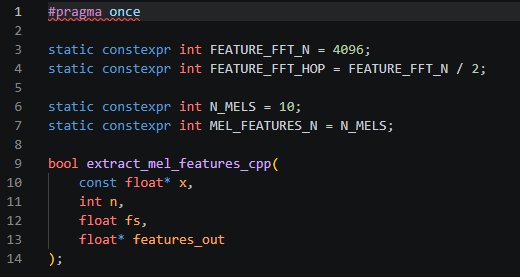

og features.cpp:

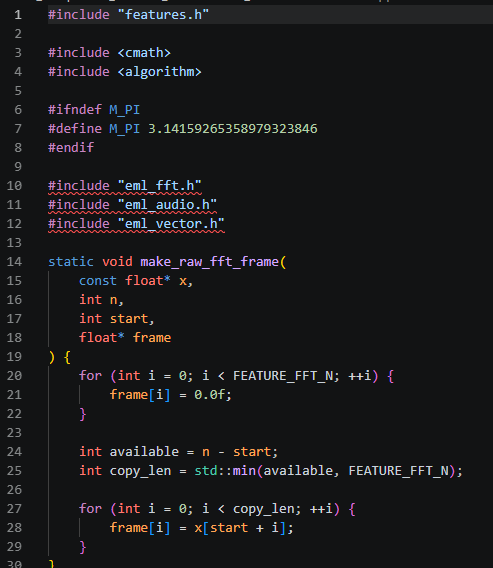

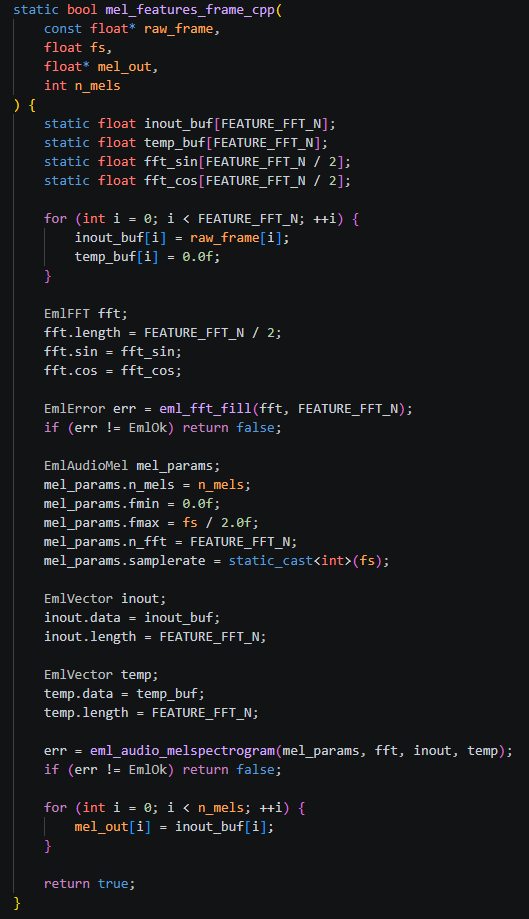

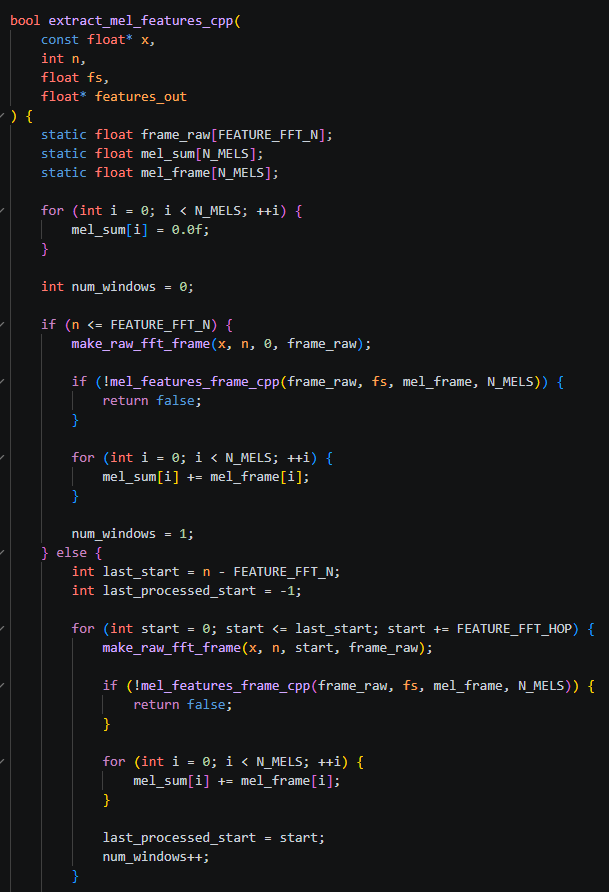

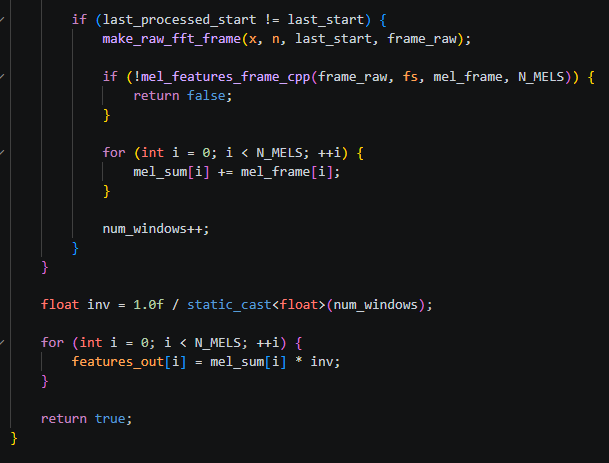

og dens tilsvarende main.cpp:

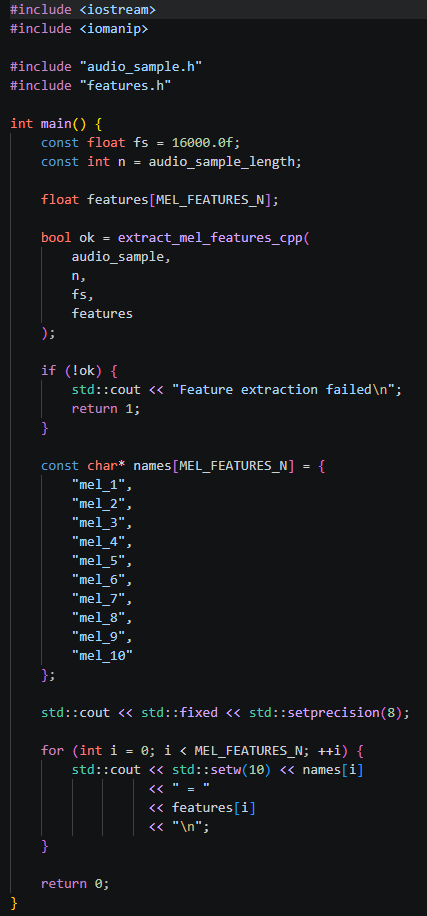

Hertil åbner vi Developer Command Prompt for VS og finder directoriet. Fordi jeg har installeret EMLearn og bruger EMLearn funktioner allerede nu, så skal jeg kører det her

cl /I "C:\Users\chris\anaconda3\envs\tinyml\Lib\site-packages\emlearn" main.cpp features.cpp

og bagefter:

main.exe

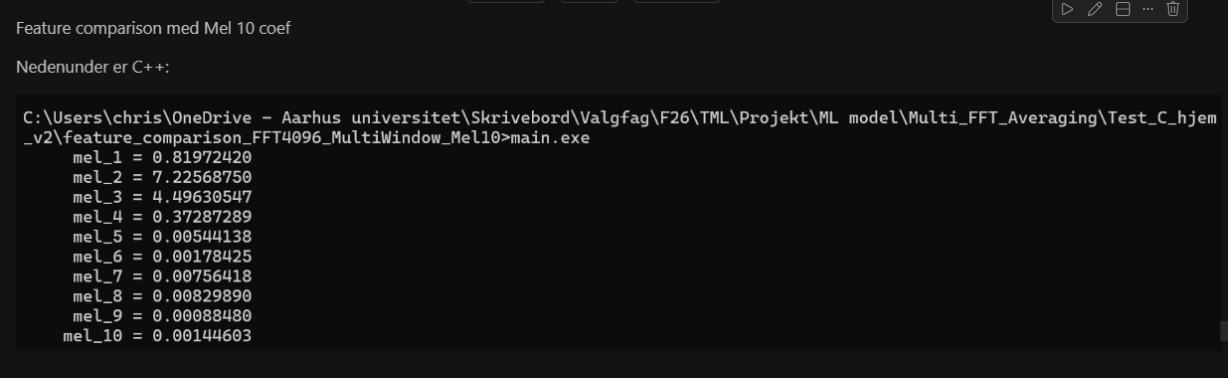

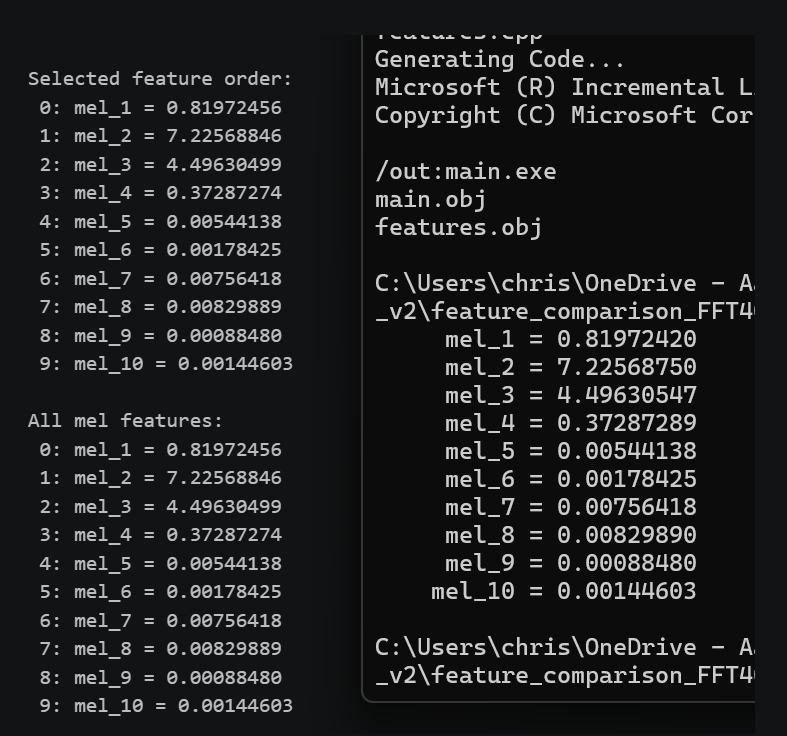

1.b)

In [21]:
from pathlib import Path
import numpy as np
import pandas as pd
import soundfile as sf
import emlearn

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================
# SETTINGS
# =========================
TRAIN_KEYWORDS_DIR = Path("prepared_words")
TRAIN_UNKNOWN_DIR = Path("unknown_balanced")
TEST_DIR = Path("test_ready_chjem2")

OUT_DIR = Path("1b")
OUT_MODEL_PATH = OUT_DIR / "keyword_model_rf_mel10_fft4096.h"

KEYWORD_LABELS = ["får", "ged", "hest", "laks", "ulv"]
ALL_LABELS = KEYWORD_LABELS + ["unknown"]

LABEL_TO_ID = {label: i for i, label in enumerate(ALL_LABELS)}
ID_TO_LABEL = {i: label for label, i in LABEL_TO_ID.items()}

SAMPLE_RATE = 16000
FFT_N = 4096
FFT_HOP = FFT_N // 2
N_MELS = 10

SELECTED_FEATURES = "mel"

# =========================
# AUDIO
# =========================
def load_wav(path: Path):
    x, fs = sf.read(str(path), always_2d=False)
    x = np.asarray(x, dtype=np.float32)

    if x.ndim > 1:
        x = x.mean(axis=1)

    if fs != SAMPLE_RATE:
        raise ValueError(f"Unexpected sample rate in {path}: {fs}")

    peak = np.max(np.abs(x)) + 1e-9
    return x / peak

# =========================
# WINDOWING
# =========================
def iter_fft_frames(x, fft_n=FFT_N, hop=FFT_HOP):
    if len(x) <= fft_n:
        starts = [0]
    else:
        starts = list(range(0, len(x) - fft_n + 1, hop))
        last_start = len(x) - fft_n

        if starts[-1] != last_start:
            starts.append(last_start)

    window = np.hanning(fft_n).astype(np.float32)

    for start in starts:
        frame = np.zeros(fft_n, dtype=np.float32)
        end = min(start + fft_n, len(x))
        frame[:end - start] = x[start:end]
        frame *= window
        yield frame

# =========================
# MEL FEATURES, EMLearn style
# =========================
def hz_to_mel(hz):
    return 2595.0 * np.log10(1.0 + hz / 700.0)

def mel_to_hz(mels):
    return 700.0 * (10.0 ** (mels / 2595.0) - 1.0)

def eml_audio_mel_center(n, n_mels, fmin, fmax):
    melmin = hz_to_mel(fmin)
    melmax = hz_to_mel(fmax)
    melstep = (melmax - melmin) / (n_mels + 1)
    return mel_to_hz(melmin + n * melstep)

def eml_audio_mel_bin(hz, n_fft, samplerate):
    return int(np.floor((n_fft + 1) * (hz / samplerate)))

def eml_fft_freq(k, n_fft, samplerate):
    end = samplerate / 2.0
    steps = (1 + n_fft // 2) - 1
    return (k * end) / steps

def mel_spectrum_one_frame(frame, fs, n_mels=N_MELS):
    spec = np.fft.rfft(frame)

    # Matcher EMLearn eml_audio_power_spectrogram:
    # kun realdelen, abs^2, divideret med FFT_N
    real_part = np.real(spec).astype(np.float32)
    power = (np.abs(real_part) ** 2) / float(FFT_N)

    fmin = 0.0
    fmax = fs / 2.0
    max_bin = 1 + FFT_N // 2

    mels = np.zeros(n_mels, dtype=np.float32)

    for m in range(1, n_mels + 1):
        left_hz = eml_audio_mel_center(m - 1, n_mels, fmin, fmax)
        center_hz = eml_audio_mel_center(m, n_mels, fmin, fmax)
        right_hz = eml_audio_mel_center(m + 1, n_mels, fmin, fmax)

        left = max(0, min(eml_audio_mel_bin(left_hz, FFT_N, fs), max_bin - 1))
        center = max(0, min(eml_audio_mel_bin(center_hz, FFT_N, fs), max_bin - 1))
        right = max(0, min(eml_audio_mel_bin(right_hz, FFT_N, fs), max_bin - 1))

        fdifflow = center_hz - left_hz
        fdiffupper = right_hz - center_hz

        val = 0.0

        for k in range(left, center + 1):
            r = left_hz - eml_fft_freq(k, FFT_N, fs)
            weight = max(min(-r / fdifflow if fdifflow != 0 else 0.0, 1.0), 0.0)
            val += power[k] * weight

        for k in range(center, right):
            if k + 1 >= len(power):
                break

            r = right_hz - eml_fft_freq(k + 1, FFT_N, fs)
            weight = max(min(r / fdiffupper if fdiffupper != 0 else 0.0, 1.0), 0.0)
            val += power[k + 1] * weight

        mels[m - 1] = val

    return mels

def mel_spectrum_multiwindow(x, fs, n_mels=N_MELS):
    vals = []

    for frame in iter_fft_frames(x, fft_n=FFT_N, hop=FFT_HOP):
        vals.append(mel_spectrum_one_frame(frame, fs, n_mels=n_mels))

    vals = np.asarray(vals, dtype=np.float32)
    return np.mean(vals, axis=0)

def extract_features(x, fs):
    mel_vals = mel_spectrum_multiwindow(x, fs, n_mels=N_MELS)

    record = {}
    for i, val in enumerate(mel_vals, start=1):
        record[f"mel_{i}"] = float(val)

    return record

# =========================
# BUILD DATAFRAMES
# =========================
train_records = []

for label in KEYWORD_LABELS:
    for wav_path in sorted((TRAIN_KEYWORDS_DIR / label).glob("*.wav")):
        x = load_wav(wav_path)
        record = extract_features(x, SAMPLE_RATE)
        record["activity"] = label
        record["filename"] = wav_path.name
        train_records.append(record)

for wav_path in sorted(TRAIN_UNKNOWN_DIR.glob("*.wav")):
    x = load_wav(wav_path)
    record = extract_features(x, SAMPLE_RATE)
    record["activity"] = "unknown"
    record["filename"] = wav_path.name
    train_records.append(record)

train_df = pd.DataFrame(train_records)

test_records = []

for label in ALL_LABELS:
    for wav_path in sorted((TEST_DIR / label).glob("*.wav")):
        x = load_wav(wav_path)
        record = extract_features(x, SAMPLE_RATE)
        record["activity"] = label
        record["filename"] = wav_path.name
        test_records.append(record)

test_df = pd.DataFrame(test_records)

# =========================
# FEATURE SETS
# =========================
mel_features = [f"mel_{i}" for i in range(1, N_MELS + 1)]

feature_sets = {
    "mel": mel_features,
}

feat_cols = feature_sets[SELECTED_FEATURES]

X_train = train_df[feat_cols].astype(np.float32)
y_train = train_df["activity"].map(LABEL_TO_ID).astype(np.int32)

X_test = test_df[feat_cols].astype(np.float32)
y_test = test_df["activity"].map(LABEL_TO_ID).astype(np.int32)

# =========================
# TRAIN DEPLOYABLE MODEL
# =========================
model = RandomForestClassifier(
    n_estimators=20,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print(f"Deployment model: RandomForest ({SELECTED_FEATURES}, N_MELS={N_MELS}, FFT_N={FFT_N}, HOP={FFT_HOP})")
print("Accuracy:", acc)

print(classification_report(
    y_test,
    y_pred,
    labels=list(ID_TO_LABEL.keys()),
    target_names=ALL_LABELS,
    zero_division=0
))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred, labels=list(ID_TO_LABEL.keys())))

# =========================
# OUTPUT
# =========================
OUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# CONVERT TO C WITH EMLEARN
# =========================
cmodel = emlearn.convert(model, method="inline", dtype="float")
cmodel.save(file=str(OUT_MODEL_PATH), name="keyword_model")

print(f"\nWrote model to: {OUT_MODEL_PATH}")
print(f"Number of features: {len(feat_cols)}")
print("Feature order:")
for i, f in enumerate(feat_cols):
    print(f"{i}: {f}")

Deployment model: RandomForest (mel, N_MELS=10, FFT_N=4096, HOP=2048)
Accuracy: 0.8
              precision    recall  f1-score   support

         får       1.00      0.65      0.79        20
         ged       1.00      0.25      0.40        20
        hest       1.00      0.95      0.97        20
        laks       1.00      1.00      1.00        20
         ulv       1.00      0.75      0.86        20
     unknown       0.59      1.00      0.74        40

    accuracy                           0.80       140
   macro avg       0.93      0.77      0.79       140
weighted avg       0.88      0.80      0.79       140

Confusion matrix:
[[13  0  0  0  0  7]
 [ 0  5  0  0  0 15]
 [ 0  0 19  0  0  1]
 [ 0  0  0 20  0  0]
 [ 0  0  0  0 15  5]
 [ 0  0  0  0  0 40]]

Wrote model to: 1b\keyword_model_rf_mel10_fft4096.h
Number of features: 10
Feature order:
0: mel_1
1: mel_2
2: mel_3
3: mel_4
4: mel_5
5: mel_6
6: mel_7
7: mel_8
8: mel_9
9: mel_10


Nedenstående laver testdataset og konverterer det til C++:

In [22]:
from pathlib import Path
import numpy as np
import soundfile as sf

# =========================
# SETTINGS
# =========================
TEST_DIR = Path("test_ready_chjem2")
OUT_HEADER = Path("1b/test_dataset.h")

KEYWORD_LABELS = ["får", "ged", "hest", "laks", "ulv"]
ALL_LABELS = KEYWORD_LABELS + ["unknown"]
LABEL_TO_ID = {label: i for i, label in enumerate(ALL_LABELS)}

SAMPLE_RATE = 16000

def load_wav(path: Path):
    x, fs = sf.read(str(path), always_2d=False)
    x = np.asarray(x, dtype=np.float32)

    if x.ndim > 1:
        x = x.mean(axis=1)

    if fs != SAMPLE_RATE:
        raise ValueError(f"Unexpected sample rate in {path}: {fs}")

    peak = np.max(np.abs(x)) + 1e-9
    x = x / peak
    return x

def to_c_identifier(name: str) -> str:
    out = []
    for ch in name:
        if ch.isalnum() or ch == "_":
            out.append(ch)
        else:
            out.append("_")
    s = "".join(out)
    if s and s[0].isdigit():
        s = "_" + s
    return s

def main():
    OUT_HEADER.parent.mkdir(parents=True, exist_ok=True)

    samples = []
    labels = []
    lengths = []
    names = []
    array_names = []

    idx = 0
    for label in ALL_LABELS:
        folder = TEST_DIR / label
        for wav_path in sorted(folder.glob("*.wav")):
            x = load_wav(wav_path)

            arr_name = f"test_audio_{idx}"
            samples.append(x)
            labels.append(LABEL_TO_ID[label])
            lengths.append(len(x))
            names.append(wav_path.name)
            array_names.append(arr_name)
            idx += 1

    guard = "TEST_DATASET_H"

    with open(OUT_HEADER, "w", encoding="utf-8") as f:
        f.write(f"#ifndef {guard}\n#define {guard}\n\n")
        f.write("#include <stdint.h>\n\n")

        f.write(f"static const int32_t test_num_samples = {len(samples)};\n\n")

        # Ét array per sample
        for i, x in enumerate(samples):
            arr_name = array_names[i]
            f.write(f"static const float {arr_name}[{len(x)}] = {{\n")
            for j, v in enumerate(x):
                sep = "," if j < len(x) - 1 else ""
                f.write(f"    {float(v):.8f}f{sep}\n")
            f.write("};\n\n")

        # Pointer-array til alle samples
        f.write(f"static const float* const test_audio_ptrs[{len(samples)}] = {{\n")
        for i, arr_name in enumerate(array_names):
            sep = "," if i < len(array_names) - 1 else ""
            f.write(f"    {arr_name}{sep}\n")
        f.write("};\n\n")

        # Længder
        f.write(f"static const int32_t test_lengths[{len(lengths)}] = {{\n")
        for i, v in enumerate(lengths):
            sep = "," if i < len(lengths) - 1 else ""
            f.write(f"    {v}{sep}\n")
        f.write("};\n\n")

        # Labels
        f.write(f"static const int32_t test_labels[{len(labels)}] = {{\n")
        for i, v in enumerate(labels):
            sep = "," if i < len(labels) - 1 else ""
            f.write(f"    {v}{sep}\n")
        f.write("};\n\n")

        # Filnavne som kommentarer
        for i, name in enumerate(names):
            f.write(f"// sample {i}: {name}\n")

        f.write("\n#endif\n")

    print(f"Wrote: {OUT_HEADER}")
    print(f"Exported {len(samples)} test samples as individual arrays")

if __name__ == "__main__":
    main()

Wrote: 1b\test_dataset.h
Exported 140 test samples as individual arrays


Hertil genbruger vi features.cpp og h filerne til at udføre 1b) 

Koden for main.cpp til 1b er vist nedenunder:

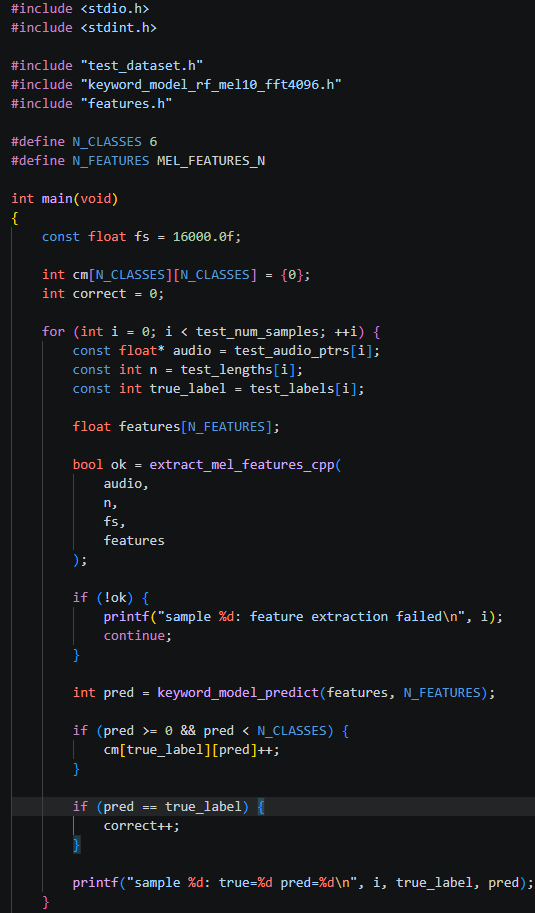

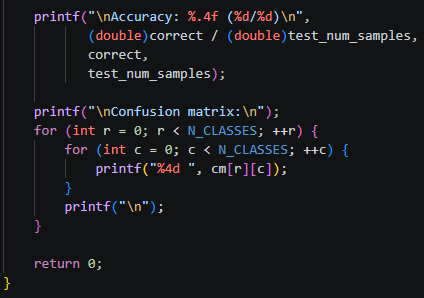

Hertil kører vi igen 

cl /I "C:\Users\chris\anaconda3\envs\tinyml\Lib\site-packages\emlearn" main.cpp features.cpp

og bagefter

main.exe

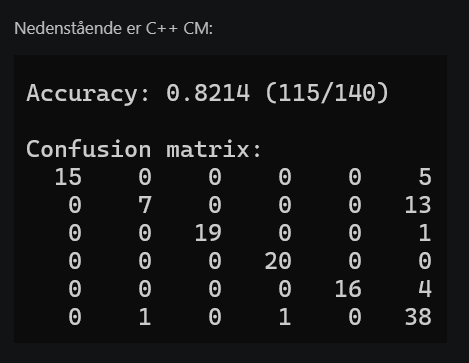

1c)

Først laver vi Particle projekt "1c", hvor vi husker at 

Konfigurerer projektet til 

- Photon2
- DeviceOS 5.6.0
- Device ID: Christian_Rex

Derefter indkluderer jeg følgende i "src":

- Allerede genereret h-fil for ML modellen, som lå i 1b mappen.
- Alt source kode fra EMLearn. Det finder jeg ved at søge "EMLearn" i søgefeltet og kopiere alt mappeindholdet til "src"

Derudover har features.h fået en opdatering, således:

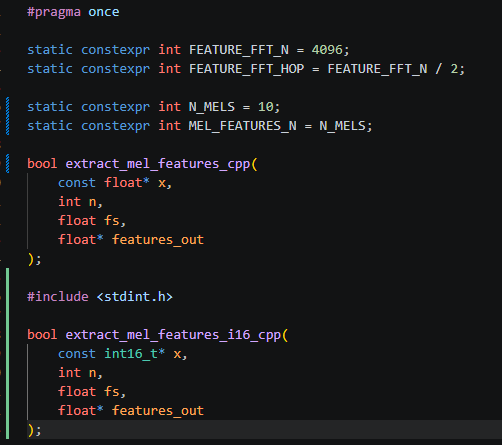

samt med features.cpp:

```cpp
#include "features.h"

#include <cmath>
#include <algorithm>

#ifndef M_PI
#define M_PI 3.14159265358979323846
#endif

#include "eml_fft.h"
#include "eml_audio.h"
#include "eml_vector.h"

static void make_raw_fft_frame(
    const float* x,
    int n,
    int start,
    float* frame
) {
    for (int i = 0; i < FEATURE_FFT_N; ++i) {
        frame[i] = 0.0f;
    }

    int available = n - start;
    int copy_len = std::min(available, FEATURE_FFT_N);

    for (int i = 0; i < copy_len; ++i) {
        frame[i] = x[start + i];
    }
}

static bool mel_features_frame_cpp(
    const float* raw_frame,
    float fs,
    float* mel_out,
    int n_mels
) {
    static float inout_buf[FEATURE_FFT_N];
    static float temp_buf[FEATURE_FFT_N];
    static float fft_sin[FEATURE_FFT_N / 2];
    static float fft_cos[FEATURE_FFT_N / 2];

    for (int i = 0; i < FEATURE_FFT_N; ++i) {
        inout_buf[i] = raw_frame[i];
        temp_buf[i] = 0.0f;
    }

    EmlFFT fft;
    fft.length = FEATURE_FFT_N / 2;
    fft.sin = fft_sin;
    fft.cos = fft_cos;

    EmlError err = eml_fft_fill(fft, FEATURE_FFT_N);
    if (err != EmlOk) return false;

    EmlAudioMel mel_params;
    mel_params.n_mels = n_mels;
    mel_params.fmin = 0.0f;
    mel_params.fmax = fs / 2.0f;
    mel_params.n_fft = FEATURE_FFT_N;
    mel_params.samplerate = static_cast<int>(fs);

    EmlVector inout;
    inout.data = inout_buf;
    inout.length = FEATURE_FFT_N;

    EmlVector temp;
    temp.data = temp_buf;
    temp.length = FEATURE_FFT_N;

    err = eml_audio_melspectrogram(mel_params, fft, inout, temp);
    if (err != EmlOk) return false;

    for (int i = 0; i < n_mels; ++i) {
        mel_out[i] = inout_buf[i];
    }

    return true;
}

bool extract_mel_features_cpp(
    const float* x,
    int n,
    float fs,
    float* features_out
) {
    static float frame_raw[FEATURE_FFT_N];
    static float mel_sum[N_MELS];
    static float mel_frame[N_MELS];

    for (int i = 0; i < N_MELS; ++i) {
        mel_sum[i] = 0.0f;
    }

    int num_windows = 0;

    if (n <= FEATURE_FFT_N) {
        make_raw_fft_frame(x, n, 0, frame_raw);

        if (!mel_features_frame_cpp(frame_raw, fs, mel_frame, N_MELS)) {
            return false;
        }

        for (int i = 0; i < N_MELS; ++i) {
            mel_sum[i] += mel_frame[i];
        }

        num_windows = 1;
    } else {
        int last_start = n - FEATURE_FFT_N;
        int last_processed_start = -1;

        for (int start = 0; start <= last_start; start += FEATURE_FFT_HOP) {
            make_raw_fft_frame(x, n, start, frame_raw);

            if (!mel_features_frame_cpp(frame_raw, fs, mel_frame, N_MELS)) {
                return false;
            }

            for (int i = 0; i < N_MELS; ++i) {
                mel_sum[i] += mel_frame[i];
            }

            last_processed_start = start;
            num_windows++;
        }

        if (last_processed_start != last_start) {
            make_raw_fft_frame(x, n, last_start, frame_raw);

            if (!mel_features_frame_cpp(frame_raw, fs, mel_frame, N_MELS)) {
                return false;
            }

            for (int i = 0; i < N_MELS; ++i) {
                mel_sum[i] += mel_frame[i];
            }

            num_windows++;
        }
    }

    float inv = 1.0f / static_cast<float>(num_windows);

    for (int i = 0; i < N_MELS; ++i) {
        features_out[i] = mel_sum[i] * inv;
    }

    return true;
}

/*
bool extract_mel_features_i16_cpp(
    const int16_t* x,
    int n,
    float fs,
    float* features_out
) {
    static float frame_raw[FEATURE_FFT_N];
    static float mel_sum[N_MELS];
    static float mel_frame[N_MELS];

    float max_abs = 1.0f;

    for (int i = 0; i < n; ++i) {
        float a = fabsf((float)x[i]);
        if (a > max_abs) {
            max_abs = a;
        }
    }

    for (int i = 0; i < N_MELS; ++i) {
        mel_sum[i] = 0.0f;
    }

    int num_windows = 0;

    auto process_window = [&](int start) -> bool {
        for (int i = 0; i < FEATURE_FFT_N; ++i) {
            frame_raw[i] = 0.0f;
        }

        int available = n - start;
        int copy_len = std::min(available, FEATURE_FFT_N);

        for (int i = 0; i < copy_len; ++i) {
            frame_raw[i] = ((float)x[start + i]) / max_abs;
        }

        if (!mel_features_frame_cpp(frame_raw, fs, mel_frame, N_MELS)) {
            return false;
        }

        for (int i = 0; i < N_MELS; ++i) {
            mel_sum[i] += mel_frame[i];
        }

        return true;
    };

    if (n <= FEATURE_FFT_N) {
        if (!process_window(0)) return false;
        num_windows = 1;
    } else {
        int last_start = n - FEATURE_FFT_N;
        int last_processed_start = -1;

        for (int start = 0; start <= last_start; start += FEATURE_FFT_HOP) {
            if (!process_window(start)) return false;
            last_processed_start = start;
            num_windows++;
        }

        if (last_processed_start != last_start) {
            if (!process_window(last_start)) return false;
            num_windows++;
        }
    }

    float inv = 1.0f / (float)num_windows;

    for (int i = 0; i < N_MELS; ++i) {
        features_out[i] = mel_sum[i] * inv;
    }

    return true;
}
*/
bool extract_mel_features_i16_cpp(
    const int16_t* x,
    int n,
    float fs,
    float* features_out
) {
    static float frame_raw[FEATURE_FFT_N];
    static float mel_sum[N_MELS];
    static float mel_frame[N_MELS];

    if (x == nullptr || features_out == nullptr) {
        return false;
    }

    if (n <= 0) {
        return false;
    }

    // Match Python peak normalization without allocating full float clip
    float max_abs = 1.0f;

    for (int i = 0; i < n; ++i) {
        float a = fabsf((float)x[i]);

        if (a > max_abs) {
            max_abs = a;
        }
    }

    const float inv_peak = 1.0f / max_abs;

    for (int i = 0; i < N_MELS; ++i) {
        mel_sum[i] = 0.0f;
    }

    int num_windows = 0;

    auto process_window = [&](int start) -> bool {
        for (int i = 0; i < FEATURE_FFT_N; ++i) {
            frame_raw[i] = 0.0f;
        }

        int available = n - start;
        int copy_len = std::min(available, FEATURE_FFT_N);

        for (int i = 0; i < copy_len; ++i) {
            frame_raw[i] = ((float)x[start + i]) * inv_peak;
        }

        if (!mel_features_frame_cpp(frame_raw, fs, mel_frame, N_MELS)) {
            return false;
        }

        for (int i = 0; i < N_MELS; ++i) {
            mel_sum[i] += mel_frame[i];
        }

        return true;
    };

    if (n <= FEATURE_FFT_N) {
        if (!process_window(0)) {
            return false;
        }

        num_windows = 1;
    } else {
        int last_start = n - FEATURE_FFT_N;
        int last_processed_start = -1;

        for (int start = 0; start <= last_start; start += FEATURE_FFT_HOP) {
            if (!process_window(start)) {
                return false;
            }

            last_processed_start = start;
            num_windows++;
        }

        if (last_processed_start != last_start) {
            if (!process_window(last_start)) {
                return false;
            }

            num_windows++;
        }
    }

    if (num_windows <= 0) {
        return false;
    }

    const float inv_windows = 1.0f / (float)num_windows;

    for (int i = 0; i < N_MELS; ++i) {
        features_out[i] = mel_sum[i] * inv_windows;
    }

    return true;
}

```

som også skal tilføjes til "src"

Bemærk at testsættet skulle være i mindre dele, 

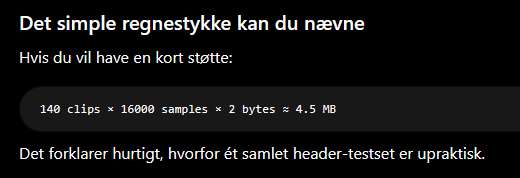

så vi gør således:

In [1]:
from pathlib import Path
import numpy as np
import soundfile as sf
import math

# =========================
# SETTINGS
# =========================
TEST_DIR = Path("test_ready_chjem2")

OUT_DIR = Path("1c") / "src"

NUM_PARTS = 12

KEYWORD_LABELS = ["får", "ged", "hest", "laks", "ulv"]
ALL_LABELS = KEYWORD_LABELS + ["unknown"]
LABEL_TO_ID = {label: i for i, label in enumerate(ALL_LABELS)}

SAMPLE_RATE = 16000

def load_wav(path: Path):
    x, fs = sf.read(str(path), always_2d=False)
    x = np.asarray(x, dtype=np.float32)

    if x.ndim > 1:
        x = x.mean(axis=1)

    if fs != SAMPLE_RATE:
        raise ValueError(f"Unexpected sample rate in {path}: {fs}")

    peak = np.max(np.abs(x)) + 1e-9
    x = x / peak
    return x

def write_header(out_header: Path, samples, labels, lengths, names, array_names):
    guard = out_header.stem.upper() + "_H"
    guard = guard.replace(".", "_").replace("-", "_")

    with open(out_header, "w", encoding="utf-8") as f:
        f.write(f"#ifndef {guard}\n#define {guard}\n\n")
        f.write("#include <stdint.h>\n\n")

        f.write(f"static const int32_t test_num_samples = {len(samples)};\n\n")

        # Ét int16_t array per sample
        for i, x in enumerate(samples):
            arr_name = array_names[i]

            x_i16 = np.clip(x * 32767.0, -32768, 32767).astype(np.int16)

            f.write(f'__attribute__((section(".rodata"), aligned(4))) static const int16_t {arr_name}[{len(x_i16)}] = {{\n')
            for j, v in enumerate(x_i16):
                sep = "," if j < len(x_i16) - 1 else ""
                f.write(f"    {int(v)}{sep}\n")
            f.write("};\n\n")

        # Pointer-array til alle samples
        f.write(f'__attribute__((section(".rodata"), aligned(4))) static const int16_t* const test_audio_ptrs[{len(samples)}] = {{\n')        
        for i, arr_name in enumerate(array_names):
            sep = "," if i < len(array_names) - 1 else ""
            f.write(f"    {arr_name}{sep}\n")
        f.write("};\n\n")

        # Længder
        f.write(f'__attribute__((section(".rodata"), aligned(4))) static const int32_t test_lengths[{len(lengths)}] = {{\n')
        for i, v in enumerate(lengths):
            sep = "," if i < len(lengths) - 1 else ""
            f.write(f"    {v}{sep}\n")
        f.write("};\n\n")

        # Labels
        f.write(f'__attribute__((section(".rodata"), aligned(4))) static const int32_t test_labels[{len(labels)}] = {{\n')
        for i, v in enumerate(labels):
            sep = "," if i < len(labels) - 1 else ""
            f.write(f"    {v}{sep}\n")
        f.write("};\n\n")

        for i, name in enumerate(names):
            f.write(f"// local sample {i}: {name}\n")

        f.write("\n#endif\n")

def main():
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    all_samples = []
    all_labels = []
    all_lengths = []
    all_names = []

    idx = 0
    for label in ALL_LABELS:
        folder = TEST_DIR / label
        for wav_path in sorted(folder.glob("*.wav")):
            x = load_wav(wav_path)

            all_samples.append(x)
            all_labels.append(LABEL_TO_ID[label])
            all_lengths.append(len(x))
            all_names.append(wav_path.name)
            idx += 1

    total = len(all_samples)
    if total == 0:
        raise RuntimeError("No test samples found.")

    chunk_size = math.ceil(total / NUM_PARTS)

    for part_idx in range(NUM_PARTS):
        start = part_idx * chunk_size
        end = min(start + chunk_size, total)

        part_samples = all_samples[start:end]
        part_labels = all_labels[start:end]
        part_lengths = all_lengths[start:end]
        part_names = all_names[start:end]

        if not part_samples:
            print(f"Skipping empty part {part_idx}")
            continue

        # lokale array-navne pr. fil
        part_array_names = [f"test_audio_{i}" for i in range(len(part_samples))]

        out_header = OUT_DIR / f"test_dataset_part{part_idx}.h"
        write_header(
            out_header,
            part_samples,
            part_labels,
            part_lengths,
            part_names,
            part_array_names
        )

        print(f"Wrote: {out_header} ({len(part_samples)} samples, global range {start}-{end-1})")

    print(f"Exported {total} test samples into {NUM_PARTS} header files")

if __name__ == "__main__":
    main()

Wrote: 1c\src\test_dataset_part0.h (12 samples, global range 0-11)
Wrote: 1c\src\test_dataset_part1.h (12 samples, global range 12-23)
Wrote: 1c\src\test_dataset_part2.h (12 samples, global range 24-35)
Wrote: 1c\src\test_dataset_part3.h (12 samples, global range 36-47)
Wrote: 1c\src\test_dataset_part4.h (12 samples, global range 48-59)
Wrote: 1c\src\test_dataset_part5.h (12 samples, global range 60-71)
Wrote: 1c\src\test_dataset_part6.h (12 samples, global range 72-83)
Wrote: 1c\src\test_dataset_part7.h (12 samples, global range 84-95)
Wrote: 1c\src\test_dataset_part8.h (12 samples, global range 96-107)
Wrote: 1c\src\test_dataset_part9.h (12 samples, global range 108-119)
Wrote: 1c\src\test_dataset_part10.h (12 samples, global range 120-131)
Wrote: 1c\src\test_dataset_part11.h (8 samples, global range 132-139)
Exported 140 test samples into 12 header files


Dertil Ctrl + P og vælger "Compile Application (local)" 

Efter fuldført compilation, så vælger jeg dernæst "Flash Application (local)"

Efter fuldført flashing, så vælger jeg "Serial Monitor". Det kan være man skal trykke RESET på selve MCU'en, for at se resultaterne, efter man har åbnet serial monitor. 

# test_dataset_part0

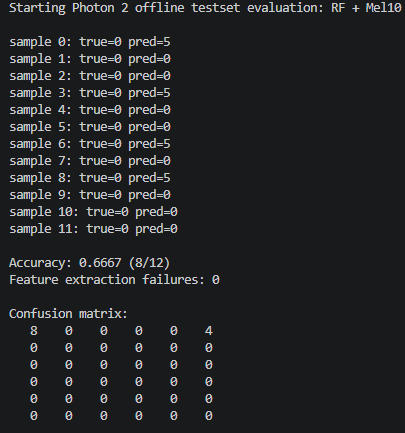

# test_dataset_part1

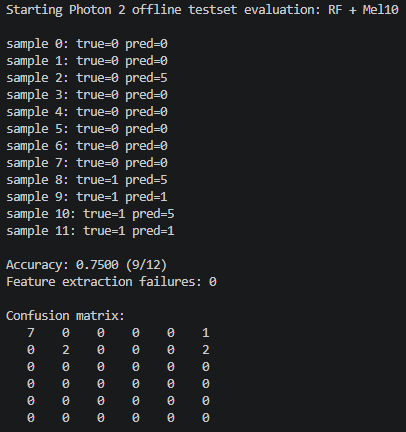

# test_dataset_part2

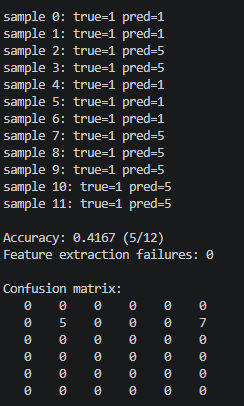

# test_dataset_part3

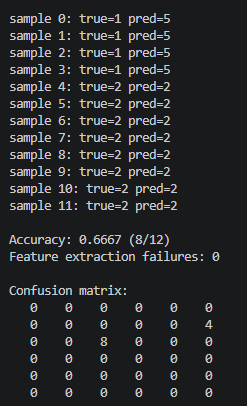

# test_dataset_part4

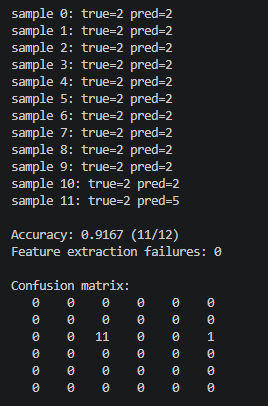

# test_dataset_part5

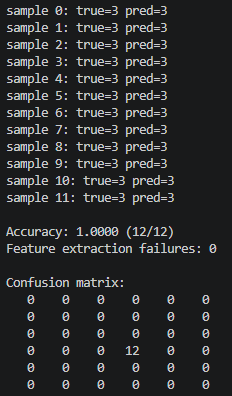

# test_dataset_part6

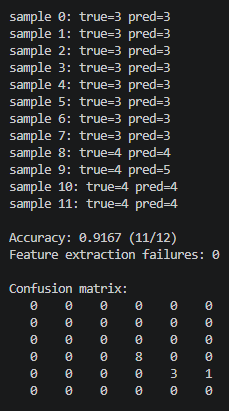

# test_dataset_part7

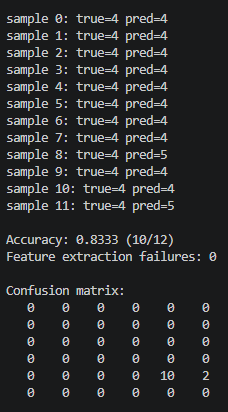

# test_dataset_part8

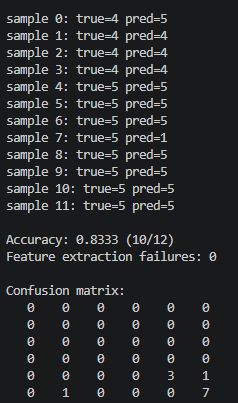

# test_dataset_part9

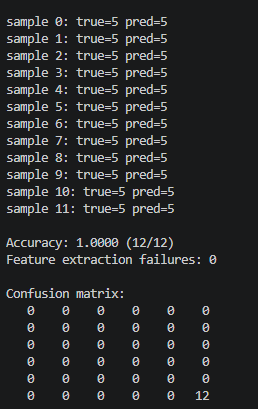

# test_dataset_part10

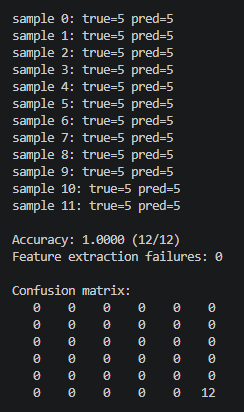

# test_dataset_part11

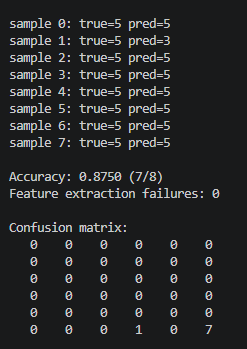


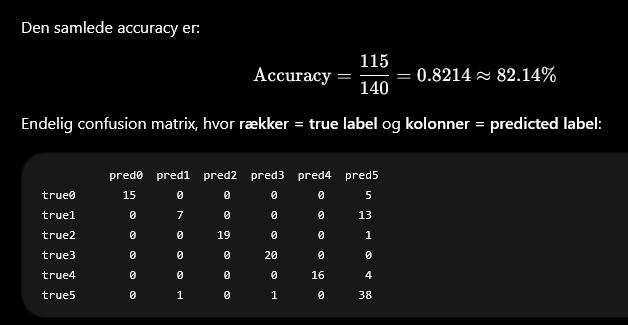

Ift. CM fra 1b)

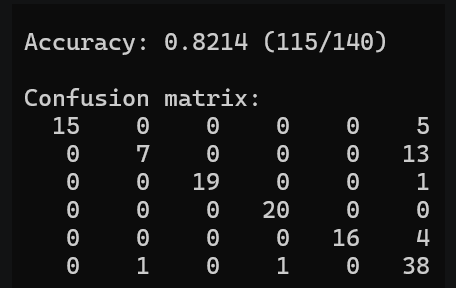

så er de fuldstændig ens.

2)

Dermed går vi videre med inferencing.

Opret Photon2 projekt igen "2"

Installér med "Install Library" med Ctrl + P og skriv "Microphone_PDM"

Igen skal du huske

- EMLearn source koden
- h-fil for ML modellen, brugt både i 1b og 1c
- h- og cpp-fil for features, som brugt i 1c

Husk også at konfigurerer til Photon2, DeviceOS 5.6.0 og Device ID: Christian_Rex

Compile og Flash programmet. Først den version, som faktisk laver live inferencing og spytter output probabilities ud for hver klasse

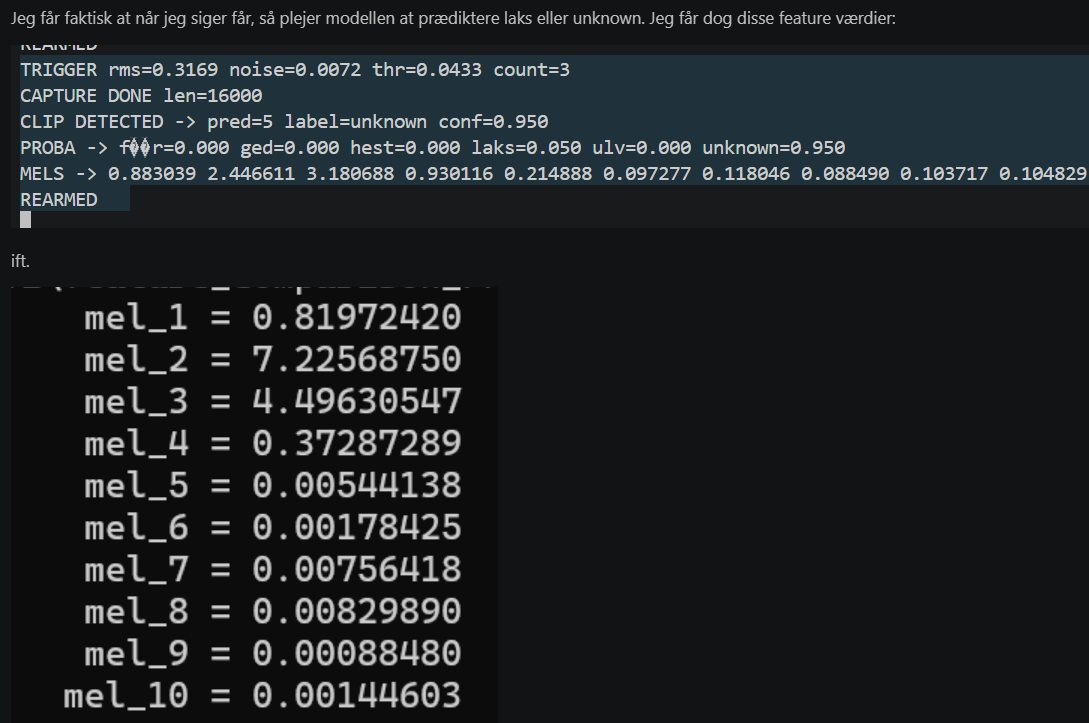

    sample     true_label pred_label  confidence
0        0            får    unknown        0.90
1        1            får    unknown        0.90
2        2            får    unknown        0.95
3        3            får    unknown        0.95
4        4            får    unknown        0.70
..     ...            ...        ...         ...
59      59  random_ridder       laks        0.65
60      60   random_pleje       laks        0.65
61      61   random_pleje       laks        0.60
62      62   random_pleje       laks        0.90
63      63   random_pleje       laks        0.80

[64 rows x 4 columns]

Counts:
pred_label     ged  hest  laks  unknown
true_label                             
får              0     0     0       11
ged              0     0     8        3
hest             0     4     3        5
laks             0     0    11        0
random_pleje     0     0     4        0
random_ridder    0     0     3        2
ulv              1     1     1        7


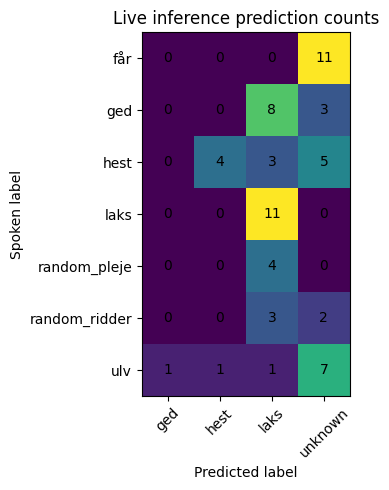

C:\Users\chris\AppData\Local\Temp\ipykernel_21124\1640573528.py:112: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


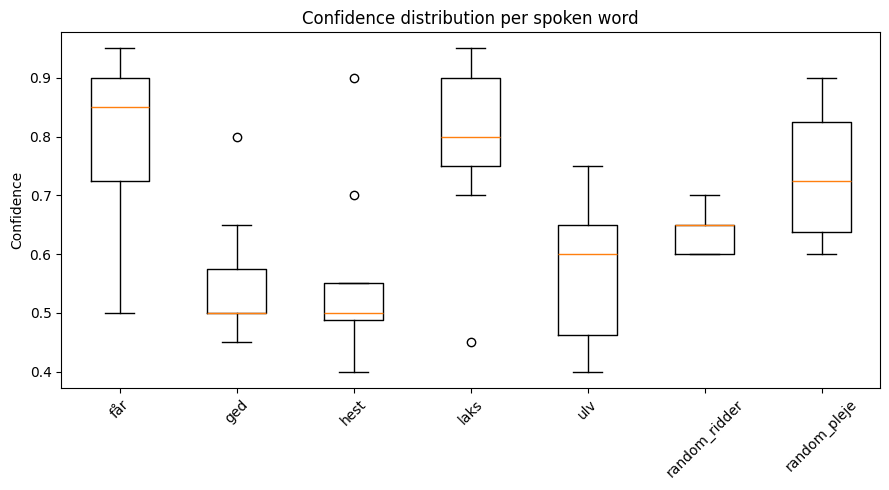

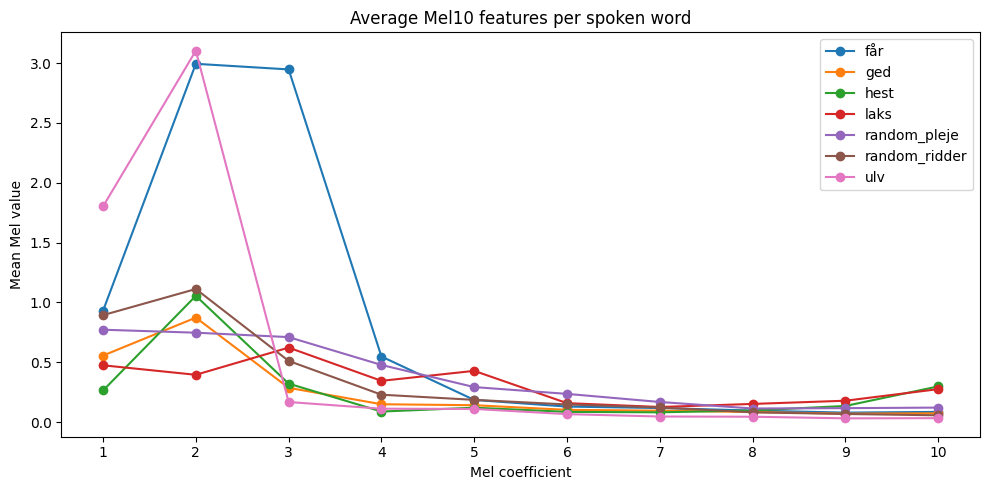

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

LOG_PATH = "live_mel10_log.txt"

CLASSES = ["får", "ged", "hest", "laks", "ulv", "unknown"]
MEL_NAMES = [f"mel_{i}" for i in range(1, 11)]

section_re = re.compile(r"^(Får|Ged|Hest|Laks|Ulv|Random ord).*:", re.IGNORECASE)
random_word_re = re.compile(r"^\((.*?)\)")
pred_re = re.compile(r"CLIP DETECTED -> pred=(\d+) label=([^\s]+) conf=([0-9.]+)")
mels_re = re.compile(r"MELS -> " + r"\s+".join([r"([0-9.]+)"] * 10))

def normalize_label(s):
    s = s.lower()
    if s.startswith("får"):
        return "får"
    if s.startswith("ged"):
        return "ged"
    if s.startswith("hest"):
        return "hest"
    if s.startswith("laks"):
        return "laks"
    if s.startswith("ulv"):
        return "ulv"
    if s.startswith("random"):
        return "random"
    return s

rows = []
current_true = None
pending = None

with open(LOG_PATH, "r", encoding="utf-8", errors="replace") as f:
    for line in f:
        line = line.strip()

        m_sec = section_re.match(line)
        if m_sec:
            current_true = normalize_label(m_sec.group(1))
            continue

        m_rand = random_word_re.match(line)
        if m_rand:
            current_true = "random_" + m_rand.group(1).lower()
            continue

        m_pred = pred_re.search(line)
        if m_pred:
            pred_id = int(m_pred.group(1))
            pred_label = m_pred.group(2)
            conf = float(m_pred.group(3))

            pending = {
                "true_label": current_true,
                "pred_id": pred_id,
                "pred_label": pred_label,
                "confidence": conf,
            }
            continue

        m_mels = mels_re.search(line)
        if m_mels and pending is not None:
            vals = list(map(float, m_mels.groups()))

            for name, val in zip(MEL_NAMES, vals):
                pending[name] = val

            rows.append(pending)
            pending = None

df = pd.DataFrame(rows)
df.insert(0, "sample", range(len(df)))

print(df[["sample", "true_label", "pred_label", "confidence"]])

print("\nCounts:")
print(pd.crosstab(df["true_label"], df["pred_label"]))

# =========================
# Plot 1: live confusion counts
# =========================
ct = pd.crosstab(df["true_label"], df["pred_label"])

plt.figure(figsize=(8, 5))
plt.imshow(ct.values)

plt.xticks(range(len(ct.columns)), ct.columns, rotation=45)
plt.yticks(range(len(ct.index)), ct.index)

plt.title("Live inference prediction counts")
plt.xlabel("Predicted label")
plt.ylabel("Spoken label")

for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        plt.text(j, i, ct.values[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

# =========================
# Plot 2: confidence per true label
# =========================
plt.figure(figsize=(9, 5))

labels = list(df["true_label"].unique())
data = [df[df["true_label"] == label]["confidence"] for label in labels]

plt.boxplot(data, labels=labels)
plt.xticks(rotation=45)
plt.ylabel("Confidence")
plt.title("Confidence distribution per spoken word")
plt.tight_layout()
plt.show()

# =========================
# Plot 3: average Mel10 curves
# =========================
mel_mean = df.groupby("true_label")[MEL_NAMES].mean()

plt.figure(figsize=(10, 5))

for label in mel_mean.index:
    plt.plot(range(1, 11), mel_mean.loc[label], marker="o", label=label)

plt.title("Average Mel10 features per spoken word")
plt.xlabel("Mel coefficient")
plt.ylabel("Mean Mel value")
plt.xticks(range(1, 11))
plt.legend()
plt.tight_layout()
plt.show()

Files used:
får -> test_får_C_0.75m_Chjem_002_s01.wav
får -> test_får_C_0.75m_Chjem_002_s02.wav
får -> test_får_C_0.75m_Chjem_002_s03.wav
ged -> test_ged_C_0.75m_Chjem_002_s01.wav
ged -> test_ged_C_0.75m_Chjem_002_s02.wav
ged -> test_ged_C_0.75m_Chjem_002_s03.wav
hest -> test_hest_C_0.75m_Chjem_002_s01.wav
hest -> test_hest_C_0.75m_Chjem_002_s02.wav
hest -> test_hest_C_0.75m_Chjem_002_s03.wav
laks -> test_laks_C_0.75m_Chjem_002_s01.wav
laks -> test_laks_C_0.75m_Chjem_002_s02.wav
laks -> test_laks_C_0.75m_Chjem_002_s03.wav
ulv -> test_ulv_C_0.75m_Chjem_002_s01.wav
ulv -> test_ulv_C_0.75m_Chjem_002_s02.wav
ulv -> test_ulv_C_0.75m_Chjem_002_s03.wav


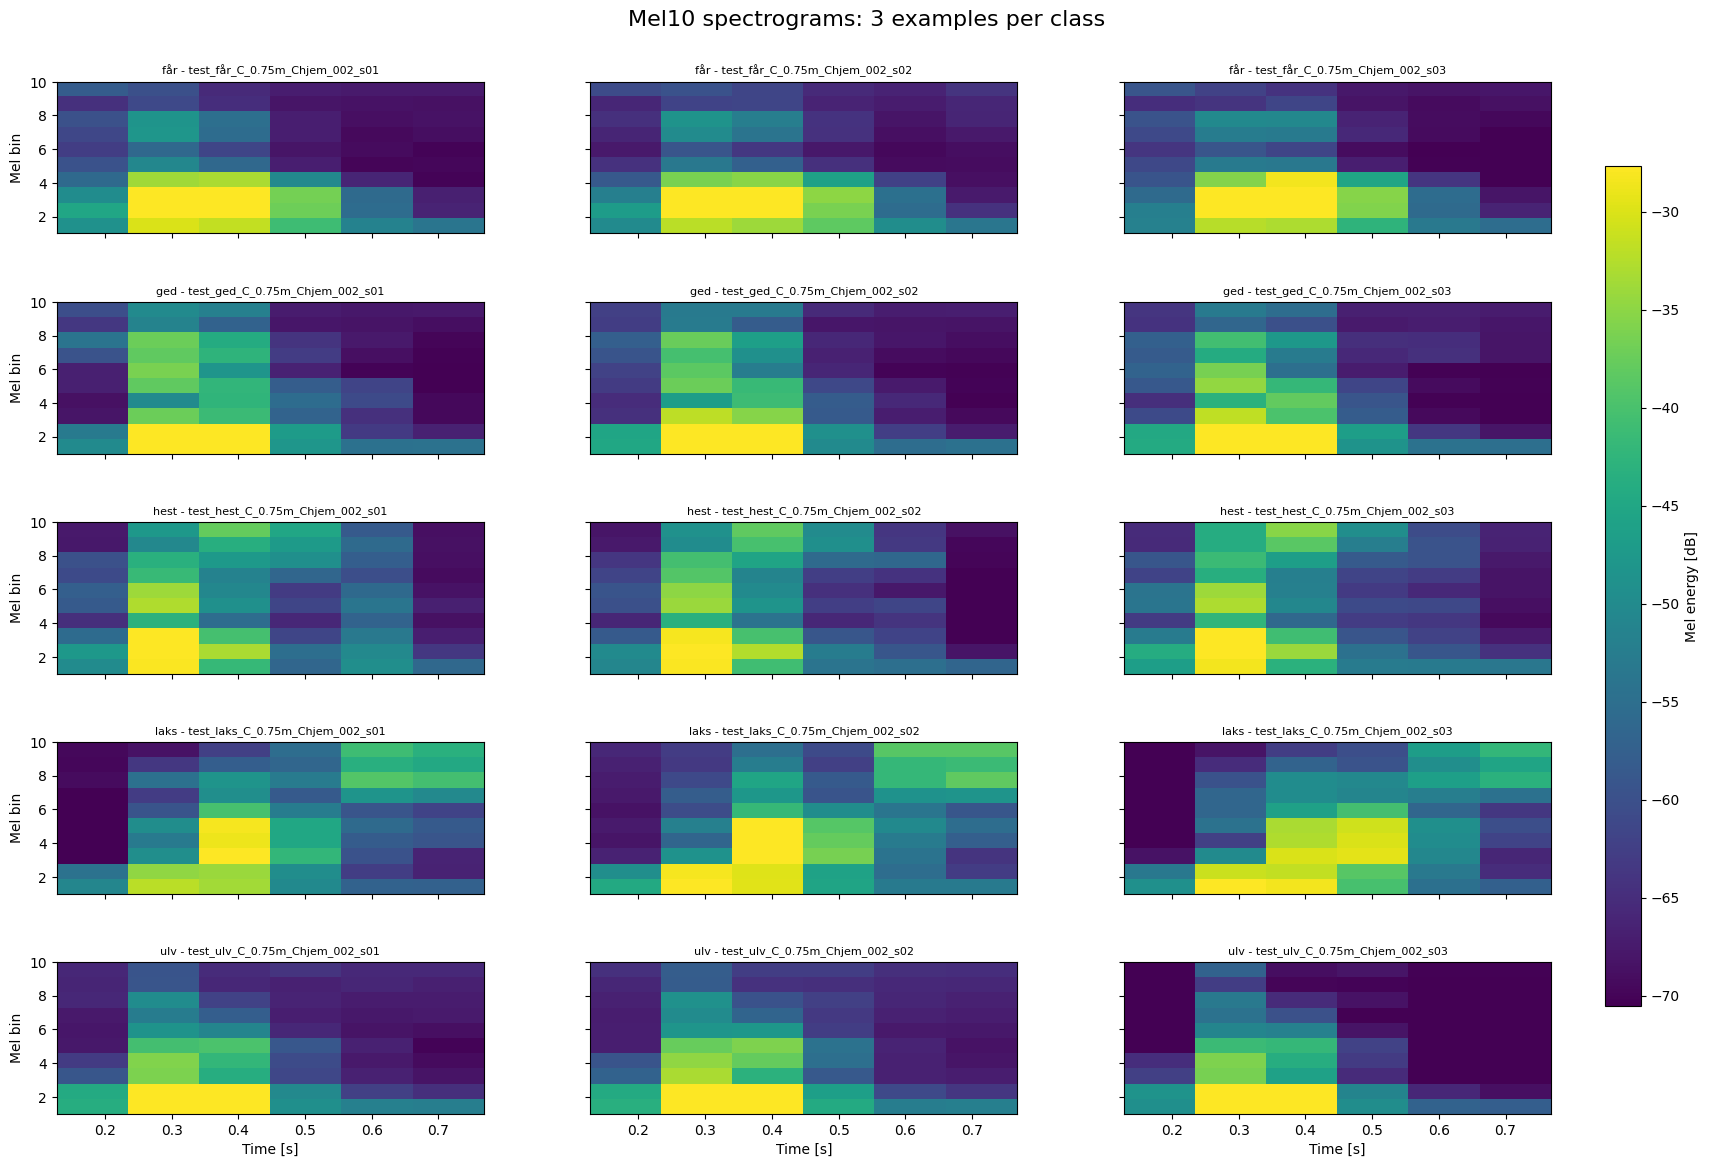

In [2]:
from pathlib import Path
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

SAMPLE_RATE = 16000
N_MELS = 10
NFFT = 4096
HOP = 2048

BASE_DIR = Path("test_ready_chjem2")

LABELS = ["får", "ged", "hest", "laks", "ulv"]
N_PER_CLASS = 3

def hz_to_mel(hz):
    return 2595.0 * np.log10(1.0 + hz / 700.0)

def mel_to_hz(mel):
    return 700.0 * (10.0 ** (mel / 2595.0) - 1.0)

def mel_filterbank(n_mels, n_fft, sr):
    mel_points = np.linspace(hz_to_mel(0), hz_to_mel(sr / 2), n_mels + 2)
    hz_points = mel_to_hz(mel_points)
    bins = np.floor((n_fft + 1) * hz_points / sr).astype(int)

    fb = np.zeros((n_mels, n_fft // 2 + 1))

    for m in range(1, n_mels + 1):
        left, center, right = bins[m - 1], bins[m], bins[m + 1]

        for k in range(left, center):
            fb[m - 1, k] = (k - left) / max(center - left, 1)

        for k in range(center, right):
            fb[m - 1, k] = (right - k) / max(right - center, 1)

    return fb

FB = mel_filterbank(N_MELS, NFFT, SAMPLE_RATE)

def load_audio(path):
    x, sr = sf.read(path, always_2d=False)
    x = np.asarray(x, dtype=np.float32)

    if x.ndim > 1:
        x = x.mean(axis=1)

    if sr != SAMPLE_RATE:
        raise ValueError(f"Wrong sample rate: {path}, got {sr}")

    peak = np.max(np.abs(x)) + 1e-9
    return x / peak

def mel_spectrogram(x):
    _, t, Sxx = spectrogram(
        x,
        fs=SAMPLE_RATE,
        window="hann",
        nperseg=NFFT,
        noverlap=NFFT - HOP,
        nfft=NFFT,
        mode="magnitude"
    )

    mel = FB @ (Sxx ** 2)
    mel_db = 10 * np.log10(mel + 1e-12)

    return t, mel_db

# =========================
# Find WAV files
# =========================
items = []

for label in LABELS:
    wavs = sorted((BASE_DIR / label).glob("*0.75m*.wav"))

    if len(wavs) < N_PER_CLASS:
        wavs = sorted((BASE_DIR / label).glob("*.wav"))

    for wav in wavs[:N_PER_CLASS]:
        items.append((label, wav))

print("Files used:")
for label, wav in items:
    print(label, "->", wav.name)

# =========================
# Precompute spectrograms
# =========================
mel_cache = []

for label, wav in items:
    x = load_audio(wav)
    t, mel_db = mel_spectrogram(x)
    mel_cache.append((label, wav, t, mel_db))

all_vals = np.concatenate([m.flatten() for _, _, _, m in mel_cache])
vmin = np.percentile(all_vals, 5)
vmax = np.percentile(all_vals, 95)

# =========================
# Plot
# =========================
fig, axes = plt.subplots(
    len(LABELS),
    N_PER_CLASS,
    figsize=(18, 12),
    sharex=True,
    sharey=True
)

for idx, (label, wav, t, mel_db) in enumerate(mel_cache):
    row = LABELS.index(label)
    col = idx % N_PER_CLASS

    ax = axes[row, col]

    im = ax.imshow(
        mel_db,
        aspect="auto",
        origin="lower",
        extent=[t[0], t[-1], 1, N_MELS],
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(f"{label} - {wav.stem}", fontsize=8)

    if col == 0:
        ax.set_ylabel("Mel bin")

    if row == len(LABELS) - 1:
        ax.set_xlabel("Time [s]")

# Gør plads til colorbar helt ude til højre
plt.subplots_adjust(
    left=0.05,
    right=0.88,
    top=0.92,
    bottom=0.06,
    wspace=0.25,
    hspace=0.45
)

cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.70])
fig.colorbar(im, cax=cbar_ax, label="Mel energy [dB]")

fig.suptitle("Mel10 spectrograms: 3 examples per class", fontsize=16)

plt.show()

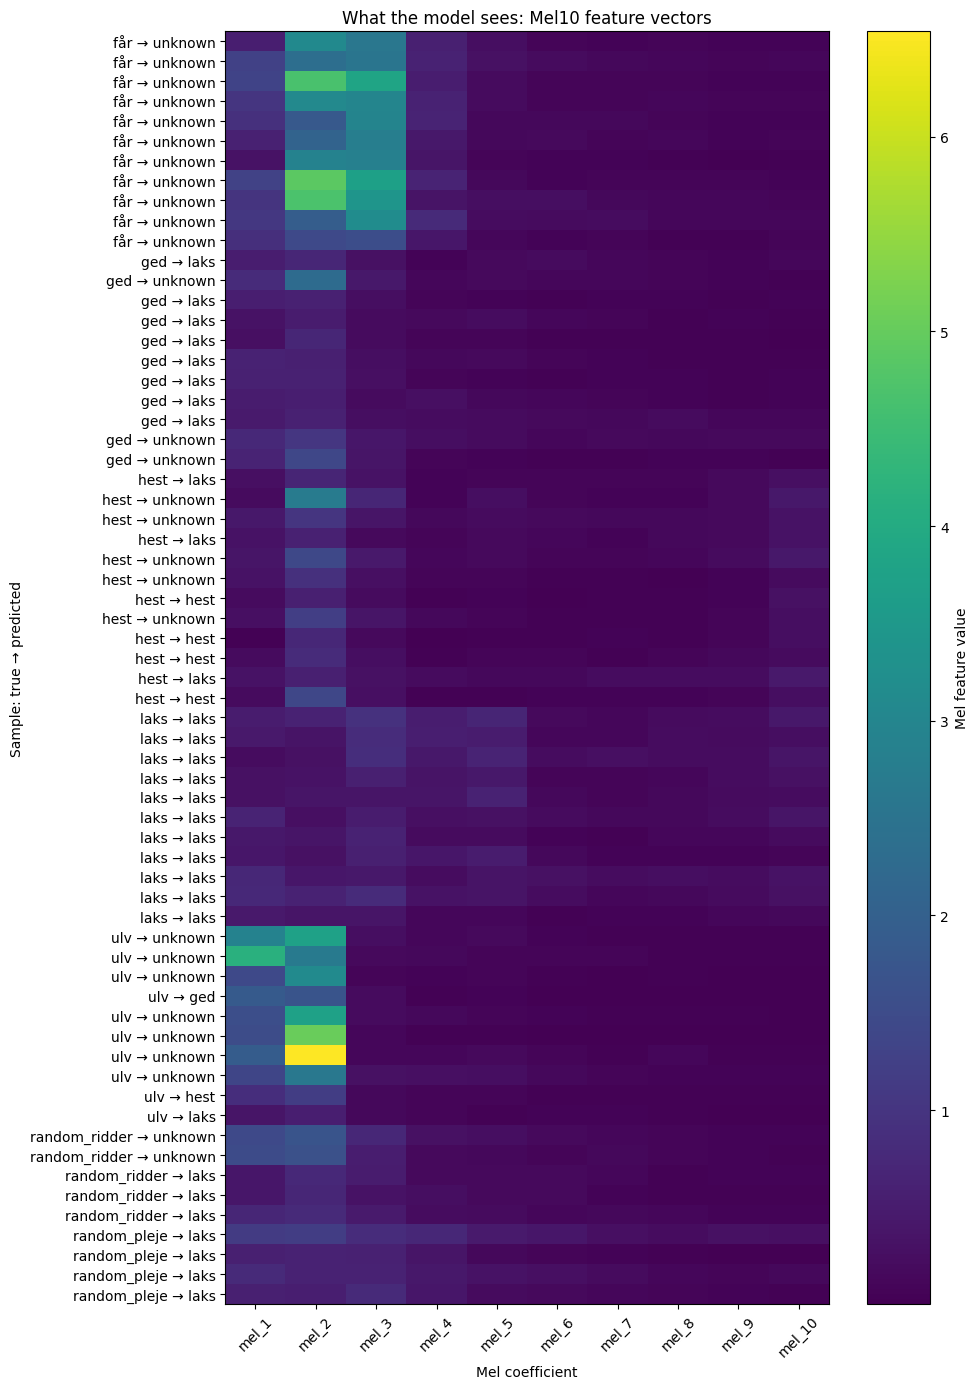

In [2]:
import matplotlib.pyplot as plt
import numpy as np

MEL_NAMES = [f"mel_{i}" for i in range(1, 11)]

plot_df = df.copy()
plot_df["row_label"] = (
    plot_df["true_label"].astype(str)
    + " → "
    + plot_df["pred_label"].astype(str)
)

X = plot_df[MEL_NAMES].to_numpy()

plt.figure(figsize=(10, 14))
plt.imshow(X, aspect="auto")

plt.xticks(range(len(MEL_NAMES)), MEL_NAMES, rotation=45)
plt.yticks(range(len(plot_df)), plot_df["row_label"])

plt.colorbar(label="Mel feature value")
plt.title("What the model sees: Mel10 feature vectors")
plt.xlabel("Mel coefficient")
plt.ylabel("Sample: true → predicted")

plt.tight_layout()
plt.show()

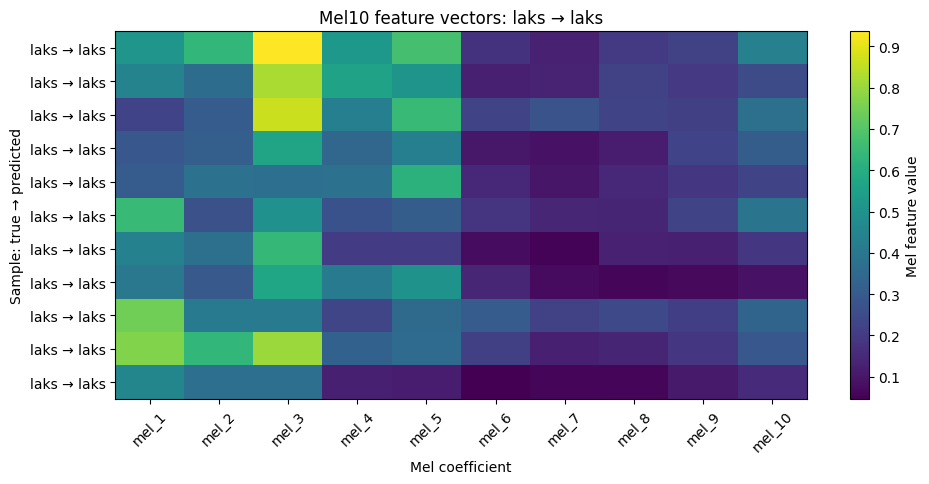

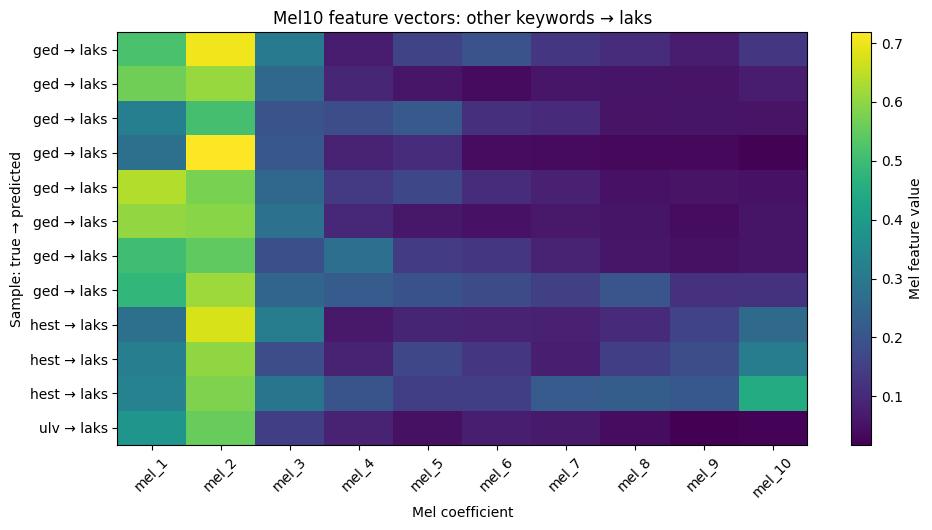

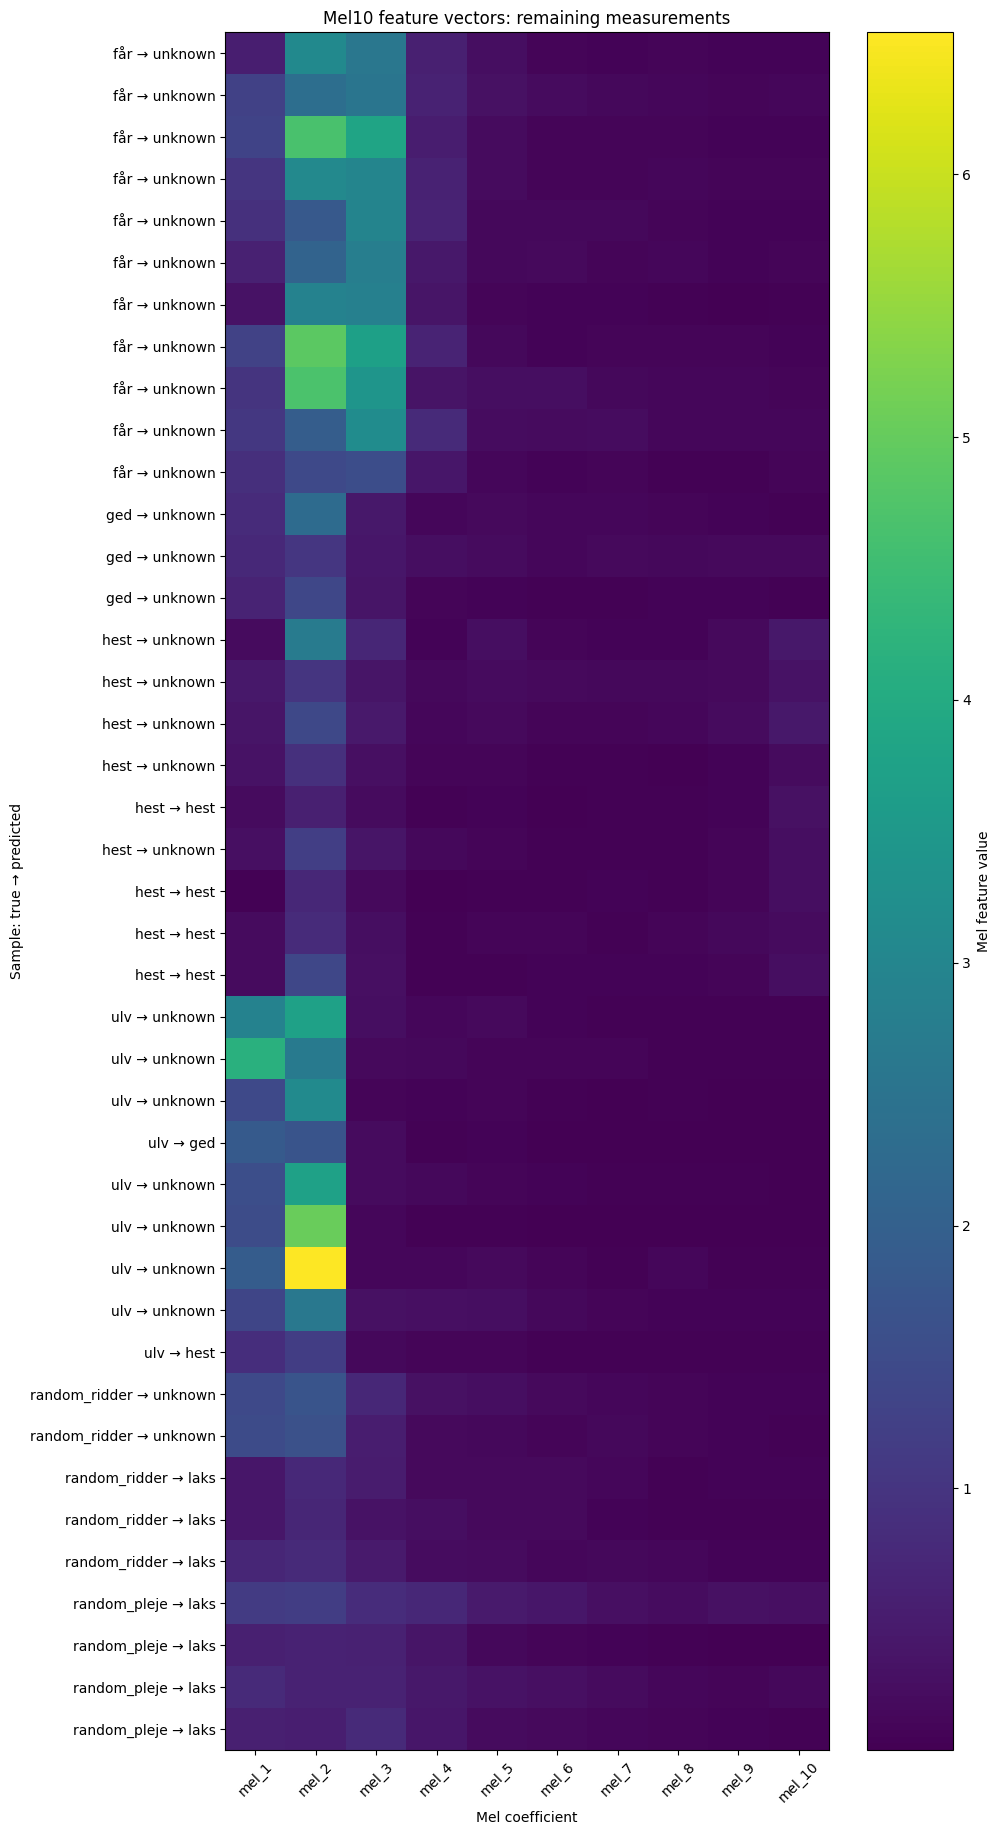

In [7]:
import matplotlib.pyplot as plt
import numpy as np

MEL_NAMES = [f"mel_{i}" for i in range(1, 11)]

NON_LAKS_KEYWORDS = ["får", "ged", "hest", "ulv"]


def plot_mel10_subset(subset_df, title):
    if subset_df.empty:
        print(f"No samples for: {title}")
        return

    plot_df = subset_df.copy()

    plot_df["row_label"] = (
        plot_df["true_label"].astype(str)
        + " → "
        + plot_df["pred_label"].astype(str)
    )

    X = plot_df[MEL_NAMES].to_numpy()

    plt.figure(figsize=(10, max(4, 0.45 * len(plot_df))))
    plt.imshow(X, aspect="auto")

    plt.xticks(range(len(MEL_NAMES)), MEL_NAMES, rotation=45)
    plt.yticks(range(len(plot_df)), plot_df["row_label"])

    plt.colorbar(label="Mel feature value")
    plt.title(title)
    plt.xlabel("Mel coefficient")
    plt.ylabel("Sample: true → predicted")

    plt.tight_layout()
    plt.show()


# Gruppe 1: laks → laks
mask_laks_to_laks = (
    (df["true_label"] == "laks") &
    (df["pred_label"] == "laks")
)

# Gruppe 2: andre keywords → laks
mask_other_keywords_to_laks = (
    (df["true_label"].isin(NON_LAKS_KEYWORDS)) &
    (df["pred_label"] == "laks")
)

# Gruppe 3: alle resterende målinger
mask_remaining = ~(
    mask_laks_to_laks |
    mask_other_keywords_to_laks
)


plot_mel10_subset(
    df[mask_laks_to_laks],
    "Mel10 feature vectors: laks → laks"
)

plot_mel10_subset(
    df[mask_other_keywords_to_laks],
    "Mel10 feature vectors: other keywords → laks"
)

plot_mel10_subset(
    df[mask_remaining],
    "Mel10 feature vectors: remaining measurements"
)

Global Mel range:
vmin = 0.004663
vmax = 6.540278


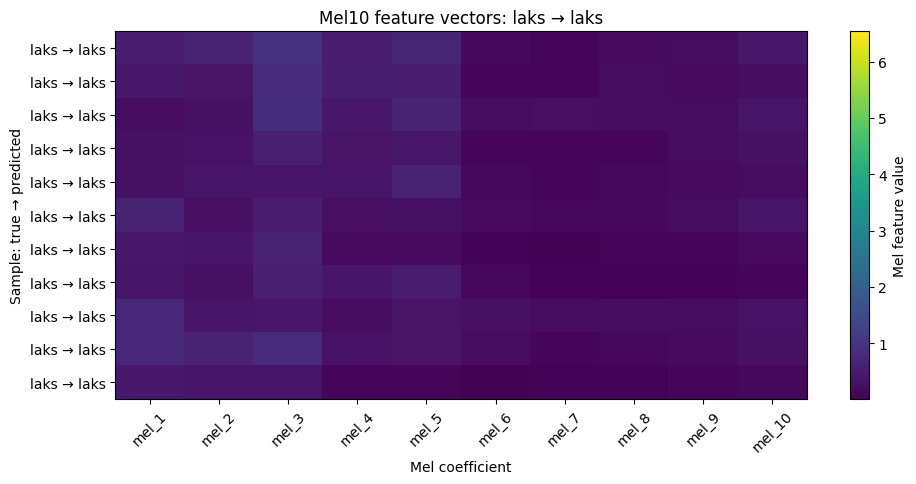

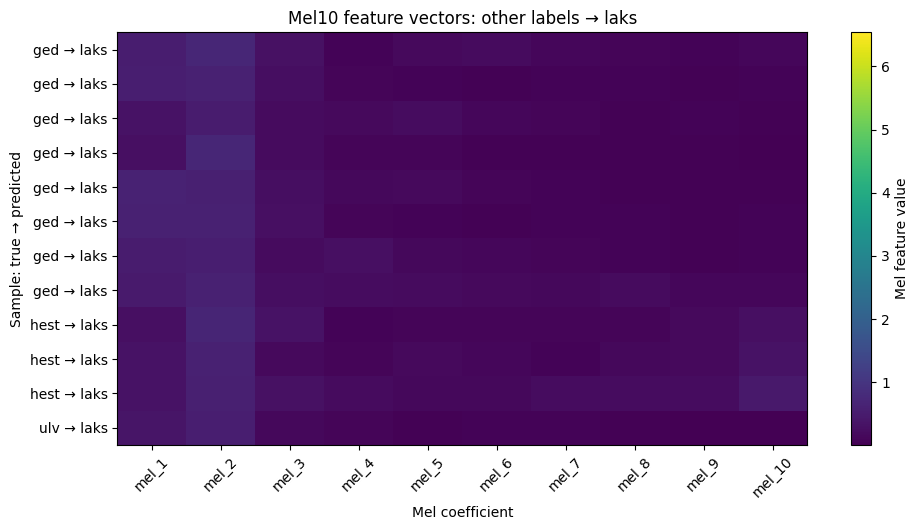

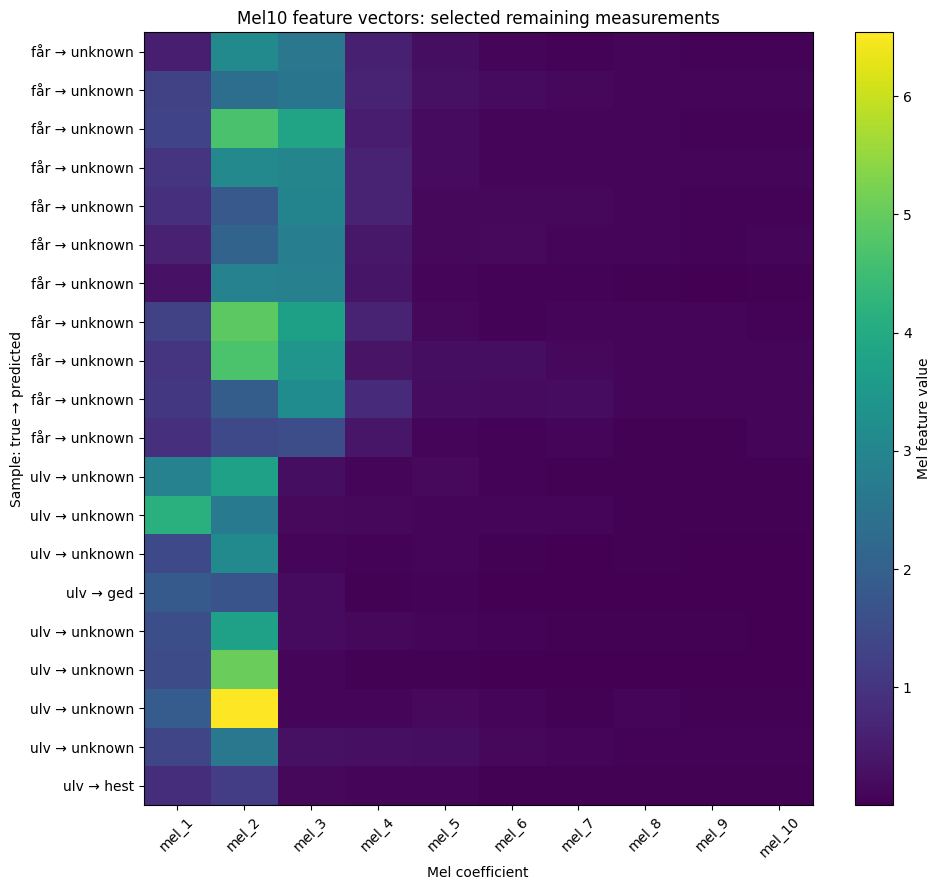

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

MEL_NAMES = [f"mel_{i}" for i in range(1, 11)]

# Labels som kan blive fejlagtigt klassificeret som laks
OTHER_TO_LAKS_LABELS = [
    "får",
    "ged",
    "hest",
    "ulv",
    "ridder",
    "pleje",
    "unknown",
]

# De resterende målinger du vil vise i tredje plot
# Tilpas listen hvis du vil have flere/andre kombinationer med.
REMAINING_PAIRS = [
    ("får", "unknown"),
    ("ulv", "unknown"),
    ("ulv", "ged"),
    ("ulv", "hest"),
    ("ridder", "unknown"),
    ("pleje", "unknown"),
    ("ridder", "laks"),   # fjern hvis ridder→laks kun skal være i plot 2
    ("pleje", "laks"),    # fjern hvis pleje→laks kun skal være i plot 2
]

# Fælles farveskala for alle plots
all_X = df[MEL_NAMES].to_numpy()
GLOBAL_VMIN = np.min(all_X)
GLOBAL_VMAX = np.max(all_X)

print("Global Mel range:")
print("vmin =", GLOBAL_VMIN)
print("vmax =", GLOBAL_VMAX)


def plot_mel10_subset(subset_df, title, vmin=GLOBAL_VMIN, vmax=GLOBAL_VMAX):
    if subset_df.empty:
        print(f"No samples for: {title}")
        return

    plot_df = subset_df.copy()

    plot_df["row_label"] = (
        plot_df["true_label"].astype(str)
        + " → "
        + plot_df["pred_label"].astype(str)
    )

    X = plot_df[MEL_NAMES].to_numpy()

    plt.figure(figsize=(10, max(4, 0.45 * len(plot_df))))

    plt.imshow(
        X,
        aspect="auto",
        vmin=vmin,
        vmax=vmax
    )

    plt.xticks(range(len(MEL_NAMES)), MEL_NAMES, rotation=45)
    plt.yticks(range(len(plot_df)), plot_df["row_label"])

    plt.colorbar(label="Mel feature value")
    plt.title(title)
    plt.xlabel("Mel coefficient")
    plt.ylabel("Sample: true → predicted")

    plt.tight_layout()
    plt.show()


# Plot 1: laks → laks
mask_laks_to_laks = (
    (df["true_label"] == "laks") &
    (df["pred_label"] == "laks")
)


# Plot 2: andre labels → laks
# inkluderer nu også ridder og pleje
mask_other_to_laks = (
    (df["true_label"].isin(OTHER_TO_LAKS_LABELS)) &
    (df["true_label"] != "laks") &
    (df["pred_label"] == "laks")
)


# Plot 3: kun de resterende typer du vil vise
mask_remaining_pairs = np.zeros(len(df), dtype=bool)

for true_label, pred_label in REMAINING_PAIRS:
    mask_remaining_pairs |= (
        (df["true_label"] == true_label) &
        (df["pred_label"] == pred_label)
    )

# Sørg for at plot 3 ikke gentager plot 1 og 2
mask_remaining = (
    mask_remaining_pairs &
    ~mask_laks_to_laks &
    ~mask_other_to_laks
)


plot_mel10_subset(
    df[mask_laks_to_laks],
    "Mel10 feature vectors: laks → laks"
)

plot_mel10_subset(
    df[mask_other_to_laks],
    "Mel10 feature vectors: other labels → laks"
)

plot_mel10_subset(
    df[mask_remaining],
    "Mel10 feature vectors: selected remaining measurements"
)

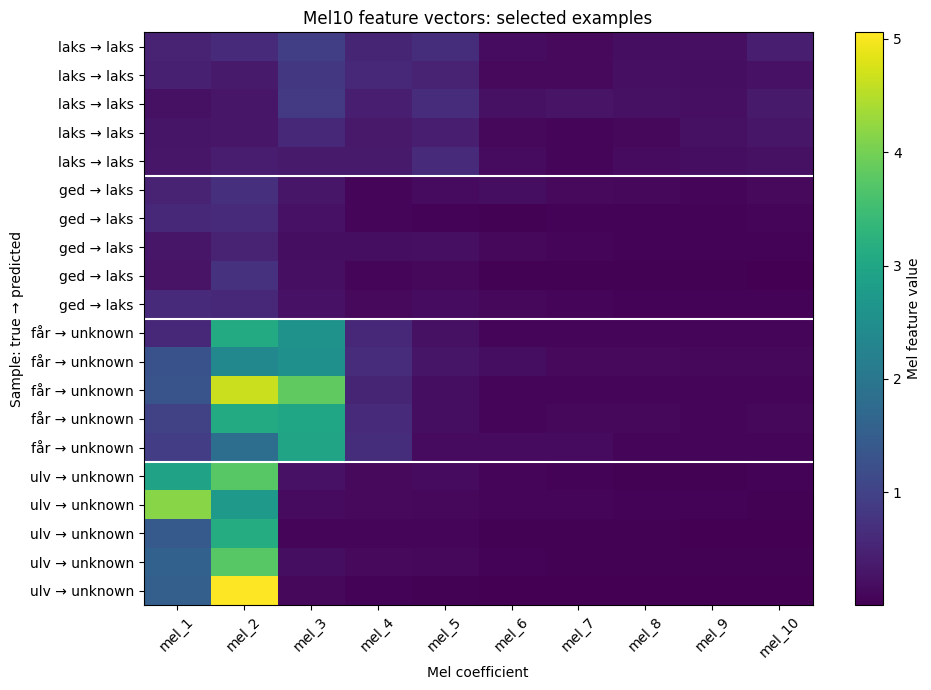

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

MEL_NAMES = [f"mel_{i}" for i in range(1, 11)]

# Masks
mask_laks_to_laks = (
    (df["true_label"] == "laks") &
    (df["pred_label"] == "laks")
)

mask_keywords_to_laks = (
    (df["true_label"].isin(["får", "ged", "hest", "ulv"])) &
    (df["pred_label"] == "laks")
)

mask_faar_to_unknown = (
    (df["true_label"] == "får") &
    (df["pred_label"] == "unknown")
)

mask_ulv_to_unknown = (
    (df["true_label"] == "ulv") &
    (df["pred_label"] == "unknown")
)

# Tag 5 instanser fra hver type
group1 = df[mask_laks_to_laks].head(5)
group2 = df[mask_keywords_to_laks].head(5)
group3 = df[mask_faar_to_unknown].head(5)
group4 = df[mask_ulv_to_unknown].head(5)

# Saml i ønsket rækkefølge
plot_df = pd.concat([group1, group2, group3, group4], axis=0).copy()

# Labels til y-aksen
plot_df["row_label"] = (
    plot_df["true_label"].astype(str)
    + " → "
    + plot_df["pred_label"].astype(str)
)

X = plot_df[MEL_NAMES].to_numpy()

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(X, aspect="auto", interpolation="nearest")

ax.set_xticks(range(len(MEL_NAMES)))
ax.set_xticklabels(MEL_NAMES, rotation=45)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df["row_label"])

ax.set_title("Mel10 feature vectors: selected examples")
ax.set_xlabel("Mel coefficient")
ax.set_ylabel("Sample: true → predicted")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Mel feature value")

# Separatorer mellem grupper
n1 = len(group1)
n2 = len(group2)
n3 = len(group3)
n4 = len(group4)

for y in [n1 - 0.5, n1 + n2 - 0.5, n1 + n2 + n3 - 0.5]:
    ax.axhline(y, color="white", linewidth=1.5)

plt.tight_layout()
plt.show()

Files used:
får -> test_får_C_0.75m_Chjem_002_s01.wav
ged -> test_ged_C_0.75m_Chjem_002_s01.wav
hest -> test_hest_C_0.75m_Chjem_002_s01.wav
laks -> test_laks_C_0.75m_Chjem_002_s01.wav
ulv -> test_ulv_C_0.75m_Chjem_002_s01.wav


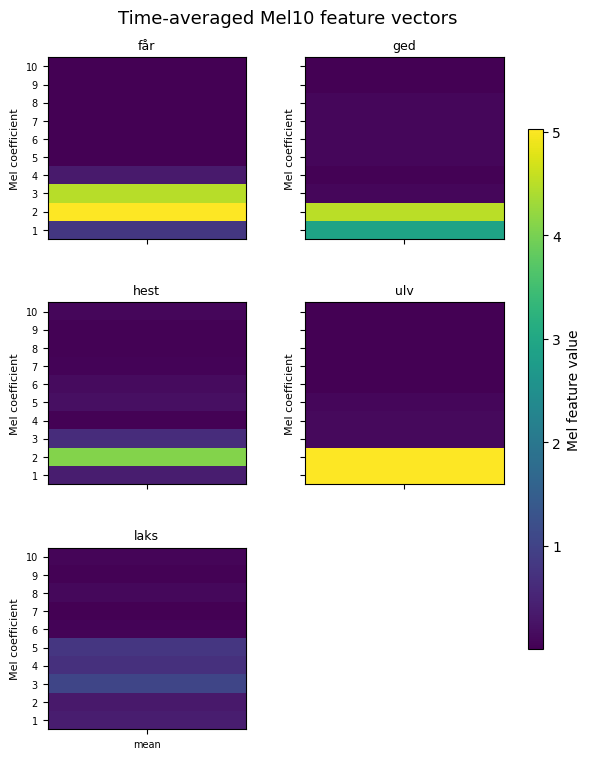

In [5]:
from pathlib import Path
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt

# =========================
# SETTINGS
# =========================
SAMPLE_RATE = 16000
N_MELS = 10
NFFT = 4096
HOP = 2048

BASE_DIR = Path("test_ready_chjem2")

LABELS = ["får", "ged", "hest", "laks", "ulv"]
N_PER_CLASS = 1

MEL_NAMES = [f"mel_{i}" for i in range(1, N_MELS + 1)]

# =========================
# MEL FUNCTIONS
# =========================
def hz_to_mel(hz):
    return 2595.0 * np.log10(1.0 + hz / 700.0)

def mel_to_hz(mels):
    return 700.0 * (10.0 ** (mels / 2595.0) - 1.0)

def eml_audio_mel_center(n, n_mels, fmin, fmax):
    melmin = hz_to_mel(fmin)
    melmax = hz_to_mel(fmax)
    melstep = (melmax - melmin) / (n_mels + 1)
    return mel_to_hz(melmin + n * melstep)

def eml_audio_mel_bin(hz, n_fft, samplerate):
    return int(np.floor((n_fft + 1) * (hz / samplerate)))

def eml_fft_freq(k, n_fft, samplerate):
    end = samplerate / 2.0
    steps = (1 + n_fft // 2) - 1
    return (k * end) / steps

def load_audio(path):
    x, sr = sf.read(path, always_2d=False)
    x = np.asarray(x, dtype=np.float32)

    if x.ndim > 1:
        x = x.mean(axis=1)

    if sr != SAMPLE_RATE:
        raise ValueError(f"Wrong sample rate: {path}, got {sr}")

    peak = np.max(np.abs(x)) + 1e-9
    return x / peak

def iter_fft_frames(x, fft_n=NFFT, hop=HOP):
    if len(x) <= fft_n:
        starts = [0]
    else:
        starts = list(range(0, len(x) - fft_n + 1, hop))
        last_start = len(x) - fft_n

        if starts[-1] != last_start:
            starts.append(last_start)

    window = np.hanning(fft_n).astype(np.float32)

    for start in starts:
        frame = np.zeros(fft_n, dtype=np.float32)
        end = min(start + fft_n, len(x))
        frame[:end - start] = x[start:end]
        frame *= window
        yield frame

def mel_spectrum_one_frame(frame, fs, n_mels=N_MELS):
    spec = np.fft.rfft(frame)

    # Matcher din EMLearn/C++-style implementation
    real_part = np.real(spec).astype(np.float32)
    power = (np.abs(real_part) ** 2) / float(NFFT)

    fmin = 0.0
    fmax = fs / 2.0
    max_bin = 1 + NFFT // 2

    mels = np.zeros(n_mels, dtype=np.float32)

    for m in range(1, n_mels + 1):
        left_hz = eml_audio_mel_center(m - 1, n_mels, fmin, fmax)
        center_hz = eml_audio_mel_center(m, n_mels, fmin, fmax)
        right_hz = eml_audio_mel_center(m + 1, n_mels, fmin, fmax)

        left = max(0, min(eml_audio_mel_bin(left_hz, NFFT, fs), max_bin - 1))
        center = max(0, min(eml_audio_mel_bin(center_hz, NFFT, fs), max_bin - 1))
        right = max(0, min(eml_audio_mel_bin(right_hz, NFFT, fs), max_bin - 1))

        fdifflow = center_hz - left_hz
        fdiffupper = right_hz - center_hz

        val = 0.0

        for k in range(left, center + 1):
            r = left_hz - eml_fft_freq(k, NFFT, fs)
            weight = max(min(-r / fdifflow if fdifflow != 0 else 0.0, 1.0), 0.0)
            val += power[k] * weight

        for k in range(center, right):
            if k + 1 >= len(power):
                break

            r = right_hz - eml_fft_freq(k + 1, NFFT, fs)
            weight = max(min(r / fdiffupper if fdiffupper != 0 else 0.0, 1.0), 0.0)
            val += power[k + 1] * weight

        mels[m - 1] = val

    return mels

def extract_model_features(x):
    vals = []

    for frame in iter_fft_frames(x, fft_n=NFFT, hop=HOP):
        vals.append(mel_spectrum_one_frame(frame, SAMPLE_RATE, N_MELS))

    vals = np.asarray(vals, dtype=np.float32)

    # Dette er præcis det modellen ser:
    # Mel10 averaged over time
    return np.mean(vals, axis=0)

# =========================
# FIND FILES
# =========================
items = []

for label in LABELS:
    wavs = sorted((BASE_DIR / label).glob("*0.75m*.wav"))

    if len(wavs) < N_PER_CLASS:
        wavs = sorted((BASE_DIR / label).glob("*.wav"))

    for wav in wavs[:N_PER_CLASS]:
        items.append((label, wav))

print("Files used:")
for label, wav in items:
    print(label, "->", wav.name)

# =========================
# COMPUTE FEATURES
# =========================
feature_cache = []

for label, wav in items:
    x = load_audio(wav)
    feats = extract_model_features(x)
    feature_cache.append((label, wav, feats))

all_vals = np.concatenate([f for _, _, f in feature_cache])
vmin = np.percentile(all_vals, 5)
vmax = np.percentile(all_vals, 95)

# =========================
# PLOT
# =========================
plot_positions = {
    "får":  (0, 0),
    "ged":  (0, 1),
    "hest": (1, 0),
    "ulv":  (1, 1),
    "laks": (2, 0),
}

fig, axes = plt.subplots(
    3,
    2,
    figsize=(6, 8),
    sharex=True,
    sharey=True
)

# Sluk alle akser først
for ax in axes.flat:
    ax.axis("off")

for label, wav, feats in feature_cache:
    row, col = plot_positions[label]
    ax = axes[row, col]
    ax.axis("on")

    X = feats.reshape(N_MELS, 1)

    im = ax.imshow(
        X,
        aspect="auto",
        origin="lower",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(f"{label}", fontsize=9)

    ax.set_xticks([0])
    ax.set_xticklabels(["mean"], fontsize=7)

    ax.set_yticks(range(N_MELS))
    ax.set_yticklabels(range(1, N_MELS + 1), fontsize=7)

    ax.set_ylabel("Mel coefficient", fontsize=8)

# Ryk laks ind i midten
box = axes[2, 0].get_position()
axes[2, 0].set_position([
    0.5 - box.width / 2,
    box.y0 + 0.08,
    box.width,
    box.height
])

plt.subplots_adjust(
    left=0.10,
    right=0.86,
    top=0.92,
    bottom=0.08,
    wspace=0.30,
    hspace=0.35
)

cbar_ax = fig.add_axes([0.90, 0.18, 0.025, 0.65])
fig.colorbar(im, cax=cbar_ax, label="Mel feature value")

fig.suptitle("Time-averaged Mel10 feature vectors", fontsize=13)

plt.show()

I 2.cpp ændrer du så til den nederste udkommenteret kode. Dertil compiler og flasher du igen.

Når det er flashet, så kører du den version med nedenstående Python kode SAMTIDIG

In [5]:
import serial
import numpy as np
import soundfile as sf
from pathlib import Path
import time

PORT = "COM4"   # skift til din Particle COM-port
BAUD = 115200
FS = 16000

OUT_DIR = Path("usb_captures")
OUT_DIR.mkdir(exist_ok=True)

ser = serial.Serial(PORT, BAUD, timeout=20)
ser.reset_input_buffer()
ser.reset_output_buffer()
time.sleep(2)

print("Waiting for BEGIN_WAV_RAW...")

counter = 0

def read_exact(ser, n_bytes):
    buf = bytearray()

    while len(buf) < n_bytes:
        chunk = ser.read(n_bytes - len(buf))

        if not chunk:
            break

        buf.extend(chunk)

    return bytes(buf)

while True:
    line = ser.readline().decode("utf-8", errors="ignore").strip()

    if line:
        print(line)

    if line == "BEGIN_WAV_RAW":
        sample_line = ser.readline().decode("utf-8", errors="ignore").strip()
        print(sample_line)

        if not sample_line.startswith("SAMPLES"):
            print("Bad header")
            continue

        n_samples = int(sample_line.split()[1])
        n_bytes = n_samples * 2

        raw = read_exact(ser, n_bytes)

        if len(raw) != n_bytes:
            print(f"Only got {len(raw)} / {n_bytes} bytes")
            continue

        audio = np.frombuffer(raw, dtype=np.int16)

        print("min:", audio.min())
        print("max:", audio.max())
        print("peak:", np.max(np.abs(audio)))
        print("clipped samples:", np.sum(np.abs(audio) > 32000))
        
        out_path = OUT_DIR / f"live_capture_{counter:03d}.wav"
        sf.write(out_path, audio, FS, subtype="PCM_16")

        print(f"Saved {out_path}")
        counter += 1

Waiting for BEGIN_WAV_RAW...
TRIGGER rms=0.0899 noise=0.0070 thr=0.0418 count=3
CAPTURE DONE len=16000
CLIP STATS -> min=-32768 max=32256 clipped=53
BEGIN_WAV_RAW
SAMPLES 16000
min: -32768
max: 32256
peak: 32767
clipped samples: 109
Saved usb_captures\live_capture_000.wav
END_WAV_RAW
REARMED
TRIGGER rms=0.0679 noise=0.0054 thr=0.0400 count=3
CAPTURE DONE len=16000
CLIP STATS -> min=-32767 max=32256 clipped=14
BEGIN_WAV_RAW
SAMPLES 16000
min: -32767
max: 32256
peak: 32767
clipped samples: 19
Saved usb_captures\live_capture_001.wav
END_WAV_RAW
REARMED
TRIGGER rms=0.2549 noise=0.0060 thr=0.0400 count=3
CAPTURE DONE len=16000
CLIP STATS -> min=-32768 max=32000 clipped=60
BEGIN_WAV_RAW
SAMPLES 16000
min: -32768
max: 32000
peak: 32767
clipped samples: 92
Saved usb_captures\live_capture_002.wav
END_WAV_RAW
REARMED


KeyboardInterrupt: 

Clean test får True C:\Users\chris\OneDrive - Aarhus universitet\Skrivebord\Valgfag\F26\TML\Projekt\ML model\Multi_FFT_Averaging\Test_C_hjem_v2\test_ready_chjem2\får\test_får_C_0.75m_Chjem_002_s01.wav
Live capture True C:\Users\chris\OneDrive - Aarhus universitet\Skrivebord\Valgfag\F26\TML\Projekt\ML model\Multi_FFT_Averaging\Test_C_hjem_v2\usb_captures\live_capture_000.wav


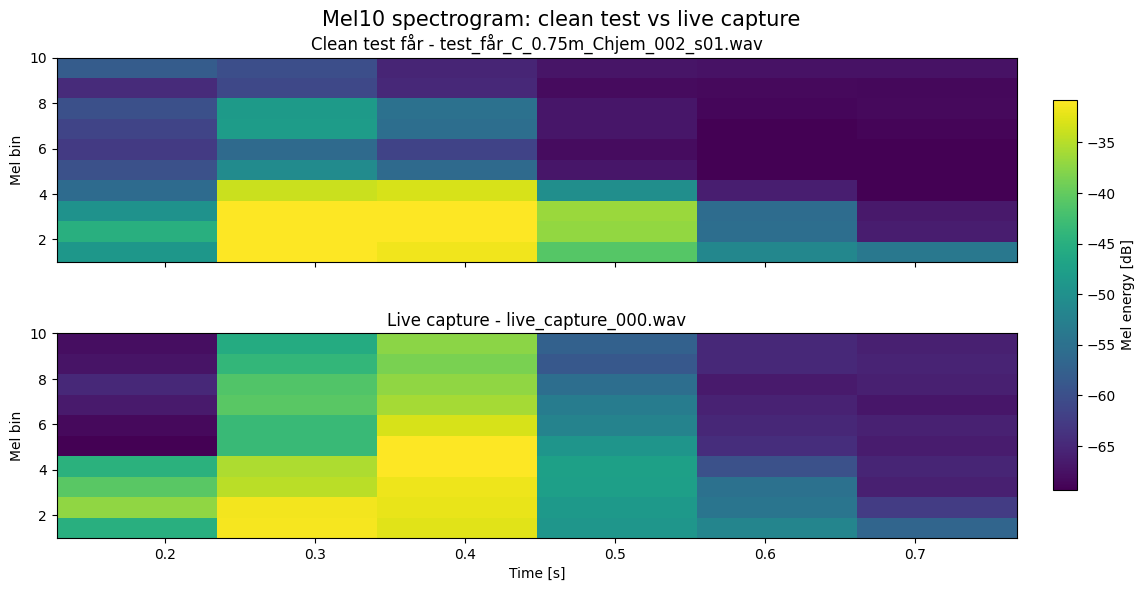

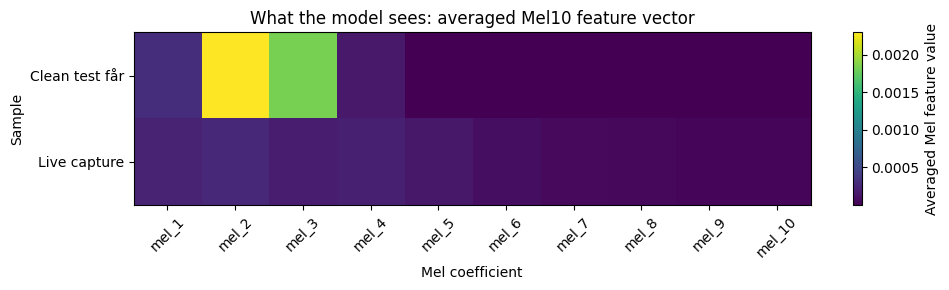

In [1]:
from pathlib import Path
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

SAMPLE_RATE = 16000
N_MELS = 10
NFFT = 4096
HOP = 2048

BASE = Path(r"C:\Users\chris\OneDrive - Aarhus universitet\Skrivebord\Valgfag\F26\TML\Projekt\ML model\Multi_FFT_Averaging\Test_C_hjem_v2")

file_clean = BASE / "test_ready_chjem2" / "får" / "test_får_C_0.75m_Chjem_002_s01.wav"
file_live  = BASE / "usb_captures" / "live_capture_000.wav"

FILES = {
    "Clean test får": file_clean,
    "Live capture": file_live,
}

def hz_to_mel(hz):
    return 2595.0 * np.log10(1.0 + hz / 700.0)

def mel_to_hz(mel):
    return 700.0 * (10.0 ** (mel / 2595.0) - 1.0)

def mel_filterbank(n_mels, n_fft, sr):
    mel_points = np.linspace(hz_to_mel(0), hz_to_mel(sr / 2), n_mels + 2)
    hz_points = mel_to_hz(mel_points)
    bins = np.floor((n_fft + 1) * hz_points / sr).astype(int)

    fb = np.zeros((n_mels, n_fft // 2 + 1))

    for m in range(1, n_mels + 1):
        left, center, right = bins[m - 1], bins[m], bins[m + 1]

        for k in range(left, center):
            fb[m - 1, k] = (k - left) / max(center - left, 1)

        for k in range(center, right):
            fb[m - 1, k] = (right - k) / max(right - center, 1)

    return fb

FB = mel_filterbank(N_MELS, NFFT, SAMPLE_RATE)

def load_audio(path):
    x, sr = sf.read(str(path), always_2d=False)
    x = np.asarray(x, dtype=np.float32)

    if x.ndim > 1:
        x = x.mean(axis=1)

    if sr != SAMPLE_RATE:
        raise ValueError(f"Wrong sample rate: {path}, got {sr}")

    peak = np.max(np.abs(x)) + 1e-9
    x = x / peak

    return x

def mel_spectrogram(x):
    _, t, Sxx = spectrogram(
        x,
        fs=SAMPLE_RATE,
        window="hann",
        nperseg=NFFT,
        noverlap=NFFT - HOP,
        nfft=NFFT,
        mode="magnitude"
    )

    mel = FB @ (Sxx ** 2)
    mel_db = 10 * np.log10(mel + 1e-12)

    return t, mel, mel_db

# =========================
# Load and compute
# =========================
cache = []

for name, path in FILES.items():
    print(name, path.exists(), path)

    x = load_audio(path)
    t, mel, mel_db = mel_spectrogram(x)

    mel_mean = np.mean(mel, axis=1)

    cache.append((name, path, t, mel, mel_db, mel_mean))

# fælles farveskala
all_vals = np.concatenate([mel_db.flatten() for _, _, _, _, mel_db, _ in cache])
vmin = np.percentile(all_vals, 5)
vmax = np.percentile(all_vals, 95)

# =========================
# Plot 1: Mel spectrograms
# =========================
fig, axes = plt.subplots(
    len(cache),
    1,
    figsize=(12, 6),
    sharex=True,
    sharey=True
)

if len(cache) == 1:
    axes = [axes]

for ax, (name, path, t, mel, mel_db, mel_mean) in zip(axes, cache):
    im = ax.imshow(
        mel_db,
        aspect="auto",
        origin="lower",
        extent=[t[0], t[-1], 1, N_MELS],
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(f"{name} - {path.name}")
    ax.set_ylabel("Mel bin")

axes[-1].set_xlabel("Time [s]")

plt.subplots_adjust(
    left=0.08,
    right=0.88,
    top=0.90,
    bottom=0.10,
    hspace=0.35
)

cbar_ax = fig.add_axes([0.91, 0.18, 0.02, 0.65])
fig.colorbar(im, cax=cbar_ax, label="Mel energy [dB]")

fig.suptitle("Mel10 spectrogram: clean test vs live capture", fontsize=15)
plt.show()

# =========================
# Plot 2: What the model sees
# averaged Mel10 vector
# =========================
mel_vectors = np.vstack([mel_mean for _, _, _, _, _, mel_mean in cache])
row_labels = [name for name, *_ in cache]

plt.figure(figsize=(10, 3))
plt.imshow(mel_vectors, aspect="auto")

plt.xticks(range(N_MELS), [f"mel_{i}" for i in range(1, N_MELS + 1)], rotation=45)
plt.yticks(range(len(row_labels)), row_labels)

plt.colorbar(label="Averaged Mel feature value")
plt.title("What the model sees: averaged Mel10 feature vector")
plt.xlabel("Mel coefficient")
plt.ylabel("Sample")

plt.tight_layout()
plt.show()

min: -32767
max: 32256
clipped samples: 21


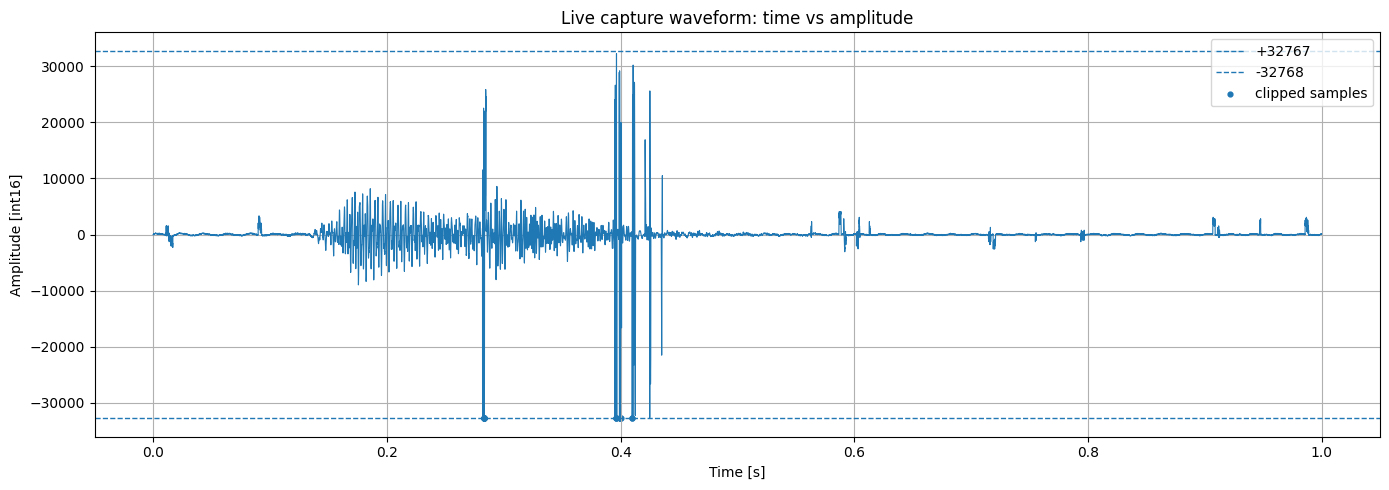

In [2]:
from pathlib import Path
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt

FS = 16000

BASE = Path(r"C:\Users\chris\OneDrive - Aarhus universitet\Skrivebord\Valgfag\F26\TML\Projekt\ML model\Multi_FFT_Averaging\Test_C_hjem_v2")
file_live = BASE / "usb_captures" / "live_capture_000.wav"

x, fs = sf.read(str(file_live), always_2d=False)

if x.ndim > 1:
    x = x.mean(axis=1)

# Hvis soundfile loader som float [-1, 1], konverter til int16-skala
x = np.asarray(x)
if np.issubdtype(x.dtype, np.floating):
    x_i16 = np.round(x * 32768).astype(np.int16)
else:
    x_i16 = x.astype(np.int16)

t = np.arange(len(x_i16)) / fs

clip_thr = 32760
clipped = np.where((x_i16 <= -clip_thr) | (x_i16 >= clip_thr))[0]

print("min:", x_i16.min())
print("max:", x_i16.max())
print("clipped samples:", len(clipped))

plt.figure(figsize=(14, 5))
plt.plot(t, x_i16, linewidth=0.8)

plt.axhline(32767, linestyle="--", linewidth=1, label="+32767")
plt.axhline(-32768, linestyle="--", linewidth=1, label="-32768")

if len(clipped) > 0:
    plt.scatter(t[clipped], x_i16[clipped], s=12, label="clipped samples")

plt.title("Live capture waveform: time vs amplitude")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude [int16]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [3]:
from pathlib import Path
import numpy as np
import soundfile as sf

BASE = Path(r"C:\Users\chris\OneDrive - Aarhus universitet\Skrivebord\Valgfag\F26\TML\Projekt\ML model\Multi_FFT_Averaging\Test_C_hjem_v2\test_ready_chjem2\hurtig")
FILES = sorted(BASE.rglob("*.wav"))

CLIP_THR = 32760
JUMP_THR = 20000

for file in FILES:
    x, fs = sf.read(str(file), always_2d=False)

    if x.ndim > 1:
        x = x.mean(axis=1)

    if np.issubdtype(x.dtype, np.floating):
        x_i16 = np.round(x * 32768).astype(np.int32)
    else:
        x_i16 = x.astype(np.int32)

    clipped = np.sum((x_i16 <= -CLIP_THR) | (x_i16 >= CLIP_THR))
    large_jump = np.sum(np.abs(np.diff(x_i16)) > JUMP_THR)

    print(
        file.name,
        "min=", x_i16.min(),
        "max=", x_i16.max(),
        "clipped=", clipped,
        "large_jump=", large_jump
    )

test_får_chjemfrfr.001.wav min= -32668 max= 32688 clipped= 0 large_jump= 2


min: -32668
max: 32688
clipped samples: 0


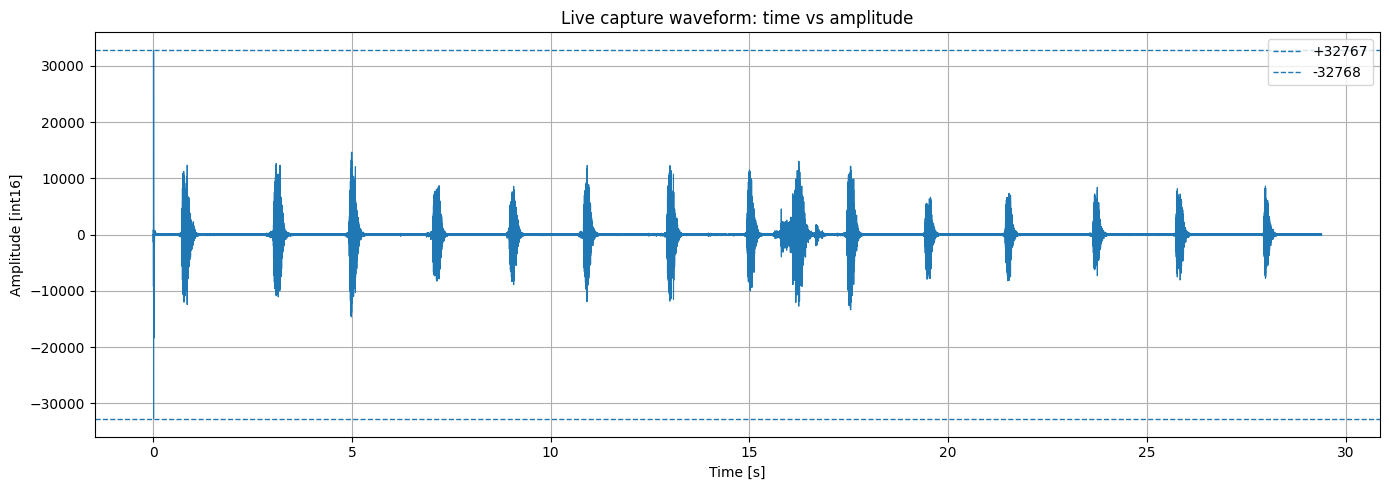

In [4]:
from pathlib import Path
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt

FS = 16000

BASE = Path(r"C:\Users\chris\OneDrive - Aarhus universitet\Skrivebord\Valgfag\F26\TML\Projekt\ML model\Multi_FFT_Averaging\Test_C_hjem_v2")
file_live = BASE / "test_ready_chjem2" / "hurtig" / "test_får_chjemfrfr.001.wav"

x, fs = sf.read(str(file_live), always_2d=False)

if x.ndim > 1:
    x = x.mean(axis=1)

# Hvis soundfile loader som float [-1, 1], konverter til int16-skala
x = np.asarray(x)
if np.issubdtype(x.dtype, np.floating):
    x_i16 = np.round(x * 32768).astype(np.int16)
else:
    x_i16 = x.astype(np.int16)

t = np.arange(len(x_i16)) / fs

clip_thr = 32760
clipped = np.where((x_i16 <= -clip_thr) | (x_i16 >= clip_thr))[0]

print("min:", x_i16.min())
print("max:", x_i16.max())
print("clipped samples:", len(clipped))

plt.figure(figsize=(14, 5))
plt.plot(t, x_i16, linewidth=0.8)

plt.axhline(32767, linestyle="--", linewidth=1, label="+32767")
plt.axhline(-32768, linestyle="--", linewidth=1, label="-32768")

if len(clipped) > 0:
    plt.scatter(t[clipped], x_i16[clipped], s=12, label="clipped samples")

plt.title("Live capture waveform: time vs amplitude")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude [int16]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

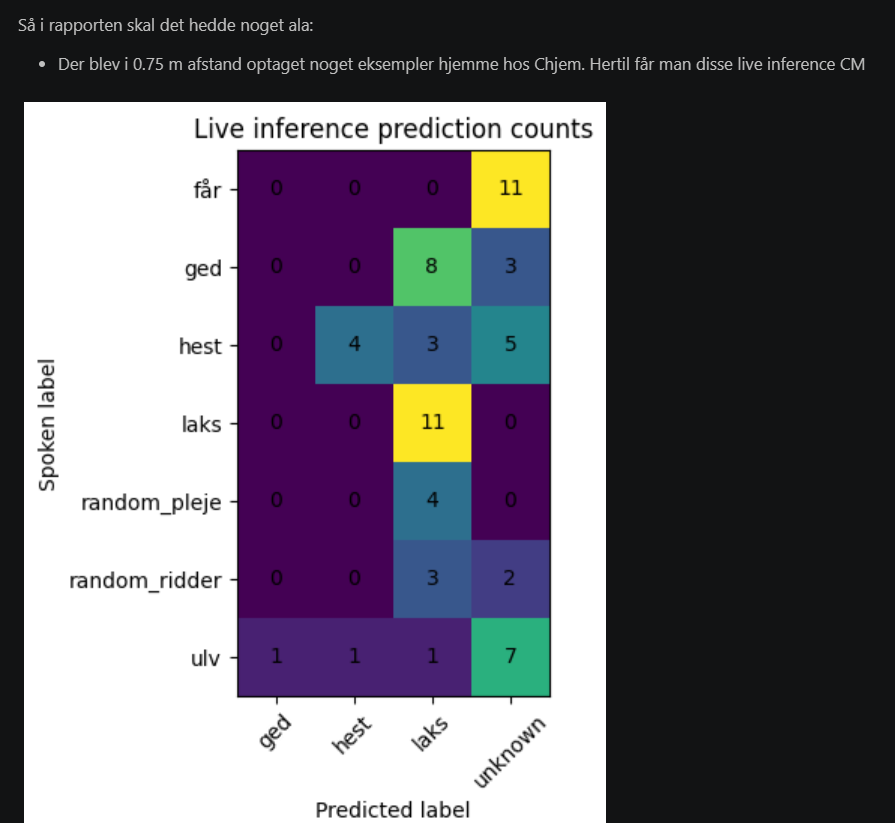

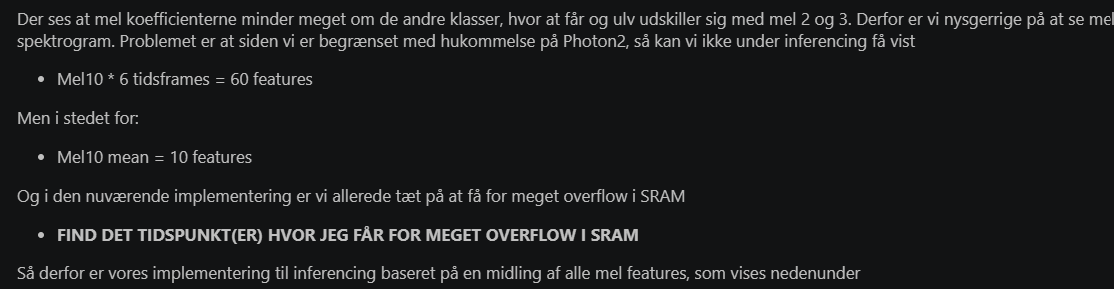

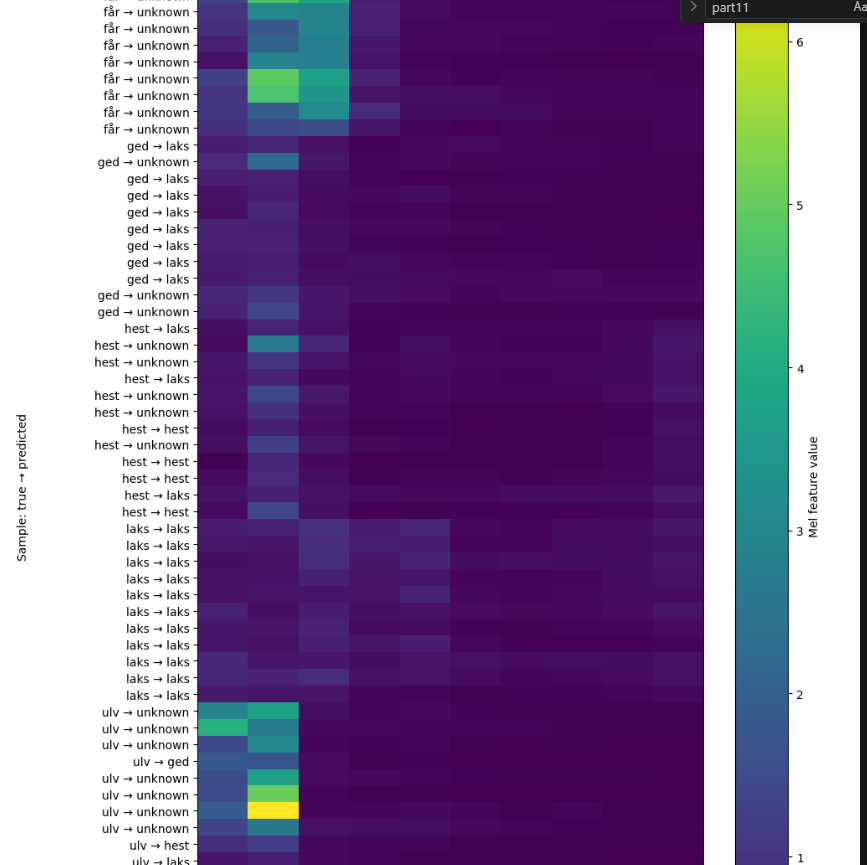

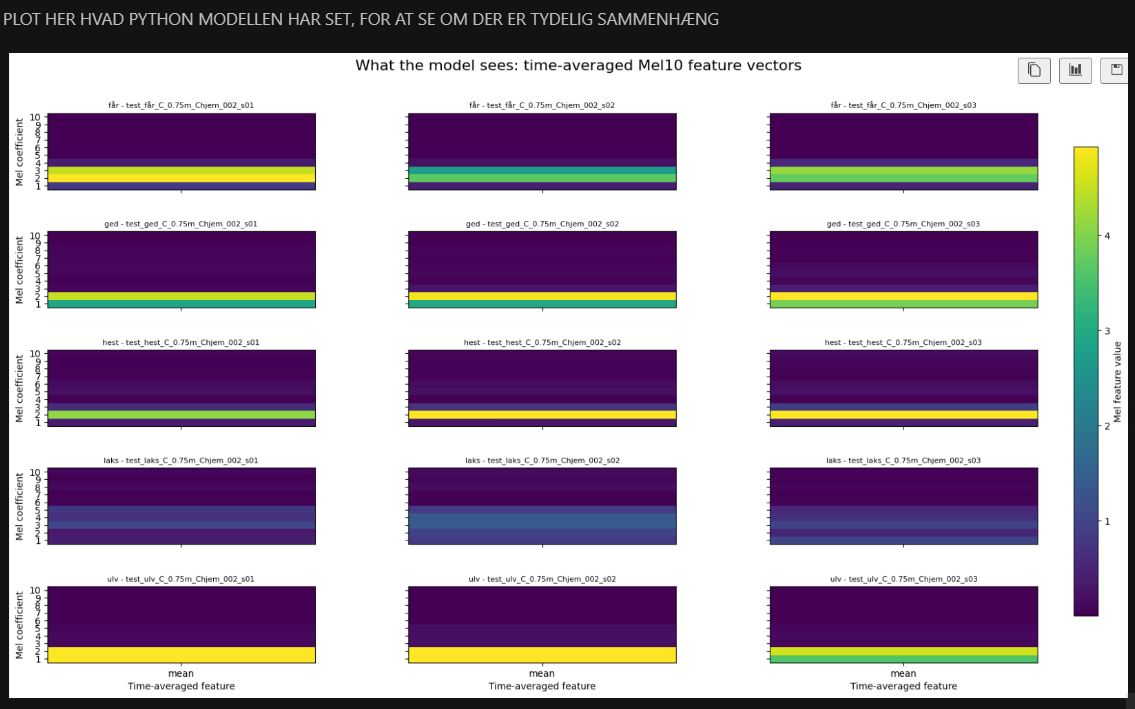

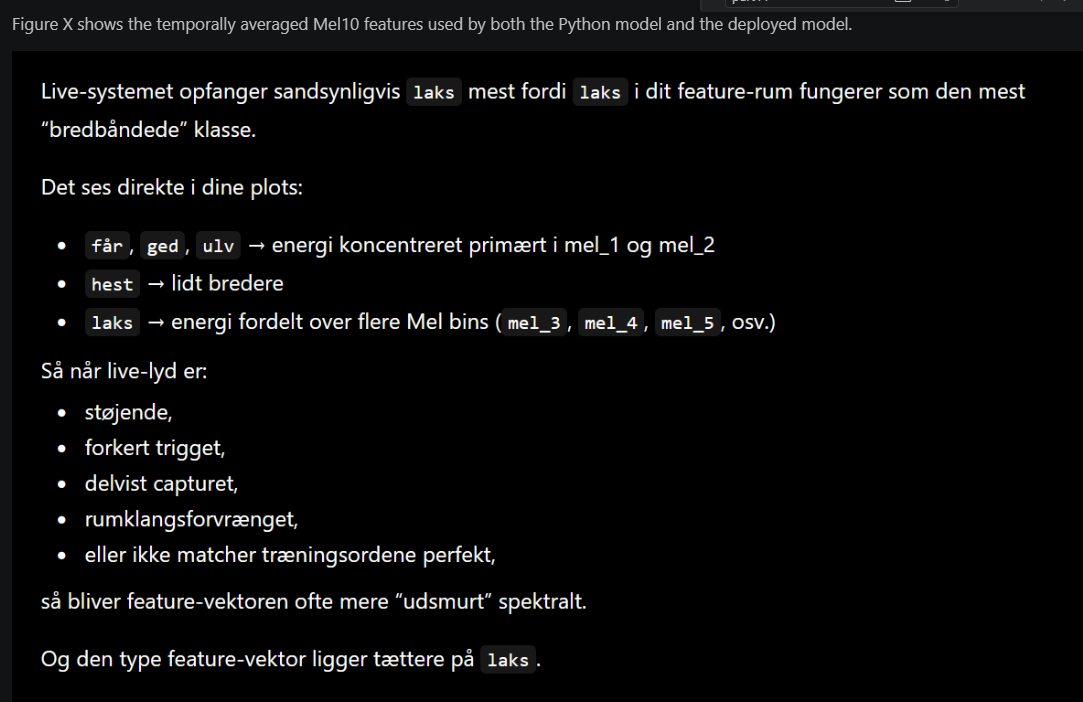

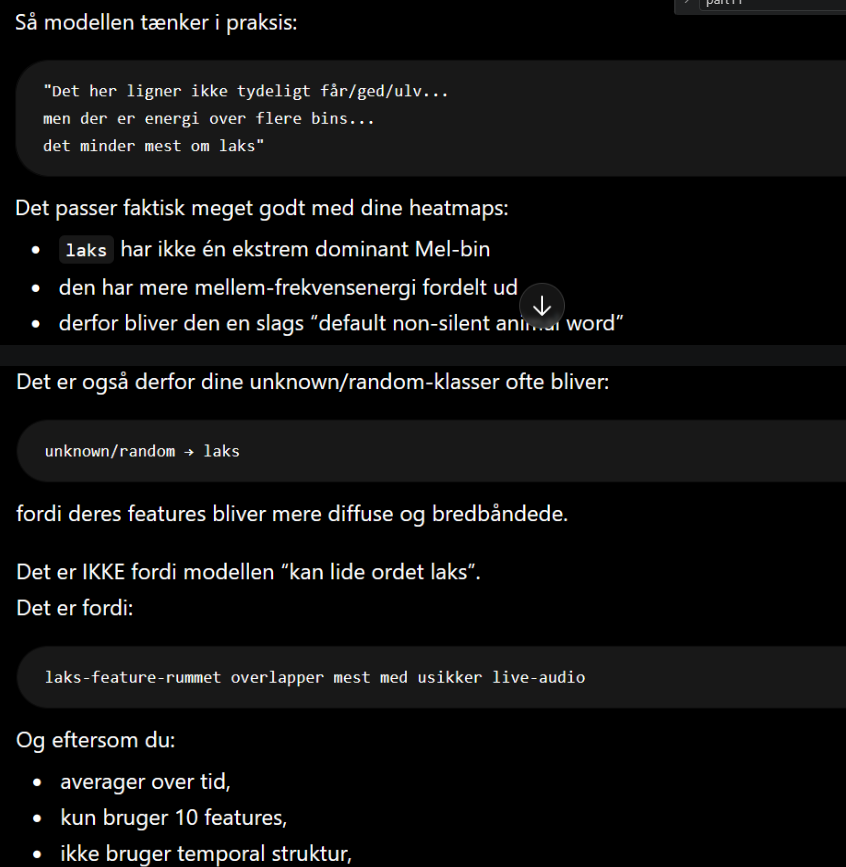

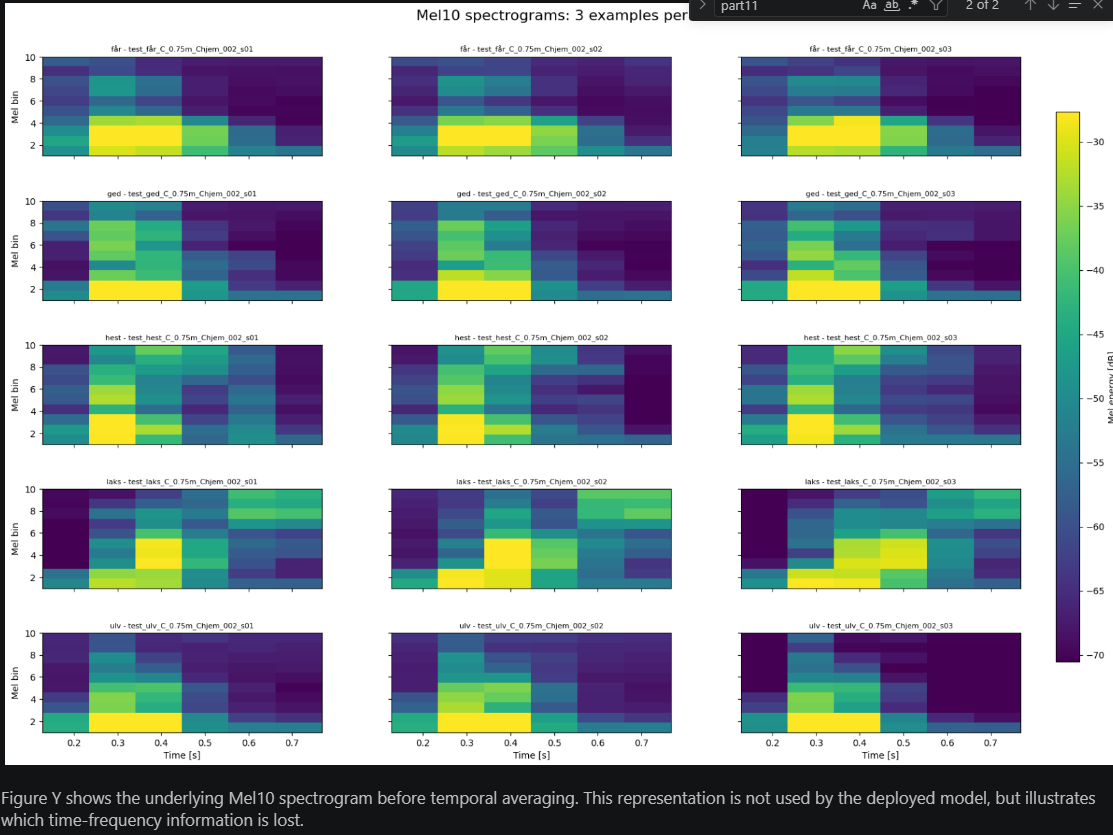

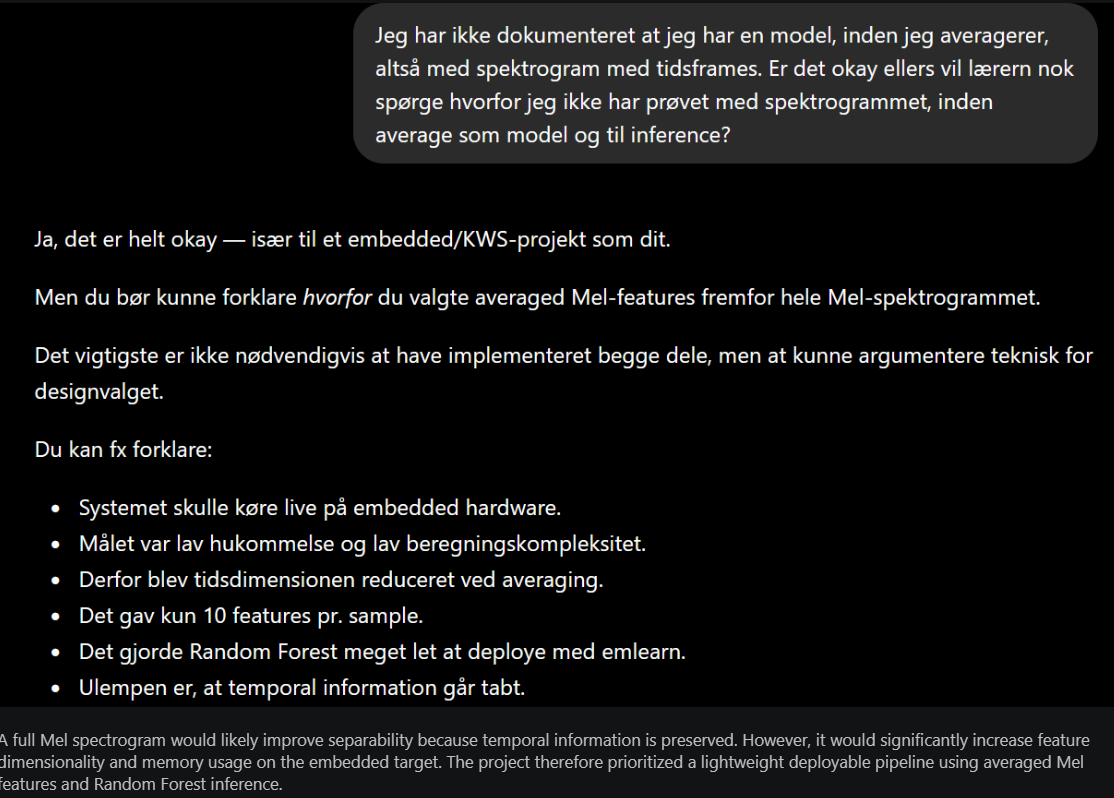

MEN, I VIRKELIGHEDEN ER DET IKKE NØDVENDIGVIS KVALITETEN AF FEATURESNE, SOM ER AFGØRENDE. DET MÅ LIGGE I ET PROBLEM I INFERENCING, FORDI AT VI HAR VERIFICERET MED PIPELINEN 1.a, 1.b og 1.c AT VI KAN FÅ SAMME TENDENS I MODELADFÆRD. SIDEN MODELLEN FAKTISK HAR EN BIAS MOD LAKS, OG FAKTISK GODT KAN KENDE FORSKEL PÅ NOGLE AF ORDENE, SÅ KUNNE DET LIGGE I NOGET JITTERSTØJ. 

DERFOR TILFØJEDE VI KODE TIL AT OBSERVERE OM LYDEN KLIPPER --> DET SKABER MERE SPREDTE KOEFFICIENTER --> MINDER OM LAKS --> LAKS BIAS

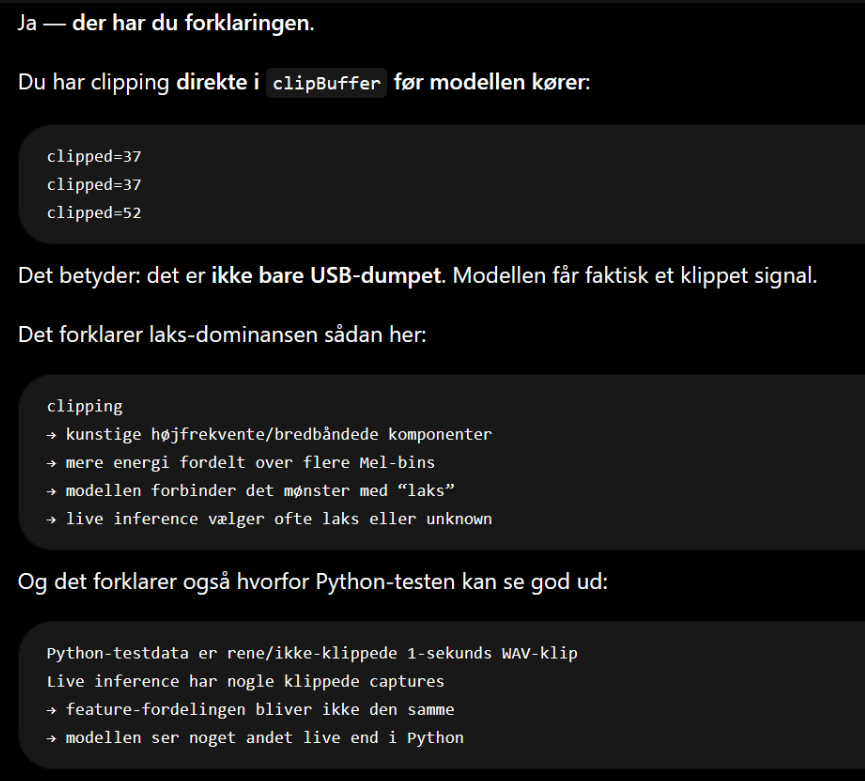

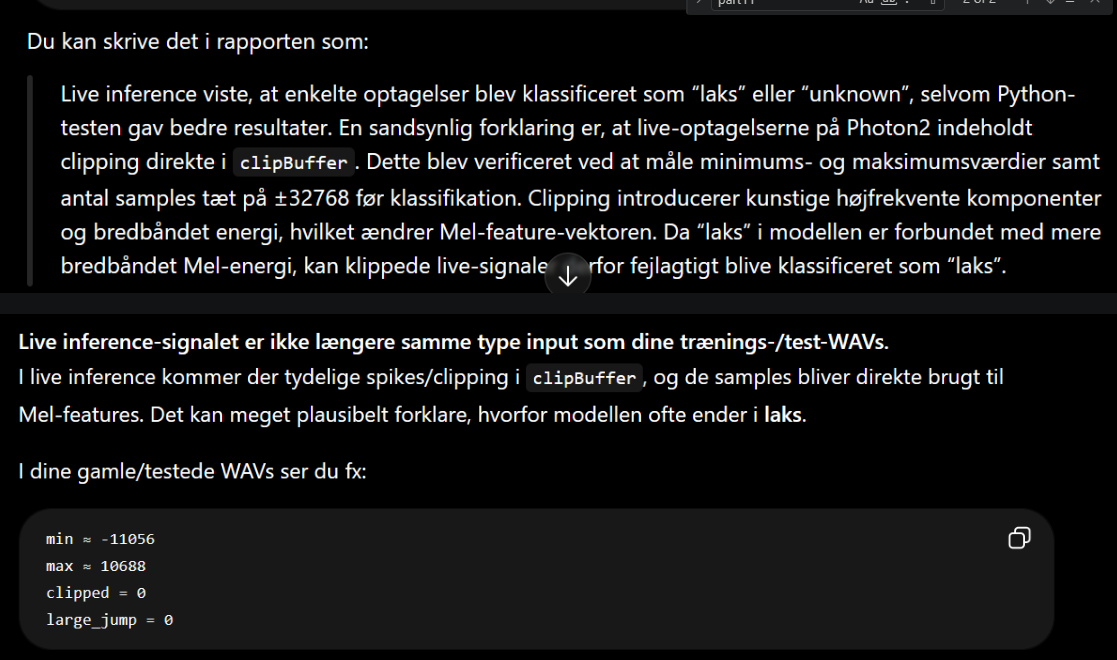

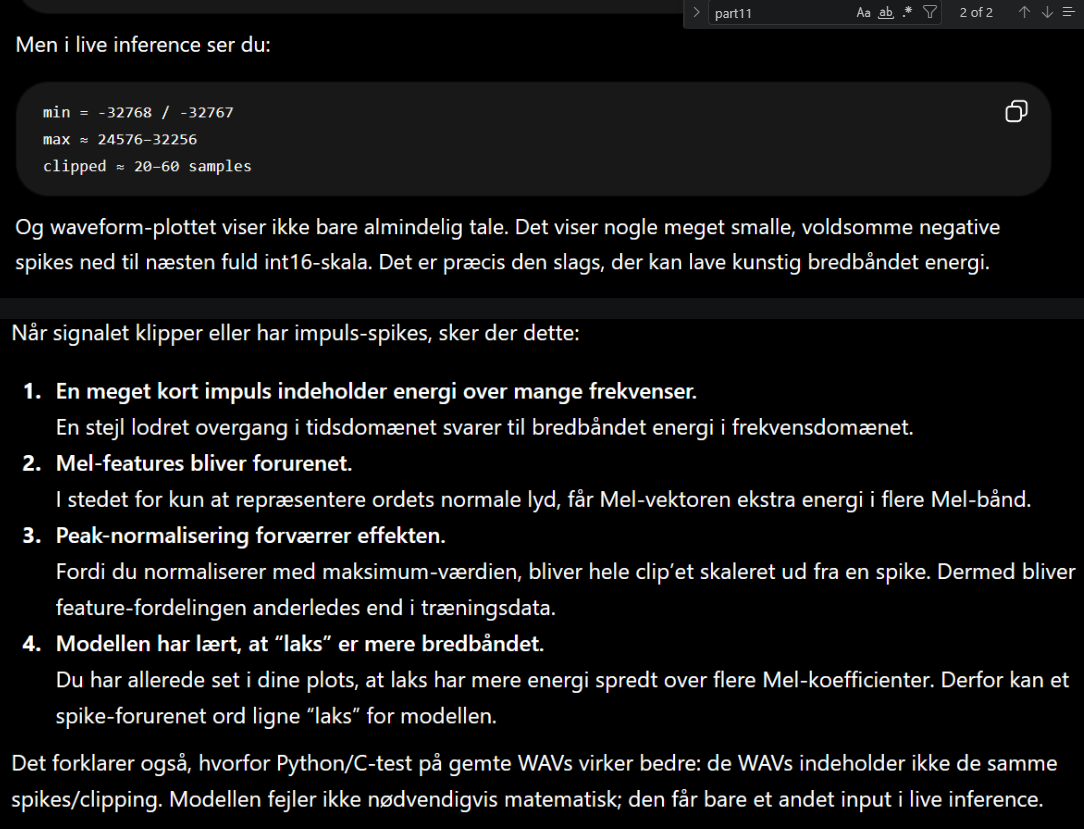

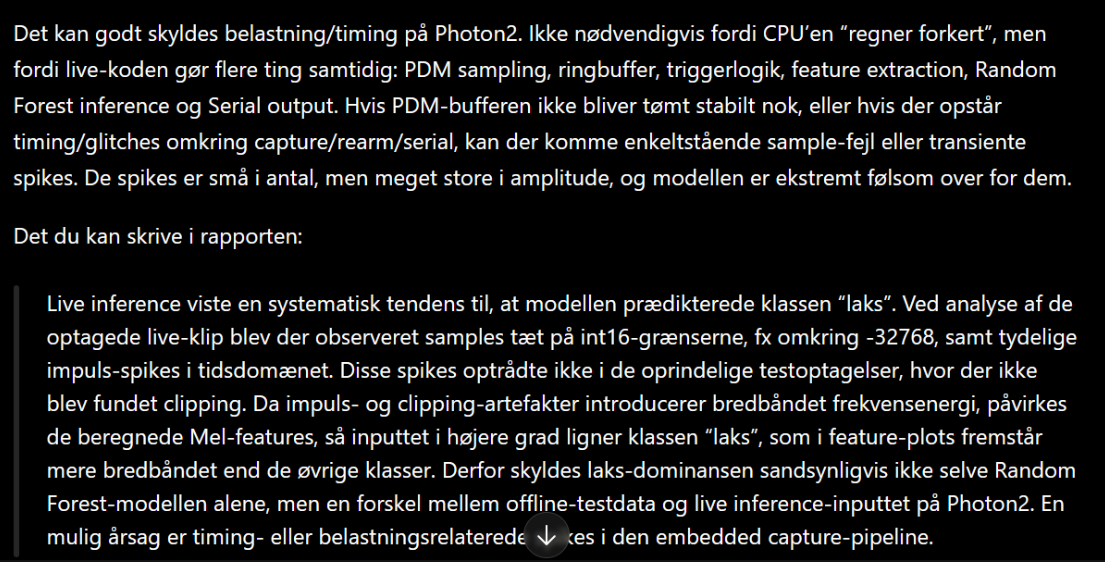

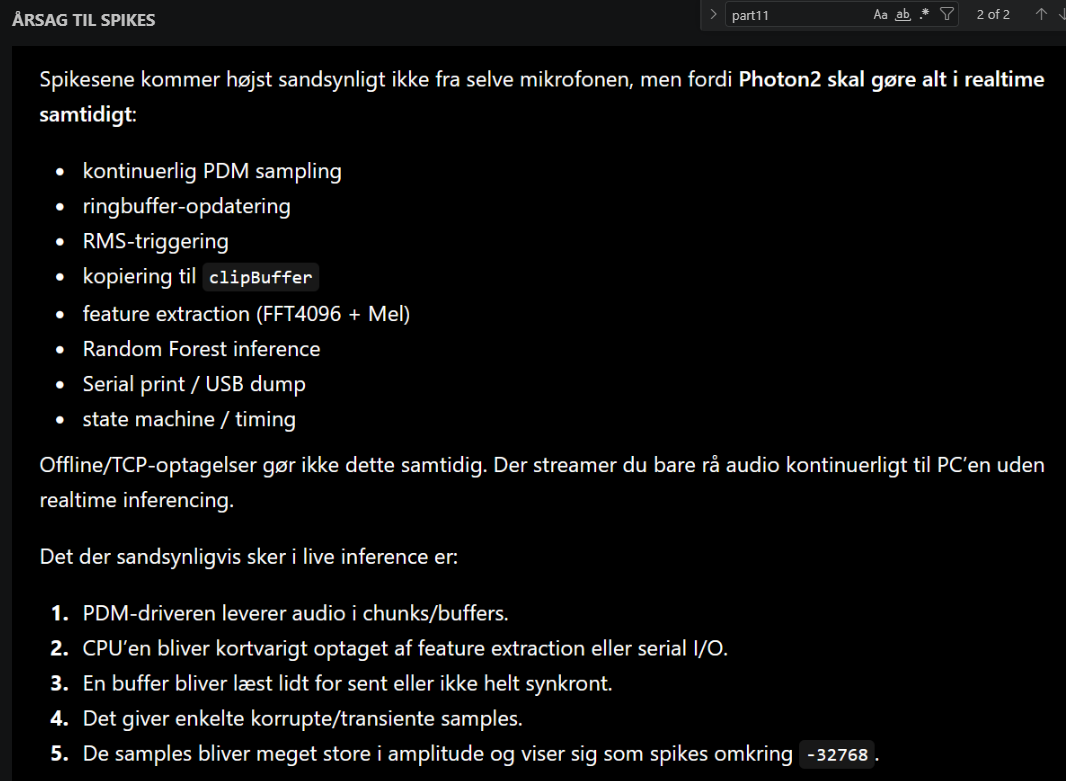

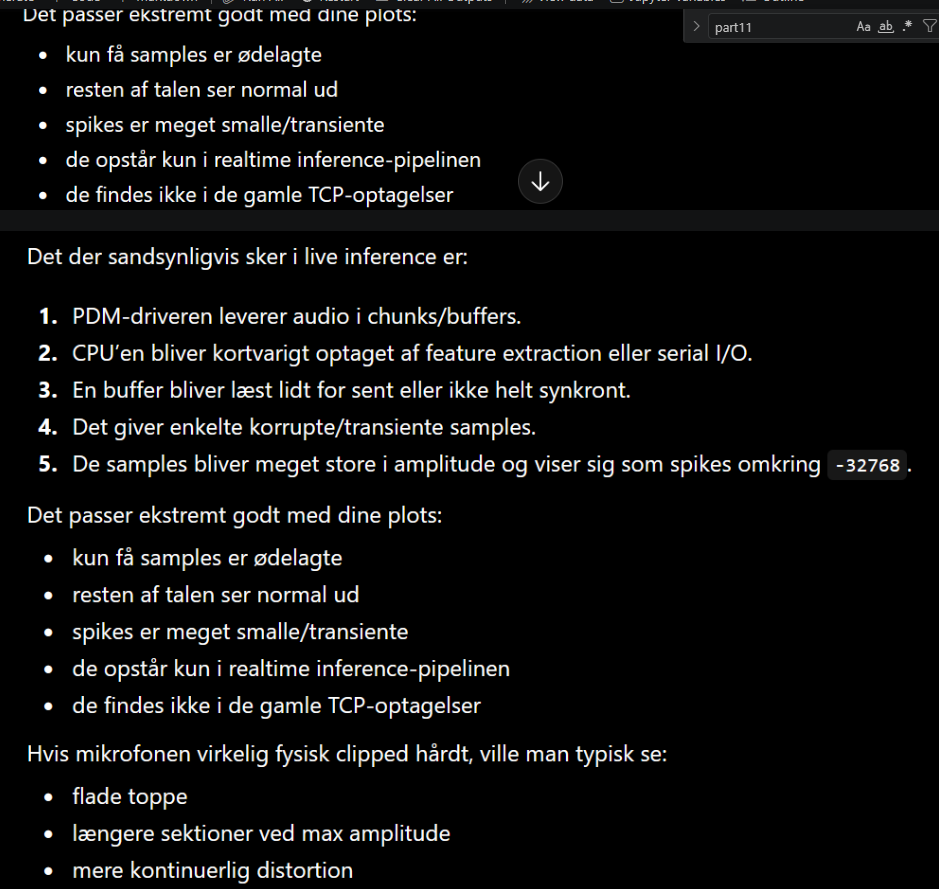

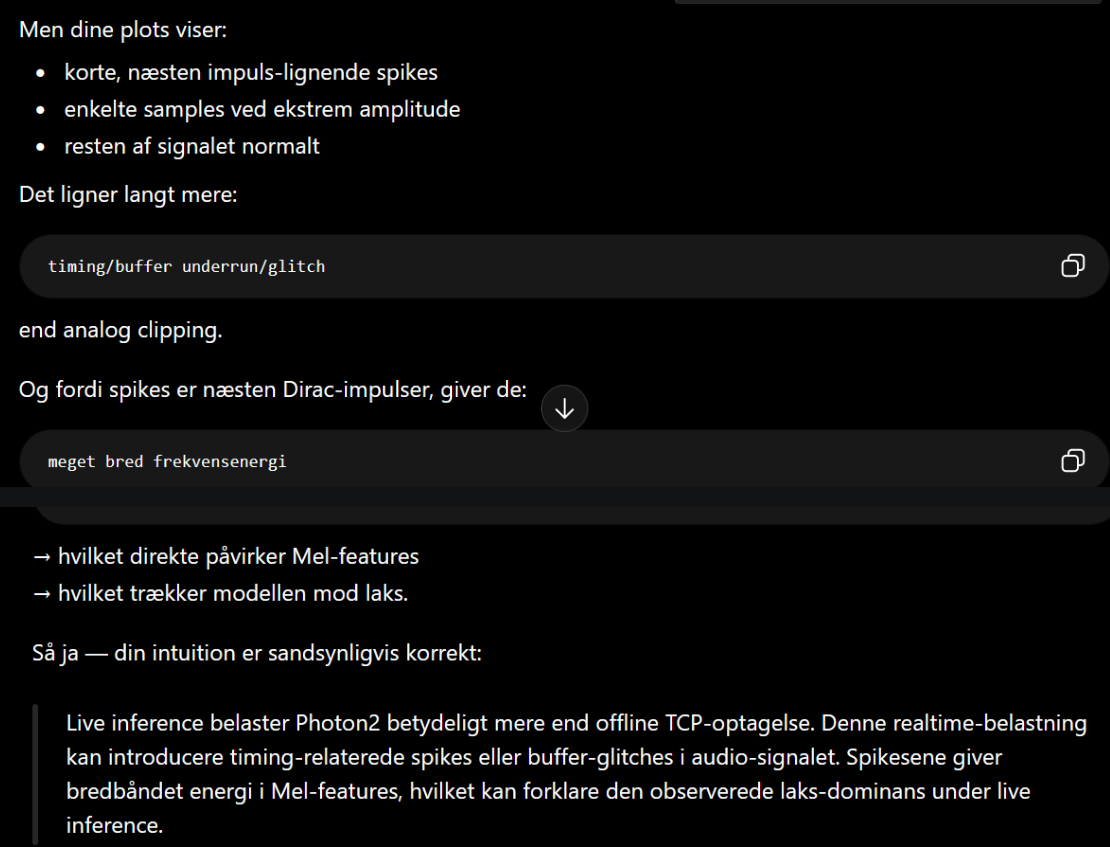